fetching 20 OSM tiles at zoom 12 ...
querying Overpass (https://maps.mail.ru/osm/tools/overpass/api/interpreter) ...
OSM features:  highway=408  railway=26  landuse=1268  leisure=345  building=9434  amenity=404


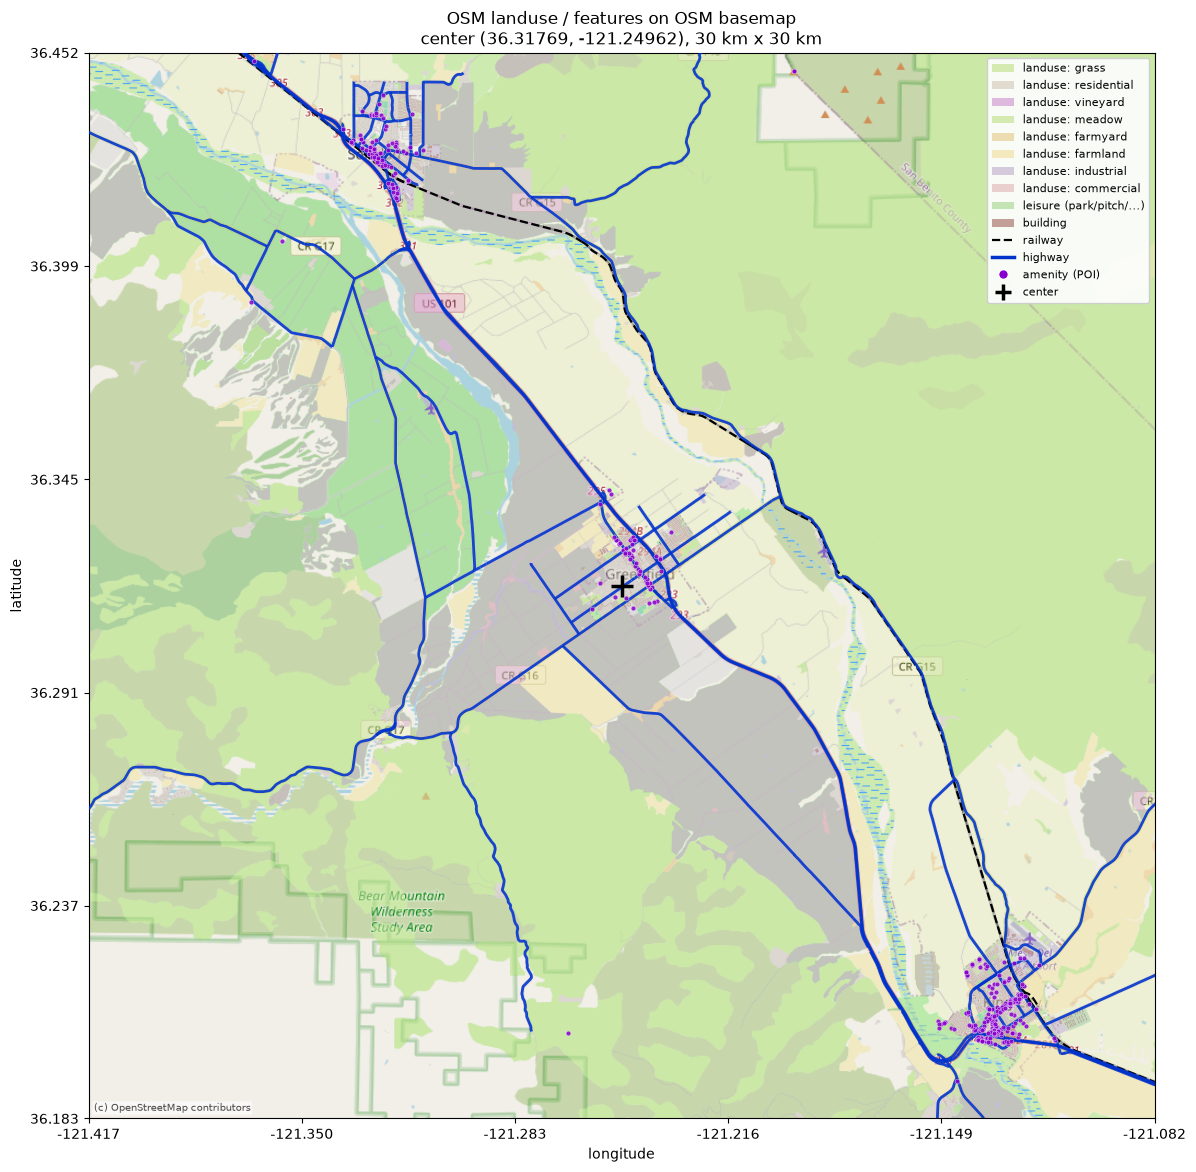

In [5]:
%matplotlib inline

import io
import json
import math
import sys
import urllib.parse
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

# ----------------------------------------------------------------------------
# Hardcoded configuration
# ----------------------------------------------------------------------------
CENTER_LAT = 36.31769
CENTER_LON = -121.24962
BOX_KM = 30.0    # full width/height of the (square) window in km
ZOOM = 12        # OSM tile zoom level

# which OSM feature layers to draw (no clustering/settlement boxes here)
OSM_LAYERS = {
    "landuse": True,
    "leisure": True,
    "building": True,
    "amenity": True,
    "railway": True,
    "highway": True,
}

_KM_PER_DEG_LAT = 111.32
_R = 6378137.0   # Web Mercator sphere radius (m)
USER_AGENT = "countryside_map/1.0 (OSM landuse map demo)"
_HEADERS = {"User-Agent": USER_AGENT}  # OSM tile server / Overpass reject requests without one


def http_get(url, timeout=30):
    """GET a URL with urllib and return the raw response bytes."""
    req = urllib.request.Request(url, headers=_HEADERS, method="GET")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


def http_post_form(url, form, timeout=60):
    """POST a form-encoded body with urllib and return the raw response bytes."""
    body = urllib.parse.urlencode(form).encode("utf-8")
    req = urllib.request.Request(url, data=body, headers=_HEADERS, method="POST")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


LANDUSE_COLORS = {
    "farmland": "#f3e4b0", "farmyard": "#e8d5a0", "vineyard": "#d7a8d7",
    "orchard": "#c6df9a", "residential": "#dcd2c6", "commercial": "#e6c6c6",
    "retail": "#e6afaf", "industrial": "#cdbdd6", "forest": "#a6cf96",
    "meadow": "#cbe69f", "grass": "#cbe69f", "cemetery": "#b3c49f",
    "recreation_ground": "#c2df9f", "quarry": "#c6bfb0",
}
LANDUSE_DEFAULT = "#d9d9d9"
LEISURE_COLORS = {
    "park": "#b3e096", "garden": "#b3e096", "nature_reserve": "#a0d488",
    "pitch": "#9bd6ab", "playground": "#e0d3ad", "golf_course": "#aede96",
}
LEISURE_DEFAULT = "#b9dea6"
BUILDING_COLOR = "#b98f86"
AMENITY_COLOR = "#8800cc"


# ----------------------------------------------------------------------------
# Web Mercator helpers
# ----------------------------------------------------------------------------
def merc(lon, lat):
    x = _R * math.radians(lon)
    y = _R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y


def merc_arr(lons, lats):
    lons = np.asarray(lons, dtype="float64")
    lats = np.asarray(lats, dtype="float64")
    x = _R * np.radians(lons)
    y = _R * np.log(np.tan(np.pi / 4 + np.radians(lats) / 2))
    return x, y


def ring_to_merc(geometry):
    lons = [p["lon"] for p in geometry]
    lats = [p["lat"] for p in geometry]
    x, y = merc_arr(lons, lats)
    return np.column_stack([x, y])


def bbox_from_center(lat, lon, box_km):
    half = box_km / 2.0
    d_lat = half / _KM_PER_DEG_LAT
    d_lon = half / (_KM_PER_DEG_LAT * max(math.cos(math.radians(lat)), 1e-6))
    return lon - d_lon, lat - d_lat, lon + d_lon, lat + d_lat  # west, south, east, north


# ----------------------------------------------------------------------------
# OSM tile basemap
# ----------------------------------------------------------------------------
def _deg2num(lat, lon, n):
    x = (lon + 180.0) / 360.0 * n
    lat_r = math.radians(lat)
    y = (1.0 - math.asinh(math.tan(lat_r)) / math.pi) / 2.0 * n
    return x, y


def _num2lat(y, n):
    return math.degrees(math.atan(math.sinh(math.pi * (1.0 - 2.0 * y / n))))


def fetch_osm_basemap(west, south, east, north, zoom):
    """Download & stitch OSM tiles. Returns (image_array, mercator_extent)."""
    n = 2 ** zoom
    x_tl, y_tl = _deg2num(north, west, n)
    x_br, y_br = _deg2num(south, east, n)
    tx0, tx1 = int(math.floor(x_tl)), int(math.floor(x_br))
    ty0, ty1 = int(math.floor(y_tl)), int(math.floor(y_br))

    n_tiles = (tx1 - tx0 + 1) * (ty1 - ty0 + 1)
    print(f"fetching {n_tiles} OSM tiles at zoom {zoom} ...")

    canvas = Image.new("RGB", ((tx1 - tx0 + 1) * 256, (ty1 - ty0 + 1) * 256), (221, 221, 221))
    subdomains = ["a", "b", "c"]
    for tx in range(tx0, tx1 + 1):
        for ty in range(ty0, ty1 + 1):
            sub = subdomains[(tx + ty) % 3]
            url = f"https://{sub}.tile.openstreetmap.org/{zoom}/{tx}/{ty}.png"
            try:
                content = http_get(url, timeout=30)
                tile = Image.open(io.BytesIO(content)).convert("RGB")
                canvas.paste(tile, ((tx - tx0) * 256, (ty - ty0) * 256))
            except Exception as exc:  # noqa: BLE001 - leave gray tile on failure
                print(f"  tile {zoom}/{tx}/{ty} failed: {exc}", file=sys.stderr)

    lon_left = tx0 / n * 360.0 - 180.0
    lon_right = (tx1 + 1) / n * 360.0 - 180.0
    lat_top = _num2lat(ty0, n)
    lat_bot = _num2lat(ty1 + 1, n)
    x_left, y_top = merc(lon_left, lat_top)
    x_right, y_bot = merc(lon_right, lat_bot)
    return np.asarray(canvas), (x_left, x_right, y_bot, y_top)


# ----------------------------------------------------------------------------
# OSM vector features (Overpass) — no clustering, just the raw geometries
# ----------------------------------------------------------------------------
def fetch_osm_features(west, south, east, north, want, timeout=120):
    feats = {k: [] for k in ("highway", "railway", "landuse", "leisure",
                             "building", "amenity")}
    bbox = f"{south},{west},{north},{east}"
    parts = []
    if want.get("highway"):
        parts.append(f'way["highway"~"^(motorway|trunk|primary|secondary|tertiary)$"]({bbox});')
    if want.get("railway"):
        parts.append(f'way["railway"~"^(rail|light_rail|tram|subway|narrow_gauge)$"]({bbox});')
    if want.get("landuse"):
        parts.append(f'way["landuse"]({bbox});')
    if want.get("leisure"):
        parts.append(f'way["leisure"]({bbox});')
    if want.get("building"):
        parts.append(f'way["building"]({bbox});')
    if want.get("amenity"):
        parts.append(f'node["amenity"]({bbox});')
        parts.append(f'way["amenity"]({bbox});')
    if not parts:
        return feats

    query = f"[out:json][timeout:{timeout}];\n(\n  " + "\n  ".join(parts) + "\n);\nout geom;"
    endpoints = [
        "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
    ]
    data = None
    for url in endpoints:
        try:
            print(f"querying Overpass ({url}) ...")
            payload = http_post_form(url, {"data": query}, timeout=timeout + 30)
            data = json.loads(payload)
            break
        except Exception as exc:  # noqa: BLE001
            print(f"overpass {url} failed: {exc}", file=sys.stderr)
    if data is None:
        print("no OSM feature data retrieved", file=sys.stderr)
        return feats

    for el in data.get("elements", []):
        tags = el.get("tags", {})
        etype = el.get("type")
        if etype == "node" and "amenity" in tags:
            feats["amenity"].append((el["lon"], el["lat"], tags["amenity"]))
            continue
        if etype != "way" or "geometry" not in el:
            continue
        geom = el["geometry"]
        if "highway" in tags:
            feats["highway"].append((geom, tags.get("ref") or tags.get("name", "")))
        elif "railway" in tags:
            feats["railway"].append(geom)
        elif "building" in tags:
            feats["building"].append(geom)
        elif "landuse" in tags:
            feats["landuse"].append((geom, tags["landuse"]))
        elif "leisure" in tags:
            feats["leisure"].append((geom, tags["leisure"]))
        elif "amenity" in tags:
            lons = [p["lon"] for p in geom]
            lats = [p["lat"] for p in geom]
            feats["amenity"].append((sum(lons) / len(lons), sum(lats) / len(lats),
                                     tags["amenity"]))
    return feats


# ----------------------------------------------------------------------------
# Rendering helpers
# ----------------------------------------------------------------------------
def add_polygons(ax, items, color_of, zorder, alpha, edgecolor="none", lw=0.0):
    patches, facecolors = [], []
    for it in items:
        geom, value = it if isinstance(it, tuple) else (it, None)
        if len(geom) < 3:
            continue
        patches.append(MplPolygon(ring_to_merc(geom), closed=True))
        facecolors.append(color_of(value))
    if not patches:
        return
    ax.add_collection(PatchCollection(patches, facecolors=facecolors,
                                      edgecolors=edgecolor, linewidths=lw,
                                      alpha=alpha, zorder=zorder))


def setup_axes(ax, base_img, base_extent, west, south, east, north, title):
    ax.imshow(base_img, extent=base_extent, origin="upper", interpolation="bilinear",
              zorder=0)
    xw, yb = merc(west, south)
    xe, yt = merc(east, north)
    ax.set_xlim(xw, xe)
    ax.set_ylim(yb, yt)
    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)
    ax.set_xticks([merc(v, CENTER_LAT)[0] for v in lon_ticks])
    ax.set_xticklabels([f"{v:.3f}" for v in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, v)[1] for v in lat_ticks])
    ax.set_yticklabels([f"{v:.3f}" for v in lat_ticks])
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)
    return (xw, yb, xe, yt)


def add_attribution(ax):
    ax.text(0.005, 0.005, "(c) OpenStreetMap contributors", transform=ax.transAxes,
            fontsize=7, color="black", alpha=0.7, ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))


# ----------------------------------------------------------------------------
# Fetch inputs and draw the landuse / feature map (no clustering)
# ----------------------------------------------------------------------------
west, south, east, north = bbox_from_center(CENTER_LAT, CENTER_LON, BOX_KM)
base_img, base_extent = fetch_osm_basemap(west, south, east, north, ZOOM)
feats = fetch_osm_features(west, south, east, north, OSM_LAYERS)
print("OSM features:  " + "  ".join(f"{k}={len(v)}" for k, v in feats.items()))

fig, ax = plt.subplots(figsize=(12, 12))
setup_axes(ax, base_img, base_extent, west, south, east, north,
           f"OSM landuse / features on OSM basemap\n"
           f"center ({CENTER_LAT}, {CENTER_LON}), {BOX_KM:.0f} km x {BOX_KM:.0f} km")
handles = []

if OSM_LAYERS["landuse"] and feats["landuse"]:
    add_polygons(ax, feats["landuse"],
                 lambda v: LANDUSE_COLORS.get(v, LANDUSE_DEFAULT),
                 zorder=1, alpha=0.5)
    counts = {}
    for _, v in feats["landuse"]:
        counts[v] = counts.get(v, 0) + 1
    for v, _ in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:8]:
        handles.append(Patch(facecolor=LANDUSE_COLORS.get(v, LANDUSE_DEFAULT),
                             edgecolor="none", alpha=0.8, label=f"landuse: {v}"))

if OSM_LAYERS["leisure"] and feats["leisure"]:
    add_polygons(ax, feats["leisure"],
                 lambda v: LEISURE_COLORS.get(v, LEISURE_DEFAULT),
                 zorder=1.3, alpha=0.6)
    handles.append(Patch(facecolor=LEISURE_DEFAULT, edgecolor="none",
                         alpha=0.8, label="leisure (park/pitch/...)"))

if OSM_LAYERS["building"] and feats["building"]:
    add_polygons(ax, feats["building"], lambda v: BUILDING_COLOR,
                 zorder=2, alpha=0.8)
    handles.append(Patch(facecolor=BUILDING_COLOR, edgecolor="none",
                         alpha=0.85, label="building"))

if OSM_LAYERS["railway"] and feats["railway"]:
    segs = [ring_to_merc(g) for g in feats["railway"] if len(g) >= 2]
    ax.add_collection(LineCollection(segs, colors="black", linewidths=1.6,
                                     linestyles="dashed", zorder=3))
    handles.append(plt.Line2D([], [], color="black", lw=1.6, ls="dashed",
                              label="railway"))

if OSM_LAYERS["highway"] and feats["highway"]:
    segs = [ring_to_merc(g) for g, _ in feats["highway"] if len(g) >= 2]
    ax.add_collection(LineCollection(segs, colors="#0033cc", linewidths=2.0,
                                     alpha=0.9, zorder=3.5))
    handles.append(plt.Line2D([], [], color="#0033cc", lw=2.5, label="highway"))

if OSM_LAYERS["amenity"] and feats["amenity"]:
    alon = np.array([a[0] for a in feats["amenity"]])
    alat = np.array([a[1] for a in feats["amenity"]])
    axm, aym = merc_arr(alon, alat)
    ax.scatter(axm, aym, s=12, c=AMENITY_COLOR, marker="o", alpha=0.85,
               edgecolors="white", linewidths=0.3, zorder=4)
    handles.append(plt.Line2D([], [], color=AMENITY_COLOR, marker="o", ls="none",
                              ms=7, mec="white", label="amenity (POI)"))

ccx, ccy = merc(CENTER_LON, CENTER_LAT)
ax.plot([ccx], [ccy], marker="+", ms=16, mew=2.5, color="black", zorder=6)
handles.append(plt.Line2D([], [], marker="+", color="black", ls="none",
                          ms=12, mew=2.5, label="center"))
ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
add_attribution(ax)
fig.tight_layout()
plt.show()


dense threshold = 50.0 persons/km^2, 5 cluster(s):
  cluster #1: 15 cells, peak 5196 persons/km^2, lat [36.31494, 36.33994]  lon [-121.27102, -121.22935]
  cluster #2: 14 cells, peak 3753 persons/km^2, lat [36.42327, 36.44827]  lon [-121.33769, -121.30435]
  cluster #3: 13 cells, peak 4478 persons/km^2, lat [36.19827, 36.22327]  lon [-121.14602, -121.11269]
  cluster #4: 2 cells, peak 89 persons/km^2, lat [36.26494, 36.27327]  lon [-121.17935, -121.17935]
  cluster #5: 2 cells, peak 825 persons/km^2, lat [36.18994, 36.18994]  lon [-121.15435, -121.14602]


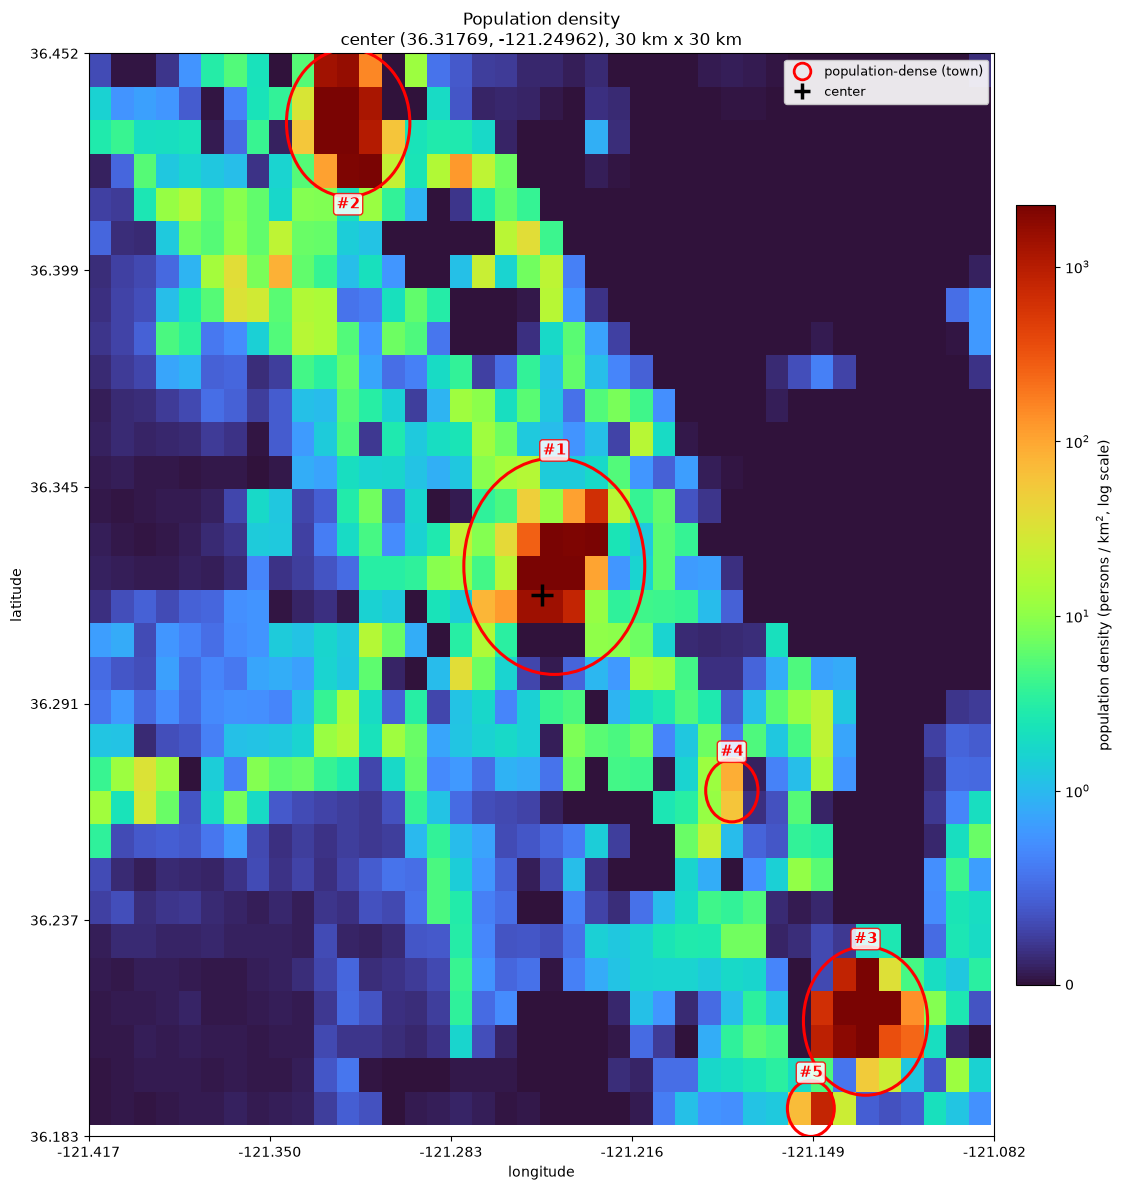

In [6]:
%matplotlib inline

import math
from collections import deque

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.patches import Circle
from rasterio.windows import from_bounds

# ----------------------------------------------------------------------------
# Inputs
# ----------------------------------------------------------------------------
CENTER_LAT = 36.31769
CENTER_LON = -121.24962
BOX_KM = 30.0                     # full width/height of the (square) window in km
TIF_PATH = "usa_pd_2018_1km.tif"  # population-density raster (persons / km^2)

DENSE_FLOOR = 50.0      # a cell counts as "populated" at >= this many persons/km^2
MIN_CLUSTER_CELLS = 2   # ignore population blobs smaller than this many cells

_KM_PER_DEG_LAT = 111.32
_R = 6378137.0   # Web Mercator sphere radius (m)


# ----------------------------------------------------------------------------
# Web Mercator helpers
# ----------------------------------------------------------------------------
def merc(lon, lat):
    x = _R * math.radians(lon)
    y = _R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y


def merc_arr(lons, lats):
    lons = np.asarray(lons, dtype="float64")
    lats = np.asarray(lats, dtype="float64")
    x = _R * np.radians(lons)
    y = _R * np.log(np.tan(np.pi / 4 + np.radians(lats) / 2))
    return x, y


def bbox_from_center(lat, lon, box_km):
    half = box_km / 2.0
    d_lat = half / _KM_PER_DEG_LAT
    d_lon = half / (_KM_PER_DEG_LAT * max(math.cos(math.radians(lat)), 1e-6))
    return lon - d_lon, lat - d_lat, lon + d_lon, lat + d_lat  # west, south, east, north


# ----------------------------------------------------------------------------
# Population density raster
# ----------------------------------------------------------------------------
def read_pop_window(tif_path, west, south, east, north):
    with rasterio.open(tif_path) as ds:
        b = ds.bounds
        window = from_bounds(max(west, b.left), max(south, b.bottom),
                             min(east, b.right), min(north, b.top),
                             transform=ds.transform)
        data = ds.read(1, window=window).astype("float32")
        tr = ds.window_transform(window)
        nodata = ds.nodata
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data < 0, np.nan, data)
    return data, tr


def cell_centers(data, transform):
    ny, nx = data.shape
    cols, rows = np.meshgrid(np.arange(nx), np.arange(ny))
    lon = transform.c + transform.a * (cols + 0.5) + transform.b * (rows + 0.5)
    lat = transform.f + transform.d * (cols + 0.5) + transform.e * (rows + 0.5)
    return lon, lat


def cell_edges_merc(data, transform):
    ny, nx = data.shape
    cols, rows = np.meshgrid(np.arange(nx + 1), np.arange(ny + 1))
    lon = transform.c + transform.a * cols + transform.b * rows
    lat = transform.f + transform.d * cols + transform.e * rows
    return merc_arr(lon, lat)


def connected_components(mask):
    """4-connected labeling of a boolean mask. Returns list of [(r,c), ...] blobs."""
    ny, nx = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    blobs = []
    for r in range(ny):
        for c in range(nx):
            if mask[r, c] and not seen[r, c]:
                q = deque([(r, c)])
                seen[r, c] = True
                cells = []
                while q:
                    cr, cc = q.popleft()
                    cells.append((cr, cc))
                    for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                        nr, nc = cr + dr, cc + dc
                        if 0 <= nr < ny and 0 <= nc < nx and mask[nr, nc] and not seen[nr, nc]:
                            seen[nr, nc] = True
                            q.append((nr, nc))
                blobs.append(cells)
    return blobs


# ----------------------------------------------------------------------------
# Rendering helpers
# ----------------------------------------------------------------------------
def setup_axes(ax, west, south, east, north, title):
    # No tile basemap: the heatmap is drawn on a plain white background.
    ax.set_facecolor("white")
    xw, yb = merc(west, south)
    xe, yt = merc(east, north)
    ax.set_xlim(xw, xe)
    ax.set_ylim(yb, yt)
    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)
    ax.set_xticks([merc(v, CENTER_LAT)[0] for v in lon_ticks])
    ax.set_xticklabels([f"{v:.3f}" for v in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, v)[1] for v in lat_ticks])
    ax.set_yticklabels([f"{v:.3f}" for v in lat_ticks])
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)
    return (xw, yb, xe, yt)


# ----------------------------------------------------------------------------
# Read inputs and draw the population-density map
# ----------------------------------------------------------------------------
west, south, east, north = bbox_from_center(CENTER_LAT, CENTER_LON, BOX_KM)
data, transform = read_pop_window(TIF_PATH, west, south, east, north)

lon2d, lat2d = cell_centers(data, transform)
valid = data[np.isfinite(data)]
thresh = max(np.nanpercentile(valid, 90), DENSE_FLOOR)
dense_mask = np.isfinite(data) & (data >= thresh)
blobs = [b for b in connected_components(dense_mask) if len(b) >= MIN_CLUSTER_CELLS]
print(f"dense threshold = {thresh:.1f} persons/km^2, {len(blobs)} cluster(s):")

fig, ax = plt.subplots(figsize=(12, 12))
_, yb, _, yt = setup_axes(ax, west, south, east, north,
                          f"Population density\n"
                          f"center ({CENTER_LAT}, {CENTER_LON}), "
                          f"{BOX_KM:.0f} km x {BOX_KM:.0f} km")

Xe, Ye = cell_edges_merc(data, transform)
masked = np.ma.masked_invalid(data)
vmax = max(float(np.nanpercentile(valid, 99)), 1.0)
norm = matplotlib.colors.SymLogNorm(linthresh=1.0, vmin=0.0, vmax=vmax)
cmap = plt.get_cmap("turbo").copy()
cmap.set_bad(alpha=0.0)
mesh = ax.pcolormesh(Xe, Ye, masked, cmap=cmap, norm=norm,
                     shading="flat", zorder=2)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("population density (persons / km$^2$, log scale)")

for i, cells in enumerate(sorted(blobs, key=len, reverse=True), 1):
    rows = [c[0] for c in cells]
    cols = [c[1] for c in cells]
    clons = lon2d[rows, cols]
    clats = lat2d[rows, cols]
    vals = data[rows, cols]
    cx, cy = merc(clons.mean(), clats.mean())
    mx, my = merc_arr(clons, clats)
    radius = max(np.hypot(mx - cx, my - cy).max(), 400.0) + 500.0
    ax.add_patch(Circle((cx, cy), radius, fill=False, edgecolor="red",
                        linewidth=2.2, zorder=5))
    if cy + radius > yt - (yt - yb) * 0.06:
        ly, va = cy - radius, "top"
    else:
        ly, va = cy + radius, "bottom"
    ax.text(cx, ly, f"#{i}", color="red", fontsize=11, fontweight="bold",
            ha="center", va=va, zorder=6,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.85))
    print(f"  cluster #{i}: {len(cells)} cells, peak {vals.max():.0f} persons/km^2, "
          f"lat [{clats.min():.5f}, {clats.max():.5f}]  "
          f"lon [{clons.min():.5f}, {clons.max():.5f}]")

ccx, ccy = merc(CENTER_LON, CENTER_LAT)
ax.plot([ccx], [ccy], marker="+", ms=16, mew=2.5, color="black", zorder=6)
handles = [
    plt.Line2D([], [], marker="o", mfc="none", mec="red", mew=2, ls="none",
               ms=12, label="population-dense (town)"),
    plt.Line2D([], [], marker="+", color="black", ls="none", ms=12, mew=2.5,
               label="center"),
]
ax.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
fig.tight_layout()
plt.show()


clustering done; cluster_result is ready for the sampling cell


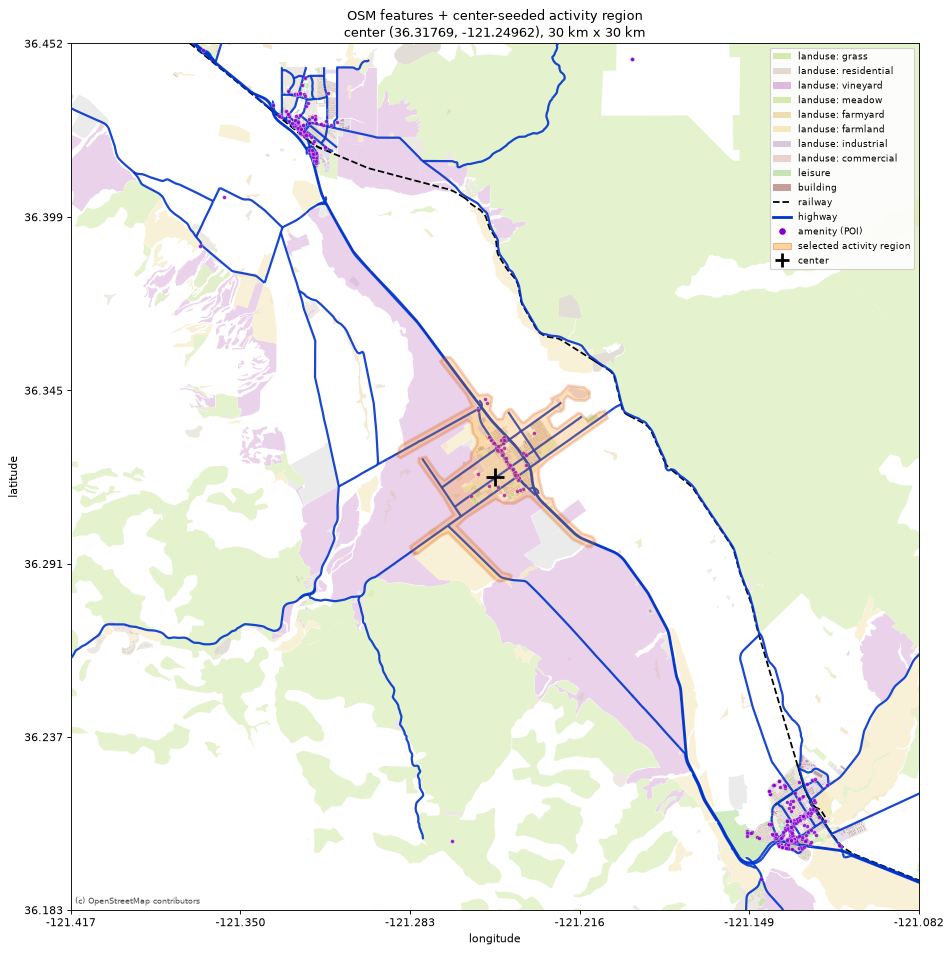

In [19]:
"""
Center-seeded OSM activity-region clustering (step 1 of 2).

Reuses the Overpass features fetched by the first notebook cell (feats,
CENTER_LAT/CENTER_LON) — no network requests, no plotting here. The
cluster is computed from OSM tags and geometries, not from plot colors:

- residential / amenity / building evidence forms the activity core;
- locally connected highway branches may extend from that core.

Draws the first cell's OSM feature layers with the selected activity
region on top (via plot_region_map, which the sampling cell reuses), and
leaves `shapely_layers` and `cluster_result` in the kernel.
"""

from __future__ import annotations

import math
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from pyproj import CRS, Transformer
from rasterio.features import rasterize, shapes
from rasterio.transform import from_origin
from scipy import ndimage as ndi
from shapely.geometry import (
    GeometryCollection,
    LineString,
    MultiLineString,
    MultiPolygon,
    Point,
    Polygon,
    shape,
)
from shapely.ops import transform as shapely_transform

try:
    from shapely import make_valid
except ImportError:
    def make_valid(geometry):
        return geometry.buffer(0)


# ============================================================================
# Clustering configuration
# ============================================================================

# ------------------------- clustering parameters -----------------------------

# The selected cluster is not allowed to expand farther than this from center.
MAX_REGION_RADIUS_M = 4500.0

# Raster cell size used internally by the clustering algorithm.
# 40-75 m is usually a sensible range.
GRID_SIZE_M = 50.0

# Activity-score thresholds.
# HIGH_THRESHOLD creates the reliable activity core.
# LOW_THRESHOLD allows weaker evidence to connect to the core.
HIGH_THRESHOLD = 1.65
LOW_THRESHOLD = 0.30

# Highway corridor settings.
# Increasing these includes more highway corners/branches.
HIGHWAY_BUFFER_M = 120.0
HIGHWAY_MAX_EXTENSION_FROM_CORE_M = 2800.0
CORE_TO_HIGHWAY_BRIDGE_M = 200.0

# Boundary cleanup.
MORPHOLOGY_CLOSE_M = 100.0
POLYGON_SMOOTH_M = 50.0

# Land-use categories used as evidence.
POSITIVE_LANDUSE = {
    "residential",
    "commercial",
    "retail",
    "industrial",
    "education",
    "institutional",
}

LOW_ACTIVITY_LANDUSE = {
    "farmland",
    "farmyard",
    "vineyard",
    "orchard",
    "forest",
    "meadow",
    "grass",
    "quarry",
}

POSITIVE_LEISURE = {
    "park",
    "garden",
    "pitch",
    "playground",
    "sports_centre",
    "recreation_ground",
}

# Colors for the layers this cell adds on top of the first cell's palette.
HIGHWAY_COLOR = "#0033cc"
REGION_FACE_COLOR = "#ff8c00"
REGION_EDGE_COLOR = "#d94801"

# Activity-score weights. These are independent of plot colors.
WEIGHT_RESIDENTIAL = 3.0
WEIGHT_AMENITY = 4.0
WEIGHT_BUILDING = 1.2
WEIGHT_LEISURE = 0.6
WEIGHT_LOW_ACTIVITY = -0.8
WEIGHT_DISTANCE = -0.7



# ============================================================================
# Coordinate helpers
# ============================================================================

def choose_local_utm(lat: float, lon: float) -> CRS:
    zone = int((lon + 180.0) // 6.0) + 1
    epsg = (32600 if lat >= 0 else 32700) + zone
    return CRS.from_epsg(epsg)



# ============================================================================
# Convert raw Overpass geometries into Shapely geometries
# ============================================================================

def raw_way_to_linestring(
    geometry: list[dict],
) -> LineString | None:
    coordinates = [
        (point["lon"], point["lat"])
        for point in geometry
    ]
    if len(coordinates) < 2:
        return None

    line = LineString(coordinates)
    return line if not line.is_empty else None


def raw_way_to_polygon(
    geometry: list[dict],
) -> Polygon | MultiPolygon | None:
    coordinates = [
        (point["lon"], point["lat"])
        for point in geometry
    ]
    if len(coordinates) < 3:
        return None

    if coordinates[0] != coordinates[-1]:
        coordinates.append(coordinates[0])

    polygon = make_valid(Polygon(coordinates))

    if polygon.is_empty:
        return None

    if isinstance(polygon, Polygon):
        return polygon

    if isinstance(polygon, MultiPolygon):
        return polygon

    polygon_parts = [
        part
        for part in getattr(polygon, "geoms", [])
        if isinstance(part, (Polygon, MultiPolygon))
    ]
    if not polygon_parts:
        return None

    return max(polygon_parts, key=lambda item: item.area)


def build_shapely_layers(feats: dict) -> dict:
    layers = {
        "highway": [],
        "railway": [],
        "landuse": [],
        "leisure": [],
        "building": [],
        "amenity": [],
    }

    for raw_geometry, name in feats["highway"]:
        line = raw_way_to_linestring(raw_geometry)
        if line is not None:
            layers["highway"].append((line, name))

    for raw_geometry in feats["railway"]:
        line = raw_way_to_linestring(raw_geometry)
        if line is not None:
            layers["railway"].append(line)

    for raw_geometry, landuse_type in feats["landuse"]:
        polygon = raw_way_to_polygon(raw_geometry)
        if polygon is not None:
            layers["landuse"].append(
                (polygon, landuse_type)
            )

    for raw_geometry, leisure_type in feats["leisure"]:
        polygon = raw_way_to_polygon(raw_geometry)
        if polygon is not None:
            layers["leisure"].append(
                (polygon, leisure_type)
            )

    for raw_geometry in feats["building"]:
        polygon = raw_way_to_polygon(raw_geometry)
        if polygon is not None:
            layers["building"].append(polygon)

    for lon, lat, amenity_type in feats["amenity"]:
        layers["amenity"].append(
            (Point(lon, lat), amenity_type)
        )

    return layers


def transform_layer_geometry(
    geometry,
    transformer: Transformer,
):
    return shapely_transform(
        transformer.transform,
        geometry,
    )


# ============================================================================
# Raster helpers
# ============================================================================

def normalize_positive(
    array: np.ndarray,
    percentile: float = 95.0,
) -> np.ndarray:
    positive = array[array > 0]
    if positive.size == 0:
        return np.zeros_like(array, dtype="float32")

    scale = float(np.percentile(positive, percentile))
    if scale <= 0:
        return np.zeros_like(array, dtype="float32")

    return np.clip(
        array / scale,
        0.0,
        1.0,
    ).astype("float32")


def rasterize_binary(
    geometries: Iterable,
    out_shape: tuple[int, int],
    transform,
) -> np.ndarray:
    usable = [
        geometry
        for geometry in geometries
        if geometry is not None
        and not geometry.is_empty
    ]

    if not usable:
        return np.zeros(out_shape, dtype="uint8")

    return rasterize(
        ((geometry, 1) for geometry in usable),
        out_shape=out_shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype="uint8",
    )


def rasterize_point_counts(
    points: Iterable[Point],
    out_shape: tuple[int, int],
    transform,
) -> np.ndarray:
    usable = [
        point
        for point in points
        if point is not None and not point.is_empty
    ]

    if not usable:
        return np.zeros(out_shape, dtype="float32")

    result = np.zeros(out_shape, dtype="float32")

    inverse = ~transform
    height, width = out_shape

    for point in usable:
        col_float, row_float = inverse * (
            point.x,
            point.y,
        )
        col = int(math.floor(col_float))
        row = int(math.floor(row_float))

        if 0 <= row < height and 0 <= col < width:
            result[row, col] += 1.0

    return result


def choose_nearest_strong_component(
    strong_mask: np.ndarray,
    score: np.ndarray,
    center_distance_m: np.ndarray,
) -> np.ndarray:
    labels, component_count = ndi.label(strong_mask)

    if component_count == 0:
        # Adaptive fallback if the fixed threshold is too strict.
        valid_scores = score[np.isfinite(score)]
        fallback_threshold = float(
            np.percentile(valid_scores, 90)
        )
        labels, component_count = ndi.label(
            score >= fallback_threshold
        )

    if component_count == 0:
        raise RuntimeError(
            "No activity core could be found. "
            "Lower HIGH_THRESHOLD."
        )

    candidates = []
    for component_id in range(1, component_count + 1):
        component = labels == component_id
        min_distance = float(
            center_distance_m[component].min()
        )
        score_sum = float(score[component].sum())
        area_cells = int(component.sum())

        # Primarily select the component nearest the center.
        # Score and area break ties.
        candidates.append(
            (
                min_distance,
                -score_sum,
                -area_cells,
                component_id,
            )
        )

    _, _, _, selected_id = min(candidates)
    return labels == selected_id


def keep_component_overlapping_core(
    mask: np.ndarray,
    core: np.ndarray,
) -> np.ndarray:
    labels, _ = ndi.label(mask)
    overlap_labels = labels[core]

    valid_labels, counts = np.unique(
        overlap_labels[overlap_labels > 0],
        return_counts=True,
    )

    if len(valid_labels) == 0:
        raise RuntimeError(
            "The cleaned region no longer overlaps the core."
        )

    selected_label = valid_labels[np.argmax(counts)]
    return labels == selected_label


def largest_polygon_from_mask(
    mask: np.ndarray,
    transform,
):
    polygons = [
        shape(geometry)
        for geometry, value in shapes(
            mask.astype("uint8"),
            mask=mask.astype(bool),
            transform=transform,
        )
        if value == 1
    ]

    if not polygons:
        raise RuntimeError(
            "The selected raster region could not be polygonized."
        )

    polygon = max(polygons, key=lambda item: item.area)
    polygon = make_valid(polygon)

    if isinstance(polygon, MultiPolygon):
        polygon = max(
            polygon.geoms,
            key=lambda item: item.area,
        )

    return polygon


# ============================================================================
# Center-seeded, corridor-aware clustering
# ============================================================================

def build_center_seeded_region(
    layers: dict,
) -> dict:
    utm_crs = choose_local_utm(
        CENTER_LAT,
        CENTER_LON,
    )

    to_utm = Transformer.from_crs(
        "EPSG:4326",
        utm_crs,
        always_xy=True,
    )
    to_wgs84 = Transformer.from_crs(
        utm_crs,
        "EPSG:4326",
        always_xy=True,
    )

    center_wgs84 = Point(
        CENTER_LON,
        CENTER_LAT,
    )
    center_utm = transform_layer_geometry(
        center_wgs84,
        to_utm,
    )

    analysis_envelope = center_utm.buffer(
        MAX_REGION_RADIUS_M
    ).envelope

    def clipped_transformed(geometry):
        geometry_utm = transform_layer_geometry(
            geometry,
            to_utm,
        )
        if not geometry_utm.intersects(
            analysis_envelope
        ):
            return None
        return geometry_utm.intersection(
            analysis_envelope
        )

    positive_landuse = []
    low_activity_landuse = []
    leisure_polygons = []
    building_polygons = []
    amenity_points = []
    highway_lines = []

    for polygon, landuse_type in layers["landuse"]:
        clipped = clipped_transformed(polygon)
        if clipped is None or clipped.is_empty:
            continue

        if landuse_type in POSITIVE_LANDUSE:
            positive_landuse.append(clipped)

        if landuse_type in LOW_ACTIVITY_LANDUSE:
            low_activity_landuse.append(clipped)

    for polygon, leisure_type in layers["leisure"]:
        if leisure_type not in POSITIVE_LEISURE:
            continue
        clipped = clipped_transformed(polygon)
        if clipped is not None and not clipped.is_empty:
            leisure_polygons.append(clipped)

    for polygon in layers["building"]:
        clipped = clipped_transformed(polygon)
        if clipped is not None and not clipped.is_empty:
            building_polygons.append(clipped)

    for point, _amenity_type in layers["amenity"]:
        transformed = transform_layer_geometry(
            point,
            to_utm,
        )
        if analysis_envelope.covers(transformed):
            amenity_points.append(transformed)

    for line, _name in layers["highway"]:
        clipped = clipped_transformed(line)
        if clipped is not None and not clipped.is_empty:
            highway_lines.append(clipped)

    min_x, min_y, max_x, max_y = (
        analysis_envelope.bounds
    )

    width = int(
        math.ceil(
            (max_x - min_x) / GRID_SIZE_M
        )
    )
    height = int(
        math.ceil(
            (max_y - min_y) / GRID_SIZE_M
        )
    )

    transform = from_origin(
        min_x,
        max_y,
        GRID_SIZE_M,
        GRID_SIZE_M,
    )
    out_shape = (height, width)

    residential_raw = rasterize_binary(
        positive_landuse,
        out_shape,
        transform,
    ).astype("float32")

    low_activity_raw = rasterize_binary(
        low_activity_landuse,
        out_shape,
        transform,
    ).astype("float32")

    leisure_raw = rasterize_binary(
        leisure_polygons,
        out_shape,
        transform,
    ).astype("float32")

    building_raw = rasterize_binary(
        building_polygons,
        out_shape,
        transform,
    ).astype("float32")

    amenity_raw = rasterize_point_counts(
        amenity_points,
        out_shape,
        transform,
    )

    highway_buffers = [
        line.buffer(
            HIGHWAY_BUFFER_M,
            cap_style=2,
            join_style=2,
        )
        for line in highway_lines
    ]

    highway_mask = rasterize_binary(
        highway_buffers,
        out_shape,
        transform,
    ).astype(bool)

    # Smooth raw evidence into spatial density surfaces.
    residential_density = ndi.gaussian_filter(
        residential_raw,
        sigma=max(
            1.0,
            100.0 / GRID_SIZE_M,
        ),
    )

    amenity_density = ndi.gaussian_filter(
        amenity_raw,
        sigma=max(
            1.0,
            300.0 / GRID_SIZE_M,
        ),
    )

    building_density = ndi.gaussian_filter(
        building_raw,
        sigma=max(
            1.0,
            100.0 / GRID_SIZE_M,
        ),
    )

    leisure_density = ndi.gaussian_filter(
        leisure_raw,
        sigma=max(
            1.0,
            120.0 / GRID_SIZE_M,
        ),
    )

    low_activity_density = ndi.gaussian_filter(
        low_activity_raw,
        sigma=max(
            1.0,
            100.0 / GRID_SIZE_M,
        ),
    )

    residential_score = normalize_positive(
        residential_density
    )
    amenity_score = normalize_positive(
        amenity_density
    )
    building_score = normalize_positive(
        building_density
    )
    leisure_score = normalize_positive(
        leisure_density
    )
    low_activity_score = normalize_positive(
        low_activity_density
    )

    rows, cols = np.indices(out_shape)

    center_col_float, center_row_float = (
        ~transform
    ) * (center_utm.x, center_utm.y)

    center_col = int(
        np.clip(
            math.floor(center_col_float),
            0,
            width - 1,
        )
    )
    center_row = int(
        np.clip(
            math.floor(center_row_float),
            0,
            height - 1,
        )
    )

    center_distance_m = np.sqrt(
        (
            (cols - center_col)
            * GRID_SIZE_M
        ) ** 2
        + (
            (rows - center_row)
            * GRID_SIZE_M
        ) ** 2
    )

    normalized_distance = np.clip(
        center_distance_m
        / MAX_REGION_RADIUS_M,
        0.0,
        1.0,
    )

    activity_score = (
        WEIGHT_RESIDENTIAL * residential_score
        + WEIGHT_AMENITY * amenity_score
        + WEIGHT_BUILDING * building_score
        + WEIGHT_LEISURE * leisure_score
        + WEIGHT_LOW_ACTIVITY * low_activity_score
        + WEIGHT_DISTANCE * normalized_distance
    )

    # Highway is intentionally absent from the activity score.
    # A highway alone cannot create a new population/activity cluster.
    strong_mask = (
        activity_score >= HIGH_THRESHOLD
    )

    core = choose_nearest_strong_component(
        strong_mask,
        activity_score,
        center_distance_m,
    )

    distance_to_core_m = (
        ndi.distance_transform_edt(~core)
        * GRID_SIZE_M
    )

    highway_corridor = (
        highway_mask
        & (
            distance_to_core_m
            <= HIGHWAY_MAX_EXTENSION_FROM_CORE_M
        )
        & (
            center_distance_m
            <= MAX_REGION_RADIUS_M
        )
    )

    weak_activity = (
        activity_score >= LOW_THRESHOLD
    ) & (
        center_distance_m
        <= MAX_REGION_RADIUS_M
    )

    bridge_iterations = max(
        1,
        int(
            math.ceil(
                CORE_TO_HIGHWAY_BRIDGE_M
                / GRID_SIZE_M
            )
        ),
    )

    core_bridge = ndi.binary_dilation(
        core,
        iterations=bridge_iterations,
    )

    allowed_region = (
        core
        | core_bridge
        | weak_activity
        | highway_corridor
    )

    # Hysteresis / seeded propagation:
    # only cells connected to the chosen center core are retained.
    region_mask = ndi.binary_propagation(
        core,
        mask=allowed_region,
    )

    close_iterations = max(
        1,
        int(
            math.ceil(
                MORPHOLOGY_CLOSE_M
                / GRID_SIZE_M
            )
        ),
    )

    region_mask = ndi.binary_closing(
        region_mask,
        iterations=close_iterations,
    )
    region_mask = ndi.binary_fill_holes(
        region_mask
    )
    region_mask = ndi.binary_opening(
        region_mask,
        iterations=1,
    )

    region_mask = keep_component_overlapping_core(
        region_mask,
        core,
    )

    region_utm = largest_polygon_from_mask(
        region_mask,
        transform,
    )

    if POLYGON_SMOOTH_M > 0:
        smoothed = (
            region_utm
            .buffer(POLYGON_SMOOTH_M)
            .buffer(-POLYGON_SMOOTH_M)
        )
        if not smoothed.is_empty:
            region_utm = smoothed

    region_utm = region_utm.simplify(
        GRID_SIZE_M,
        preserve_topology=True,
    )
    region_utm = make_valid(region_utm)

    if isinstance(region_utm, MultiPolygon):
        region_utm = max(
            region_utm.geoms,
            key=lambda item: item.area,
        )

    region_wgs84 = transform_layer_geometry(
        region_utm,
        to_wgs84,
    )

    return {
        "utm_crs": utm_crs,
        "to_utm": to_utm,
        "to_wgs84": to_wgs84,
        "center_utm": center_utm,
        "region_utm": region_utm,
        "region_wgs84": region_wgs84,
        "highway_lines_utm": highway_lines,
        "activity_score": activity_score,
        "core_mask": core,
        "highway_corridor_mask": highway_corridor,
        "region_mask": region_mask,
        "raster_transform": transform,
    }




# ============================================================================
# Rendering helpers (plot_region_map is reused by the sampling cell)
# ============================================================================


# ============================================================================
# Rendering helpers
# ============================================================================

def add_polygons(
    ax,
    items,
    color_of,
    zorder,
    alpha,
    edgecolor="none",
    lw=0.0,
):
    patches = []
    facecolors = []

    for item in items:
        geometry, value = (
            item
            if isinstance(item, tuple)
            else (item, None)
        )

        if len(geometry) < 3:
            continue

        patches.append(
            MplPolygon(
                ring_to_merc(geometry),
                closed=True,
            )
        )
        facecolors.append(
            color_of(value)
        )

    if not patches:
        return

    ax.add_collection(
        PatchCollection(
            patches,
            facecolors=facecolors,
            edgecolors=edgecolor,
            linewidths=lw,
            alpha=alpha,
            zorder=zorder,
        )
    )


def add_shapely_polygon_to_map(
    ax,
    polygon_wgs84,
):
    polygons = (
        list(polygon_wgs84.geoms)
        if isinstance(
            polygon_wgs84,
            MultiPolygon,
        )
        else [polygon_wgs84]
    )

    for polygon in polygons:
        coordinates = np.asarray(
            polygon.exterior.coords
        )
        x, y = merc_arr(
            coordinates[:, 0],
            coordinates[:, 1],
        )

        ax.fill(
            x,
            y,
            facecolor=REGION_FACE_COLOR,
            edgecolor=REGION_EDGE_COLOR,
            linewidth=2.5,
            alpha=0.24,
            zorder=4.5,
        )


def setup_axes(
    ax,
    west,
    south,
    east,
    north,
    title,
):
    # No tile basemap here: the OSM vector layers are drawn on a plain
    # background, which keeps this cell fully offline.
    ax.set_facecolor("white")

    x_west, y_bottom = merc(west, south)
    x_east, y_top = merc(east, north)

    ax.set_xlim(x_west, x_east)
    ax.set_ylim(y_bottom, y_top)

    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)

    ax.set_xticks(
        [
            merc(value, CENTER_LAT)[0]
            for value in lon_ticks
        ]
    )
    ax.set_xticklabels(
        [f"{value:.3f}" for value in lon_ticks]
    )

    ax.set_yticks(
        [
            merc(CENTER_LON, value)[1]
            for value in lat_ticks
        ]
    )
    ax.set_yticklabels(
        [f"{value:.3f}" for value in lat_ticks]
    )

    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)

    return (
        x_west,
        y_bottom,
        x_east,
        y_top,
    )


def add_attribution(ax):
    ax.text(
        0.005,
        0.005,
        "(c) OpenStreetMap contributors",
        transform=ax.transAxes,
        fontsize=7,
        color="black",
        alpha=0.7,
        ha="left",
        va="bottom",
        bbox={
            "boxstyle": "round,pad=0.15",
            "fc": "white",
            "ec": "none",
            "alpha": 0.6,
        },
    )



def plot_region_map(title):
    """Draw the OSM feature layers plus the selected activity region.

    Returns (fig, ax, legend_handles); the caller appends its own legend
    entries and calls ax.legend().
    """
    fig, ax = plt.subplots(figsize=(12, 12))
    setup_axes(ax, west, south, east, north, title)

    handles = []

    if (
        OSM_LAYERS["landuse"]
        and feats["landuse"]
    ):
        add_polygons(
            ax,
            feats["landuse"],
            lambda value: LANDUSE_COLORS.get(
                value,
                LANDUSE_DEFAULT,
            ),
            zorder=1,
            alpha=0.5,
        )

        counts = {}
        for _, value in feats["landuse"]:
            counts[value] = (
                counts.get(value, 0) + 1
            )

        for value, _count in sorted(
            counts.items(),
            key=lambda item: item[1],
            reverse=True,
        )[:8]:
            handles.append(
                Patch(
                    facecolor=LANDUSE_COLORS.get(
                        value,
                        LANDUSE_DEFAULT,
                    ),
                    edgecolor="none",
                    alpha=0.8,
                    label=f"landuse: {value}",
                )
            )

    if (
        OSM_LAYERS["leisure"]
        and feats["leisure"]
    ):
        add_polygons(
            ax,
            feats["leisure"],
            lambda value: LEISURE_COLORS.get(
                value,
                LEISURE_DEFAULT,
            ),
            zorder=1.3,
            alpha=0.6,
        )

        handles.append(
            Patch(
                facecolor=LEISURE_DEFAULT,
                edgecolor="none",
                alpha=0.8,
                label="leisure",
            )
        )

    if (
        OSM_LAYERS["building"]
        and feats["building"]
    ):
        add_polygons(
            ax,
            feats["building"],
            lambda _value: BUILDING_COLOR,
            zorder=2,
            alpha=0.8,
        )

        handles.append(
            Patch(
                facecolor=BUILDING_COLOR,
                edgecolor="none",
                alpha=0.85,
                label="building",
            )
        )

    if (
        OSM_LAYERS["railway"]
        and feats["railway"]
    ):
        railway_segments = [
            ring_to_merc(geometry)
            for geometry in feats["railway"]
            if len(geometry) >= 2
        ]

        ax.add_collection(
            LineCollection(
                railway_segments,
                colors="black",
                linewidths=1.6,
                linestyles="dashed",
                zorder=3,
            )
        )

        handles.append(
            plt.Line2D(
                [],
                [],
                color="black",
                lw=1.6,
                ls="dashed",
                label="railway",
            )
        )

    if (
        OSM_LAYERS["highway"]
        and feats["highway"]
    ):
        highway_segments = [
            ring_to_merc(geometry)
            for geometry, _ in feats["highway"]
            if len(geometry) >= 2
        ]

        ax.add_collection(
            LineCollection(
                highway_segments,
                colors=HIGHWAY_COLOR,
                linewidths=2.0,
                alpha=0.9,
                zorder=3.5,
            )
        )

        handles.append(
            plt.Line2D(
                [],
                [],
                color=HIGHWAY_COLOR,
                lw=2.5,
                label="highway",
            )
        )

    if (
        OSM_LAYERS["amenity"]
        and feats["amenity"]
    ):
        amenity_lon = np.array(
            [
                item[0]
                for item in feats["amenity"]
            ]
        )
        amenity_lat = np.array(
            [
                item[1]
                for item in feats["amenity"]
            ]
        )

        amenity_x, amenity_y = merc_arr(
            amenity_lon,
            amenity_lat,
        )

        ax.scatter(
            amenity_x,
            amenity_y,
            s=12,
            c=AMENITY_COLOR,
            marker="o",
            alpha=0.85,
            edgecolors="white",
            linewidths=0.3,
            zorder=4,
        )

        handles.append(
            plt.Line2D(
                [],
                [],
                color=AMENITY_COLOR,
                marker="o",
                ls="none",
                ms=7,
                mec="white",
                label="amenity (POI)",
            )
        )

    add_shapely_polygon_to_map(
        ax,
        cluster_result["region_wgs84"],
    )

    handles.append(
        Patch(
            facecolor=REGION_FACE_COLOR,
            edgecolor=REGION_EDGE_COLOR,
            alpha=0.35,
            label="selected activity region",
        )
    )


    center_x, center_y = merc(
        CENTER_LON,
        CENTER_LAT,
    )

    ax.plot(
        [center_x],
        [center_y],
        marker="+",
        ms=16,
        mew=2.5,
        color="black",
        zorder=6,
    )

    handles.append(
        plt.Line2D(
            [],
            [],
            marker="+",
            color="black",
            ls="none",
            ms=12,
            mew=2.5,
            label="center",
        )
    )

    add_attribution(ax)
    return fig, ax, handles

# ============================================================================
# Run the clustering
# ============================================================================

_required = (
    "feats",
    "west", "south", "east", "north",
    "OSM_LAYERS", "BOX_KM", "CENTER_LAT", "CENTER_LON",
    "LANDUSE_COLORS", "LANDUSE_DEFAULT", "LEISURE_COLORS", "LEISURE_DEFAULT",
    "BUILDING_COLOR", "AMENITY_COLOR",
    "merc", "merc_arr", "ring_to_merc",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables from the first cell: "
        + ", ".join(_missing)
        + " — run the first (OSM feature map) cell before this one"
    )

shapely_layers = build_shapely_layers(feats)
cluster_result = build_center_seeded_region(shapely_layers)
print("clustering done; cluster_result is ready for the sampling cell")

fig, ax, handles = plot_region_map(
    "OSM features + center-seeded activity region\n"
    f"center ({CENTER_LAT}, {CENTER_LON}), "
    f"{BOX_KM:.0f} km x {BOX_KM:.0f} km"
)
ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()


In the south-east part of the picture, cluster 1 groups 4305 activity features (3903 buildings, 224 amenity POIs, 58 activity landuse areas, 120 leisure areas; top amenities: parking, bench, parking_space) over ~4.7 x 3.9 km, about 15.7 km SE of the center.
In the central part of the picture, cluster 2 groups 3056 activity features (2880 buildings, 58 amenity POIs, 75 activity landuse areas, 43 leisure areas; top amenities: parking, school, restaurant) over ~3.7 x 4.2 km, about 1.0 km NE of the center.
In the north-west part of the picture, cluster 3 groups 2610 activity features (2356 buildings, 115 amenity POIs, 78 activity landuse areas, 61 leisure areas; top amenities: parking, restaurant, school) over ~3.0 x 4.2 km, about 14.1 km NW of the center.
In the south-west part of the picture, cluster 4 groups 123 activity features (118 buildings, 3 activity landuse areas, 2 leisure areas) over ~1.6 x 1.7 km, about 14.1 km SW of the center.
In the south-east part of the picture, cluster 5

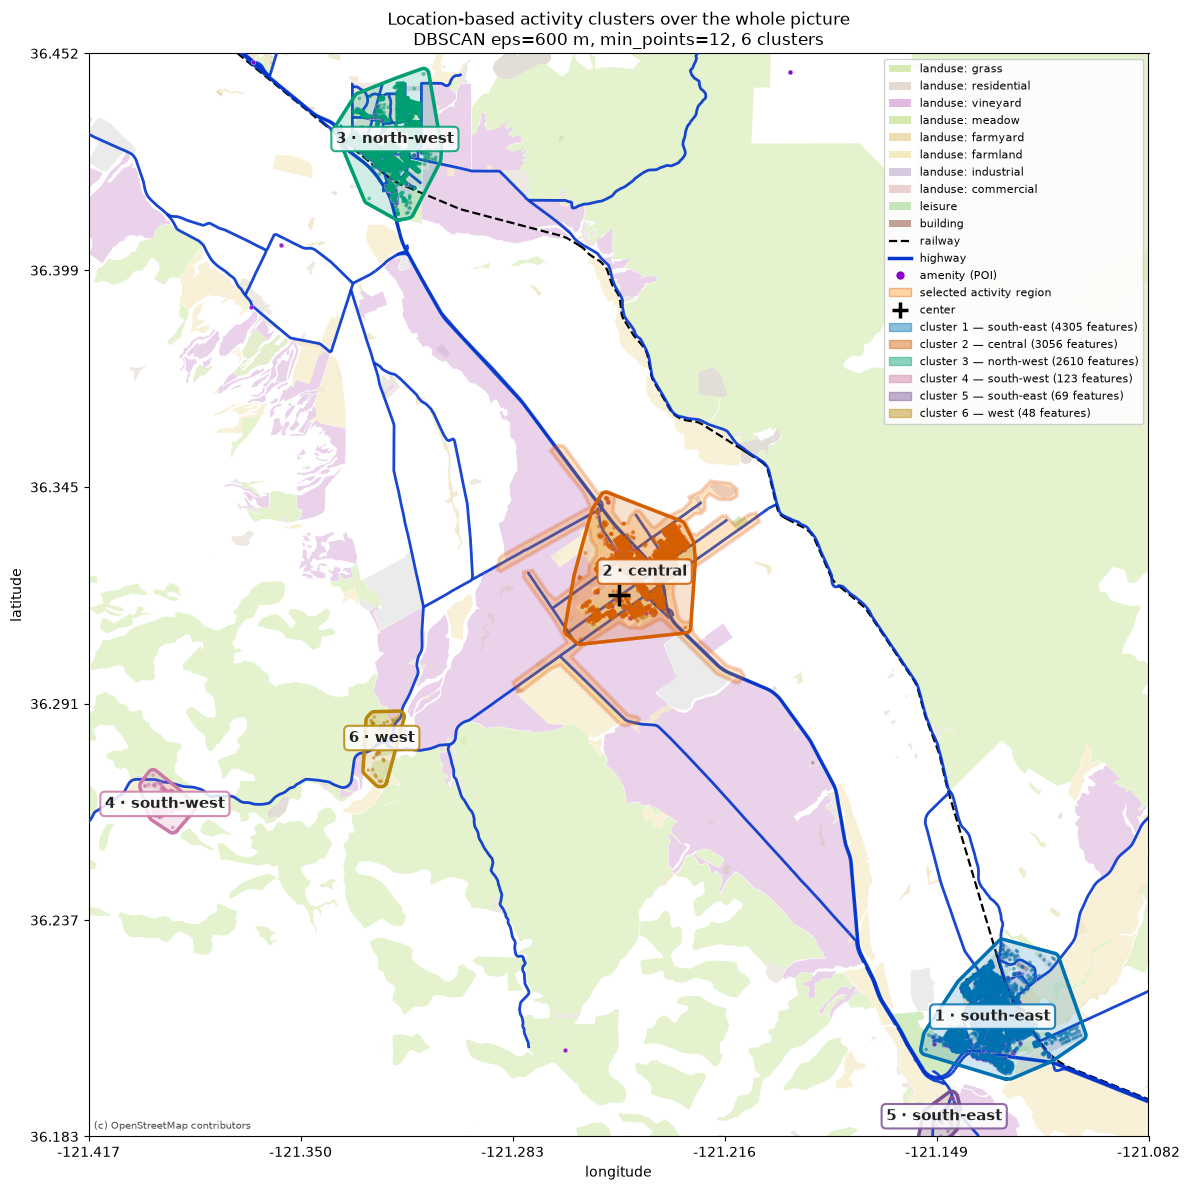

In [8]:
"""
Location-based clustering of activity features (picture-position summary).

Consumes `shapely_layers` and `cluster_result` from the clustering cell —
no network requests. Every activity feature is reduced to one point
(amenity POIs as-is; buildings, positive landuse and positive leisure
polygons as centroids), projected to local UTM meters, and grouped with
a DBSCAN-style density clustering built on scipy's cKDTree (no sklearn).

Each cluster is then placed on a 3x3 compass grid spanning the whole
picture (north-west / north / ... / central / ... / south-east), so the
result reads as "in the north-west part of the picture there is ...".

Draws the OSM feature map (plot_region_map) with the clusters on top and
prints a plain-language description. Leaves `location_clusters` (list of
dicts, largest first) and `location_cluster_description` in the kernel.
"""

from __future__ import annotations

import math
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from shapely.geometry import MultiPoint

# ---------------------------------------------------------------------------
# Clustering parameters
# ---------------------------------------------------------------------------
CLUSTER_EPS_M = 600.0      # two points closer than this are neighbours
CLUSTER_MIN_POINTS = 12    # neighbours (incl. self) needed for a core point
MIN_CLUSTER_SIZE = 20      # clusters smaller than this are treated as noise
HULL_PAD_M = 150.0         # visual padding around each cluster hull

# Fixed-order categorical palette (CVD + contrast validated on white).
# Cluster 1 always gets the first color, cluster 2 the second, and so on;
# clusters beyond the palette are drawn gray ("smaller clusters").
CLUSTER_COLORS = [
    "#0072B2", "#D55E00", "#009E73",
    "#CC79A7", "#7A5195", "#B8860B",
]
MINOR_CLUSTER_COLOR = "#777777"

_required = (
    "shapely_layers", "cluster_result", "plot_region_map",
    "west", "south", "east", "north",
    "POSITIVE_LANDUSE", "POSITIVE_LEISURE",
    "transform_layer_geometry", "merc_arr",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables from earlier cells: " + ", ".join(_missing)
        + " — run the OSM feature cell and the clustering cell first"
    )


# ---------------------------------------------------------------------------
# 1. Every activity feature becomes one (lon, lat, category, detail) point
# ---------------------------------------------------------------------------
def collect_activity_points(layers: dict) -> list[tuple[float, float, str, str]]:
    points = []

    for point, amenity_type in layers["amenity"]:
        points.append((point.x, point.y, "amenity", amenity_type))

    for polygon in layers["building"]:
        centroid = polygon.centroid
        points.append((centroid.x, centroid.y, "building", "building"))

    for polygon, landuse_type in layers["landuse"]:
        if landuse_type in POSITIVE_LANDUSE:
            centroid = polygon.centroid
            points.append((centroid.x, centroid.y, "landuse", landuse_type))

    for polygon, leisure_type in layers["leisure"]:
        if leisure_type in POSITIVE_LEISURE:
            centroid = polygon.centroid
            points.append((centroid.x, centroid.y, "leisure", leisure_type))

    return points


# ---------------------------------------------------------------------------
# 2. DBSCAN on scipy's cKDTree
# ---------------------------------------------------------------------------
def dbscan_labels(
    xy_m: np.ndarray,
    eps_m: float,
    min_points: int,
) -> np.ndarray:
    """Return one cluster label per point (-1 = noise)."""
    n = len(xy_m)
    tree = cKDTree(xy_m)
    neighbor_lists = tree.query_ball_point(xy_m, r=eps_m)
    core = np.array(
        [len(neighbors) >= min_points for neighbors in neighbor_lists]
    )

    labels = np.full(n, -1, dtype=int)
    cluster_id = 0
    for seed in range(n):
        if not core[seed] or labels[seed] != -1:
            continue
        labels[seed] = cluster_id
        frontier = [seed]
        while frontier:
            current = frontier.pop()
            for neighbor in neighbor_lists[current]:
                if labels[neighbor] == -1:
                    labels[neighbor] = cluster_id
                    if core[neighbor]:
                        frontier.append(neighbor)
        cluster_id += 1
    return labels


# ---------------------------------------------------------------------------
# 3. Where in the picture is a point? (3x3 compass grid over the bbox)
# ---------------------------------------------------------------------------
def picture_part(lon: float, lat: float) -> str:
    fx = (lon - west) / (east - west)
    fy = (lat - south) / (north - south)
    col = 0 if fx < 1 / 3 else (2 if fx > 2 / 3 else 1)
    row = 2 if fy > 2 / 3 else (0 if fy < 1 / 3 else 1)
    names = {
        (2, 0): "north-west", (2, 1): "north",   (2, 2): "north-east",
        (1, 0): "west",       (1, 1): "central", (1, 2): "east",
        (0, 0): "south-west", (0, 1): "south",   (0, 2): "south-east",
    }
    return names[(row, col)]


def compass_from_center(dx_m: float, dy_m: float) -> str:
    angle = math.degrees(math.atan2(dx_m, dy_m)) % 360.0
    names = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    return names[int((angle + 22.5) // 45) % 8]


# ---------------------------------------------------------------------------
# 4. Run the clustering and summarize each cluster
# ---------------------------------------------------------------------------
activity_points = collect_activity_points(shapely_layers)
if not activity_points:
    raise RuntimeError("no activity features to cluster — check the layers")

point_lons = np.array([p[0] for p in activity_points])
point_lats = np.array([p[1] for p in activity_points])
point_categories = np.array([p[2] for p in activity_points])
point_details = [p[3] for p in activity_points]

_x_m, _y_m = cluster_result["to_utm"].transform(point_lons, point_lats)
points_utm = np.column_stack([_x_m, _y_m])

point_labels = dbscan_labels(points_utm, CLUSTER_EPS_M, CLUSTER_MIN_POINTS)

center_utm = cluster_result["center_utm"]
to_wgs84 = cluster_result["to_wgs84"]

location_clusters = []
for cluster_id in np.unique(point_labels):
    if cluster_id < 0:
        continue
    member_index = np.where(point_labels == cluster_id)[0]
    if len(member_index) < MIN_CLUSTER_SIZE:
        point_labels[member_index] = -1
        continue

    hull_utm = (
        MultiPoint([tuple(p) for p in points_utm[member_index]])
        .convex_hull
        .buffer(HULL_PAD_M)
    )
    hull_wgs84 = transform_layer_geometry(hull_utm, to_wgs84)

    centroid_lon = float(point_lons[member_index].mean())
    centroid_lat = float(point_lats[member_index].mean())
    centroid_x = float(points_utm[member_index, 0].mean())
    centroid_y = float(points_utm[member_index, 1].mean())

    min_x, min_y, max_x, max_y = hull_utm.bounds
    dx_m = centroid_x - center_utm.x
    dy_m = centroid_y - center_utm.y

    category_counts = Counter(point_categories[member_index])
    top_amenities = Counter(
        point_details[i]
        for i in member_index
        if point_categories[i] == "amenity"
    ).most_common(3)

    location_clusters.append({
        "size": int(len(member_index)),
        "member_index": member_index,
        "part": picture_part(centroid_lon, centroid_lat),
        "centroid_lonlat": (centroid_lon, centroid_lat),
        "hull_utm": hull_utm,
        "hull_wgs84": hull_wgs84,
        "extent_km": ((max_x - min_x) / 1000.0, (max_y - min_y) / 1000.0),
        "distance_from_center_km": math.hypot(dx_m, dy_m) / 1000.0,
        "compass_from_center": compass_from_center(dx_m, dy_m),
        "category_counts": dict(category_counts),
        "top_amenities": top_amenities,
    })

location_clusters.sort(key=lambda c: c["size"], reverse=True)
for rank, cluster in enumerate(location_clusters, start=1):
    cluster["rank"] = rank
    cluster["color"] = (
        CLUSTER_COLORS[rank - 1]
        if rank <= len(CLUSTER_COLORS)
        else MINOR_CLUSTER_COLOR
    )

noise_count = int((point_labels < 0).sum())


# ---------------------------------------------------------------------------
# 5. Plain-language description ("in the X part of the picture ...")
# ---------------------------------------------------------------------------
_CATEGORY_PHRASES = {
    "building": "buildings",
    "amenity": "amenity POIs",
    "landuse": "activity landuse areas",
    "leisure": "leisure areas",
}

description_lines = []
for cluster in location_clusters:
    breakdown = ", ".join(
        f"{cluster['category_counts'][key]} {phrase}"
        for key, phrase in _CATEGORY_PHRASES.items()
        if cluster["category_counts"].get(key)
    )
    if cluster["top_amenities"]:
        amenity_names = ", ".join(name for name, _ in cluster["top_amenities"])
        breakdown += f"; top amenities: {amenity_names}"

    width_km, height_km = cluster["extent_km"]
    part = cluster["part"]
    where = (
        "In the central part of the picture"
        if part == "central"
        else f"In the {part} part of the picture"
    )
    description_lines.append(
        f"{where}, cluster {cluster['rank']} groups "
        f"{cluster['size']} activity features ({breakdown}) over "
        f"~{width_km:.1f} x {height_km:.1f} km, about "
        f"{cluster['distance_from_center_km']:.1f} km "
        f"{cluster['compass_from_center']} of the center."
    )

if not description_lines:
    description_lines.append(
        "No dense activity cluster was found — lower CLUSTER_MIN_POINTS "
        "or raise CLUSTER_EPS_M."
    )
description_lines.append(
    f"{noise_count} scattered features did not belong to any cluster."
)

location_cluster_description = "\n".join(description_lines)
print(location_cluster_description)


# ---------------------------------------------------------------------------
# 6. Draw the clusters on top of the OSM feature map
# ---------------------------------------------------------------------------
fig, ax, handles = plot_region_map(
    "Location-based activity clusters over the whole picture\n"
    f"DBSCAN eps={CLUSTER_EPS_M:.0f} m, "
    f"min_points={CLUSTER_MIN_POINTS}, "
    f"{len(location_clusters)} clusters"
)

for cluster in location_clusters:
    color = cluster["color"]

    exterior = np.asarray(cluster["hull_wgs84"].exterior.coords)
    hull_x, hull_y = merc_arr(exterior[:, 0], exterior[:, 1])
    ax.fill(
        hull_x, hull_y,
        facecolor=color, edgecolor=color,
        linewidth=2.5, alpha=0.18, zorder=5,
    )
    ax.plot(hull_x, hull_y, color=color, linewidth=2.5, zorder=5.1)

    member_index = cluster["member_index"]
    member_x, member_y = merc_arr(
        point_lons[member_index], point_lats[member_index]
    )
    ax.scatter(
        member_x, member_y,
        s=7, c=color, alpha=0.55,
        edgecolors="none", zorder=5.2,
    )

    label_lon, label_lat = cluster["centroid_lonlat"]
    label_x, label_y = merc_arr(
        np.array([label_lon]), np.array([label_lat])
    )
    ax.text(
        label_x[0], label_y[0],
        f"{cluster['rank']} · {cluster['part']}",
        fontsize=11, fontweight="bold", color="#222222",
        ha="center", va="center", zorder=6,
        bbox={
            "boxstyle": "round,pad=0.3",
            "fc": "white", "ec": color,
            "lw": 1.5, "alpha": 0.85,
        },
    )

    handles.append(
        Patch(
            facecolor=color, edgecolor=color, alpha=0.45,
            label=(
                f"cluster {cluster['rank']} — {cluster['part']} "
                f"({cluster['size']} features)"
            ),
        )
    )

ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()


In the north-west part of the picture, residential region R1 spans ~14.5 km2 (~3.15 km2 residential landuse, 2356 buildings) over ~7.9 x 7.7 km, about 13.9 km NW of the center.
In the south-east part of the picture, residential region R2 spans ~18.4 km2 (~2.69 km2 residential landuse, 3902 buildings) over ~7.8 x 8.8 km, about 15.8 km SE of the center.
In the south-west part of the picture, residential region R3 spans ~4.1 km2 (~0.59 km2 residential landuse, 121 buildings) over ~6.3 x 2.0 km, about 14.0 km SW of the center.
In the north-west part of the picture, residential region R4 spans ~11.0 km2 (~0.36 km2 residential landuse, 0 buildings) over ~5.8 x 3.9 km, about 12.9 km NW of the center.
In the west part of the picture, residential region R5 spans ~5.3 km2 (~0.35 km2 residential landuse, 41 buildings) over ~5.9 x 5.2 km, about 7.3 km SW of the center.
(the central residential cluster reproduces the already-selected activity region (drawn in orange) and is not re-numbered)
(seed n

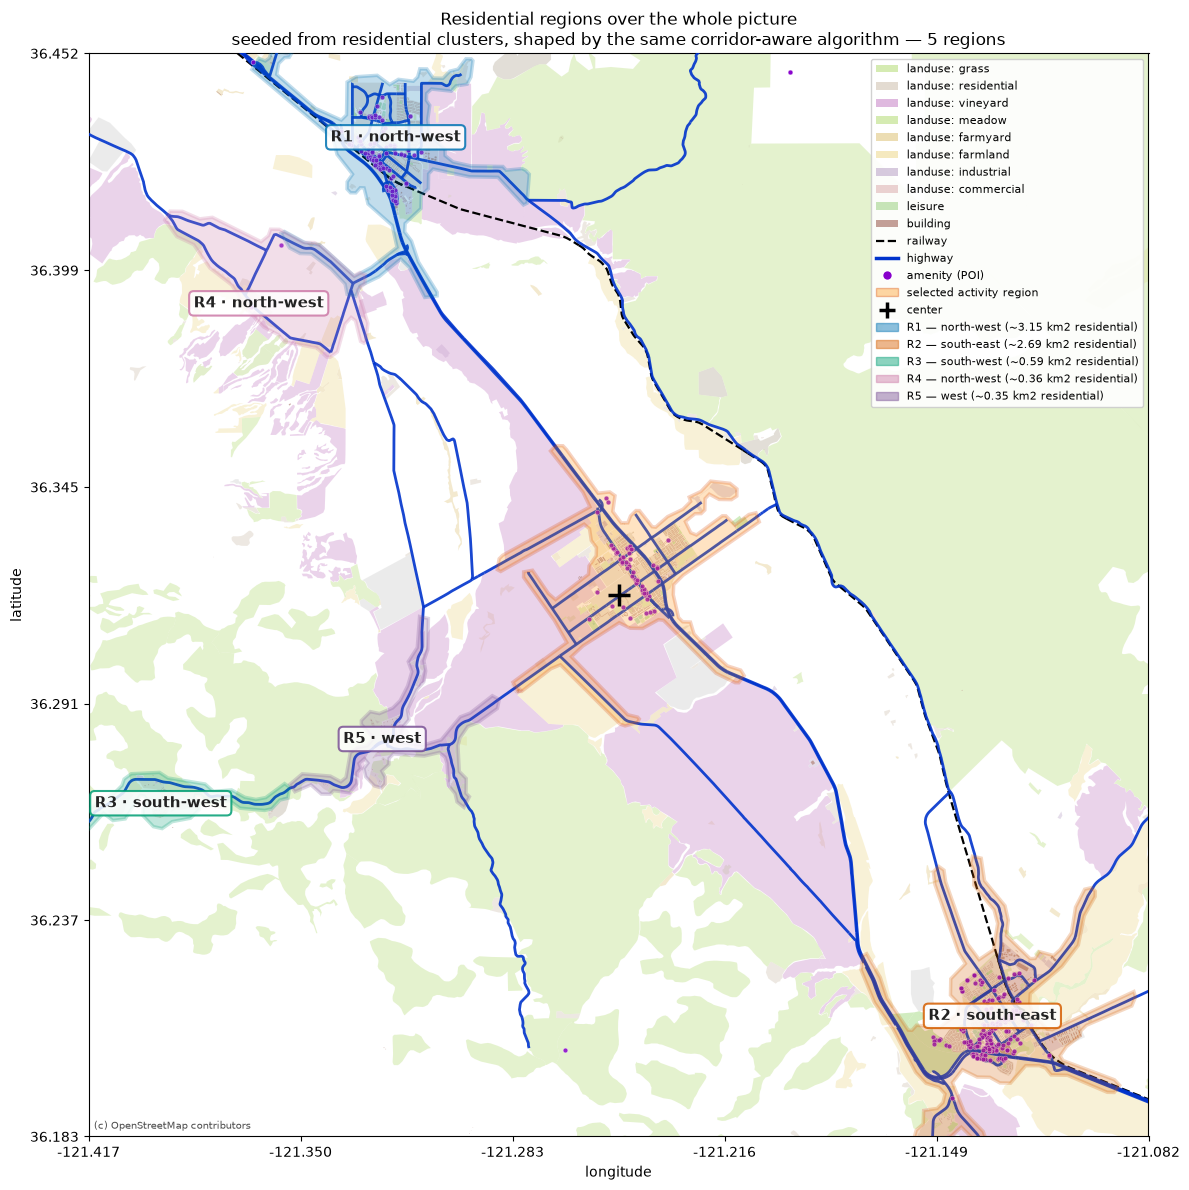

In [9]:
"""
Residential-region extraction over the whole picture.

Two stages, reusing the earlier cells' machinery unchanged:

1. FIND the residential spots: residential-landuse polygons are sampled
   on a ~RES_GRID_STEP_M grid (a large residential area contributes
   points in proportion to its area) plus building centroids, then
   grouped with the location-clustering cell's dbscan_labels.
2. SHAPE each spot with the SAME corridor-aware algorithm as the
   center-seeded clustering cell: every cluster centroid becomes the
   seed of build_center_seeded_region, so every extracted region has
   the same organic, along-the-highway shape as the original orange
   activity region (not a convex hull).

The cluster that reproduces the already-selected activity region is
skipped (the orange region stays as drawn by plot_region_map); regions
that merge into an already-extracted one are skipped too. Leaves
`residential_regions` (list of dicts, most residential area first,
each with region_wgs84/region_utm like cluster_result) and
`residential_region_description` in the kernel.
"""

from __future__ import annotations

import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from shapely.geometry import MultiPoint, MultiPolygon, Point
from shapely.prepared import prep

# ---------------------------------------------------------------------------
# Residential-clustering parameters
# ---------------------------------------------------------------------------
RES_GRID_STEP_M = 120.0        # sampling step inside residential polygons
RES_EPS_M = 500.0              # two points closer than this are neighbours
RES_MIN_POINTS = 10            # neighbours (incl. self) needed for a core point
RES_MIN_CLUSTER_SIZE = 20      # clusters smaller than this are treated as noise
RES_MIN_LANDUSE_POINTS = 6     # required residential-landuse samples per cluster
                               # (set to 0 to also keep building-only clusters)

# A region overlapping the selected activity region (or an already
# extracted one) by more than this fraction of the smaller area is
# treated as a duplicate and skipped.
RES_DUPLICATE_OVERLAP = 0.5

_required = (
    "shapely_layers", "cluster_result", "plot_region_map",
    "build_center_seeded_region",
    "dbscan_labels", "picture_part", "compass_from_center",
    "transform_layer_geometry", "merc_arr",
    "west", "south", "east", "north",
    "CENTER_LAT", "CENTER_LON",
    "CLUSTER_COLORS", "MINOR_CLUSTER_COLOR",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables from earlier cells: " + ", ".join(_missing)
        + " — run the OSM feature, clustering and location-clustering "
        "cells first"
    )


# ---------------------------------------------------------------------------
# 1. Residential evidence points (in local UTM meters)
# ---------------------------------------------------------------------------
def residential_evidence_points(
    layers: dict,
    to_utm,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (points_utm[N,2], sources[N]) with source in
    {"residential", "building"}."""
    xs: list[float] = []
    ys: list[float] = []
    sources: list[str] = []

    for polygon, landuse_type in layers["landuse"]:
        if landuse_type != "residential":
            continue
        polygon_utm = transform_layer_geometry(polygon, to_utm)
        if polygon_utm.is_empty:
            continue

        min_x, min_y, max_x, max_y = polygon_utm.bounds
        grid_x = np.arange(min_x + RES_GRID_STEP_M / 2, max_x, RES_GRID_STEP_M)
        grid_y = np.arange(min_y + RES_GRID_STEP_M / 2, max_y, RES_GRID_STEP_M)
        prepared = prep(polygon_utm)

        added = 0
        for gx in grid_x:
            for gy in grid_y:
                if prepared.covers(Point(gx, gy)):
                    xs.append(float(gx))
                    ys.append(float(gy))
                    sources.append("residential")
                    added += 1

        if added == 0:  # polygon smaller than one grid step
            centroid = polygon_utm.centroid
            xs.append(centroid.x)
            ys.append(centroid.y)
            sources.append("residential")

    building_lons = [poly.centroid.x for poly in layers["building"]]
    building_lats = [poly.centroid.y for poly in layers["building"]]
    if building_lons:
        bx, by = to_utm.transform(
            np.asarray(building_lons), np.asarray(building_lats)
        )
        xs.extend(bx.tolist())
        ys.extend(by.tolist())
        sources.extend(["building"] * len(building_lons))

    if not xs:
        return np.empty((0, 2)), np.empty(0, dtype=object)
    return np.column_stack([xs, ys]), np.asarray(sources)


res_points_utm, res_point_sources = residential_evidence_points(
    shapely_layers, cluster_result["to_utm"]
)
if len(res_points_utm) == 0:
    raise RuntimeError(
        "no residential landuse or buildings in the window — nothing to extract"
    )

res_labels = dbscan_labels(res_points_utm, RES_EPS_M, RES_MIN_POINTS)

_center_utm = cluster_result["center_utm"]
_to_wgs84 = cluster_result["to_wgs84"]
_to_utm = cluster_result["to_utm"]
_selected_region_utm = cluster_result["region_utm"]


# ---------------------------------------------------------------------------
# 2. Turn every dense residential cluster into a SEED, then shape the
#    region with the center-seeded corridor-aware algorithm from the
#    clustering cell — the same organic, along-the-highway outline as
#    the selected activity region.
# ---------------------------------------------------------------------------
def build_seeded_region_at(lat: float, lon: float) -> dict:
    """Run build_center_seeded_region with a temporary center."""
    global CENTER_LAT, CENTER_LON
    saved = (CENTER_LAT, CENTER_LON)
    CENTER_LAT, CENTER_LON = float(lat), float(lon)
    try:
        return build_center_seeded_region(shapely_layers)
    finally:
        CENTER_LAT, CENTER_LON = saved


def overlap_ratio(region_a_utm, region_b_utm) -> float:
    """Intersection area over the smaller region's area."""
    denominator = min(region_a_utm.area, region_b_utm.area)
    if denominator <= 0:
        return 0.0
    return region_a_utm.intersection(region_b_utm).area / denominator


seed_clusters = []
for cluster_id in np.unique(res_labels):
    if cluster_id < 0:
        continue
    member_index = np.where(res_labels == cluster_id)[0]
    residential_count = int(
        (res_point_sources[member_index] == "residential").sum()
    )
    building_count = int(
        (res_point_sources[member_index] == "building").sum()
    )
    if (
        len(member_index) < RES_MIN_CLUSTER_SIZE
        or residential_count < RES_MIN_LANDUSE_POINTS
    ):
        res_labels[member_index] = -1
        continue

    centroid_x = float(res_points_utm[member_index, 0].mean())
    centroid_y = float(res_points_utm[member_index, 1].mean())
    centroid_lon, centroid_lat = _to_wgs84.transform(centroid_x, centroid_y)

    seed_clusters.append({
        "member_index": member_index,
        "residential_points": residential_count,
        "building_points": building_count,
        # each residential sample stands for one grid step of area
        "residential_area_km2": residential_count
        * (RES_GRID_STEP_M / 1000.0) ** 2,
        "centroid_lonlat": (float(centroid_lon), float(centroid_lat)),
        "centroid_utm": (centroid_x, centroid_y),
    })

# Biggest residential fabric first, so duplicates collapse onto the
# strongest seed.
seed_clusters.sort(key=lambda c: c["residential_area_km2"], reverse=True)

residential_regions = []
skipped_notes = []
for cluster in seed_clusters:
    centroid_lon, centroid_lat = cluster["centroid_lonlat"]

    try:
        seeded = build_seeded_region_at(centroid_lat, centroid_lon)
    except RuntimeError as error:
        skipped_notes.append(
            f"seed near ({centroid_lat:.4f}, {centroid_lon:.4f}) "
            f"produced no region ({error})"
        )
        continue

    # Bring the region into the ORIGINAL center's UTM frame so overlaps
    # and distances are comparable.
    region_wgs84 = seeded["region_wgs84"]
    region_utm = transform_layer_geometry(region_wgs84, _to_utm)

    if overlap_ratio(region_utm, _selected_region_utm) > RES_DUPLICATE_OVERLAP:
        skipped_notes.append(
            "the central residential cluster reproduces the already-"
            "selected activity region (drawn in orange) and is not "
            "re-numbered"
        )
        continue

    duplicate_of = next(
        (
            other["rank"]
            for other in residential_regions
            if overlap_ratio(region_utm, other["region_utm"])
            > RES_DUPLICATE_OVERLAP
        ),
        None,
    )
    if duplicate_of is not None:
        skipped_notes.append(
            f"seed near ({centroid_lat:.4f}, {centroid_lon:.4f}) merged "
            f"into region R{duplicate_of}"
        )
        continue

    min_x, min_y, max_x, max_y = region_utm.bounds
    dx_m = float(region_utm.centroid.x - _center_utm.x)
    dy_m = float(region_utm.centroid.y - _center_utm.y)

    residential_regions.append({
        **cluster,
        "rank": len(residential_regions) + 1,
        "region_wgs84": region_wgs84,
        "region_utm": region_utm,
        "region_area_km2": region_utm.area / 1e6,
        "part": picture_part(centroid_lon, centroid_lat),
        "extent_km": ((max_x - min_x) / 1000.0, (max_y - min_y) / 1000.0),
        "distance_from_center_km": math.hypot(dx_m, dy_m) / 1000.0,
        "compass_from_center": compass_from_center(dx_m, dy_m),
    })

for region in residential_regions:
    region["color"] = (
        CLUSTER_COLORS[region["rank"] - 1]
        if region["rank"] <= len(CLUSTER_COLORS)
        else MINOR_CLUSTER_COLOR
    )


# ---------------------------------------------------------------------------
# 3. Plain-language description
# ---------------------------------------------------------------------------
description_lines = []
for region in residential_regions:
    width_km, height_km = region["extent_km"]
    part = region["part"]
    where = (
        "In the central part of the picture"
        if part == "central"
        else f"In the {part} part of the picture"
    )
    description_lines.append(
        f"{where}, residential region R{region['rank']} spans "
        f"~{region['region_area_km2']:.1f} km2 "
        f"(~{region['residential_area_km2']:.2f} km2 residential landuse, "
        f"{region['building_points']} buildings) over "
        f"~{width_km:.1f} x {height_km:.1f} km, about "
        f"{region['distance_from_center_km']:.1f} km "
        f"{region['compass_from_center']} of the center."
    )

if not description_lines:
    description_lines.append(
        "No residential region was found — lower RES_MIN_LANDUSE_POINTS "
        "or RES_MIN_CLUSTER_SIZE, or raise RES_EPS_M."
    )
description_lines.extend(f"({note})" for note in skipped_notes)

residential_region_description = "\n".join(description_lines)
print(residential_region_description)


# ---------------------------------------------------------------------------
# 4. Draw the residential regions on top of the OSM feature map
# ---------------------------------------------------------------------------
def fill_region(ax, region_wgs84, color):
    polygons = (
        list(region_wgs84.geoms)
        if isinstance(region_wgs84, MultiPolygon)
        else [region_wgs84]
    )
    for polygon in polygons:
        exterior = np.asarray(polygon.exterior.coords)
        x, y = merc_arr(exterior[:, 0], exterior[:, 1])
        ax.fill(
            x, y,
            facecolor=color, edgecolor=color,
            linewidth=2.5, alpha=0.24, zorder=5,
        )


fig, ax, handles = plot_region_map(
    "Residential regions over the whole picture\n"
    "seeded from residential clusters, shaped by the same "
    f"corridor-aware algorithm — {len(residential_regions)} regions"
)

for region in residential_regions:
    color = region["color"]
    fill_region(ax, region["region_wgs84"], color)

    label_lon, label_lat = region["centroid_lonlat"]
    label_x, label_y = merc_arr(
        np.array([label_lon]), np.array([label_lat])
    )
    ax.text(
        label_x[0], label_y[0],
        f"R{region['rank']} · {region['part']}",
        fontsize=11, fontweight="bold", color="#222222",
        ha="center", va="center", zorder=6,
        bbox={
            "boxstyle": "round,pad=0.3",
            "fc": "white", "ec": color,
            "lw": 1.5, "alpha": 0.85,
        },
    )

    handles.append(
        Patch(
            facecolor=color, edgecolor=color, alpha=0.45,
            label=(
                f"R{region['rank']} — {region['part']} "
                f"(~{region['residential_area_km2']:.2f} km2 residential)"
            ),
        )
    )

ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()


selected region area: 16.418 km^2
downsampled coordinates: 248
outputs written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output
all coordinates (sorted by distance to center, nearest first):
point_id  latitude   longitude    source  distance_to_center_m  circle_radius_m
   P0001 36.317690 -121.249620    center              0.000000             10.0
   P0002 36.316512 -121.251161   highway            190.332324             10.0
   P0003 36.318388 -121.247654 area_grid            192.748628             10.0
   P0004 36.320360 -121.249003 area_grid            301.358301             10.0
   P0005 36.318470 -121.253222 area_grid            334.805253             10.0
   P0006 36.320400 -121.251787 area_grid            358.173265             10.0
   P0007 36.314527 -121.250525 area_grid            360.229057             10.0
   P0008 36.319688 -121.245451   highway            435.056848             10.0
   P0009 36.314275 -121.247218   highway            436.005949             

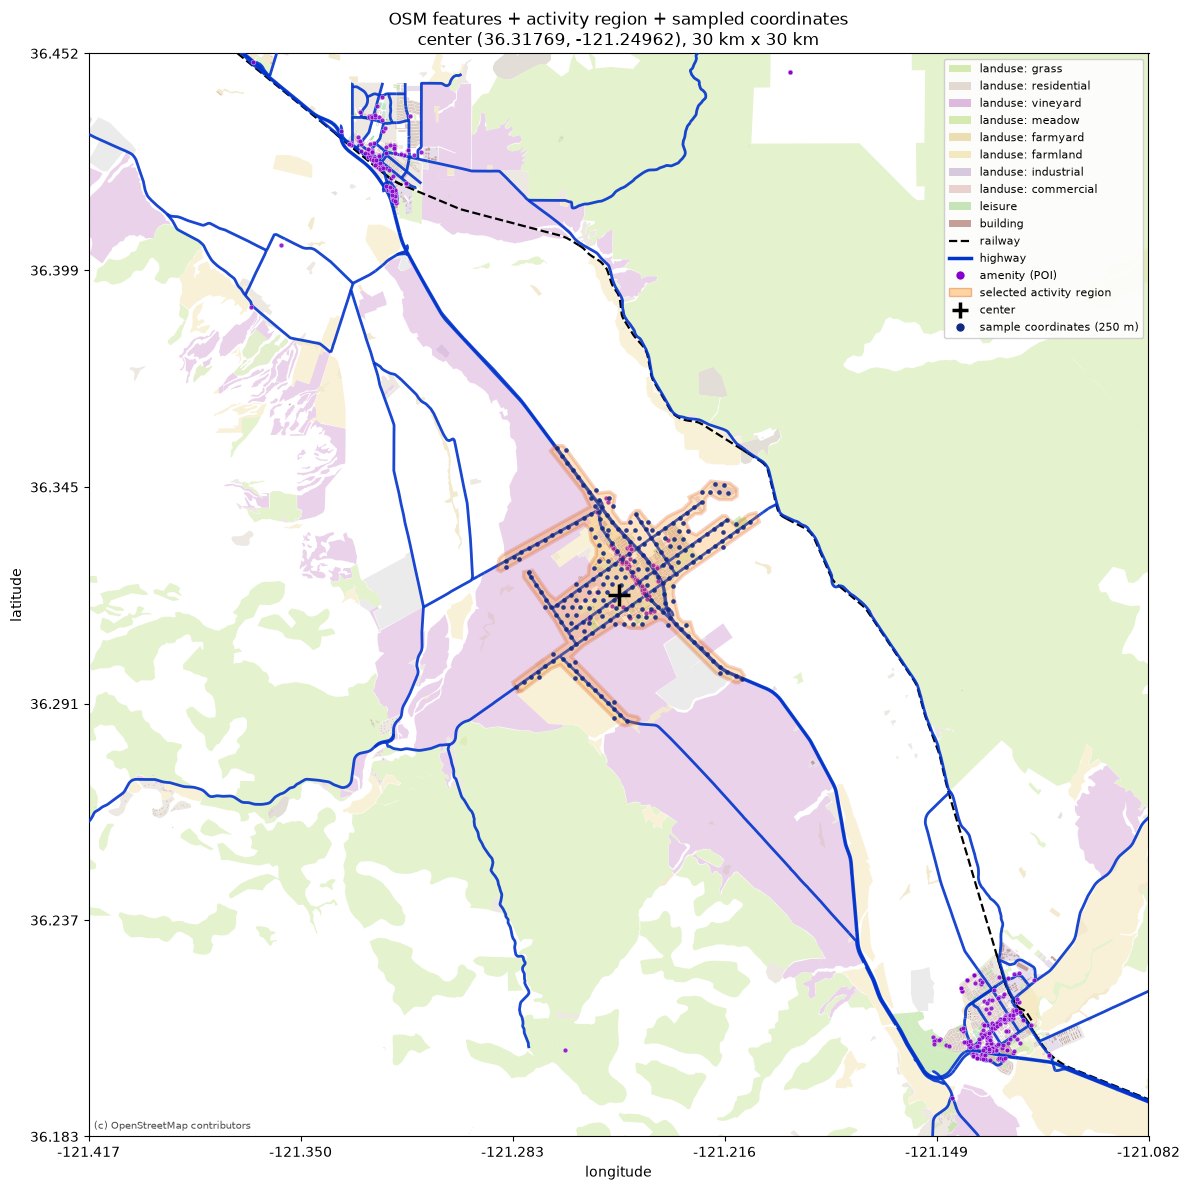

figure written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output/activity_region_and_samples.png
coordinate_list variable is ready; length=248


In [7]:
"""
Coordinate downsampling, export and plotting (step 2 of 2).

Consumes `cluster_result` and `plot_region_map` from the clustering
cell: downsamples coordinates inside the selected region, exports them,
and re-draws the region map with the sampled coordinates on top.
No network requests, no tile basemap.
"""

from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import LineString, MultiPolygon, Point, Polygon, mapping


# ============================================================================
# Sampling / output configuration
# ============================================================================

# Coordinate downsampling.
SAMPLE_SPACING_M = 250.0
MIN_SAMPLE_SEPARATION_M = SAMPLE_SPACING_M * 0.65
CIRCLE_RADIUS_M = 10.0

# Set to True to apply the minimum-distance filter (downsampling).
# Set to False to keep and output ALL candidate coordinates.
APPLY_DOWNSAMPLING = True

OUTPUT_DIR = Path("osm_activity_output")

# Color of the sampled coordinates drawn on top of the region map.
SAMPLE_POINT_COLOR = "#102a83"


# ============================================================================
# Coordinate downsampling
# ============================================================================

# ============================================================================
# Coordinate downsampling
# ============================================================================

def iter_line_parts(geometry) -> Iterator[LineString]:
    if geometry is None or geometry.is_empty:
        return

    if isinstance(geometry, LineString):
        yield geometry
        return

    if isinstance(geometry, MultiLineString):
        yield from geometry.geoms
        return

    if isinstance(geometry, GeometryCollection):
        for part in geometry.geoms:
            yield from iter_line_parts(part)


def make_hex_grid_candidates(
    polygon,
    spacing_m: float,
) -> list[tuple[Point, str]]:
    min_x, min_y, max_x, max_y = polygon.bounds
    row_height = spacing_m * math.sqrt(3.0) / 2.0

    candidates = []
    row_index = 0
    y = min_y

    while y <= max_y:
        x_offset = (
            spacing_m / 2.0
            if row_index % 2
            else 0.0
        )
        x = min_x + x_offset

        while x <= max_x:
            point = Point(x, y)
            if polygon.covers(point):
                candidates.append(
                    (point, "area_grid")
                )
            x += spacing_m

        y += row_height
        row_index += 1

    return candidates


def make_highway_candidates(
    highway_lines_utm: list,
    region_utm,
    spacing_m: float,
) -> list[tuple[Point, str]]:
    candidates = []

    for highway in highway_lines_utm:
        clipped = highway.intersection(region_utm)

        for line in iter_line_parts(clipped):
            if line.length <= 0:
                continue

            distances = np.arange(
                0.0,
                line.length + 1e-9,
                spacing_m,
            )

            for distance in distances:
                point = line.interpolate(float(distance))
                if region_utm.covers(point):
                    candidates.append(
                        (point, "highway")
                    )

            endpoint = line.interpolate(line.length)
            if region_utm.covers(endpoint):
                candidates.append(
                    (endpoint, "highway")
                )

    return candidates


def greedy_minimum_distance_filter(
    candidates: list[tuple[Point, str]],
    minimum_distance_m: float,
) -> list[tuple[Point, str]]:
    selected = []

    for point, source in candidates:
        too_close = any(
            point.distance(existing_point)
            < minimum_distance_m
            for existing_point, _ in selected
        )

        if not too_close:
            selected.append((point, source))

    return selected


def generate_downsampled_coordinates(
    cluster_result: dict,
) -> pd.DataFrame:
    center_utm = cluster_result["center_utm"]
    region_utm = cluster_result["region_utm"]
    highway_lines_utm = cluster_result[
        "highway_lines_utm"
    ]
    to_wgs84 = cluster_result["to_wgs84"]

    # Candidate priority:
    # exact center -> highway samples -> area grid samples.
    candidates = [(center_utm, "center")]
    candidates.extend(
        make_highway_candidates(
            highway_lines_utm,
            region_utm,
            SAMPLE_SPACING_M,
        )
    )
    candidates.extend(
        make_hex_grid_candidates(
            region_utm,
            SAMPLE_SPACING_M,
        )
    )

    if APPLY_DOWNSAMPLING:
        selected = greedy_minimum_distance_filter(
            candidates,
            MIN_SAMPLE_SEPARATION_M,
        )
    else:
        selected = list(candidates)

    rows = []
    for index, (point_utm, source) in enumerate(
        selected,
        start=1,
    ):
        point_wgs84 = transform_layer_geometry(
            point_utm,
            to_wgs84,
        )

        rows.append(
            {
                "point_id": f"P{index:04d}",
                "latitude": point_wgs84.y,
                "longitude": point_wgs84.x,
                "source": source,
                "distance_to_center_m": (
                    point_utm.distance(center_utm)
                ),
                "circle_radius_m": CIRCLE_RADIUS_M,
            }
        )

    coordinate_df = pd.DataFrame(rows)
    coordinate_df = coordinate_df.sort_values(
        "distance_to_center_m"
    ).reset_index(drop=True)

    # Renumber after sorting.
    coordinate_df["point_id"] = [
        f"P{index:04d}"
        for index in range(
            1,
            len(coordinate_df) + 1,
        )
    ]

    return coordinate_df


# ============================================================================
# Export outputs
# ============================================================================

def save_geojson(
    path: Path,
    features: list[dict],
):
    payload = {
        "type": "FeatureCollection",
        "features": features,
    }
    path.write_text(
        json.dumps(payload, indent=2),
        encoding="utf-8",
    )


def export_results(
    cluster_result: dict,
    coordinate_df: pd.DataFrame,
):
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    region_wgs84 = cluster_result["region_wgs84"]
    to_utm = cluster_result["to_utm"]
    to_wgs84 = cluster_result["to_wgs84"]

    # Selected cluster polygon.
    save_geojson(
        OUTPUT_DIR / "selected_activity_region.geojson",
        [
            {
                "type": "Feature",
                "properties": {
                    "cluster_id": "center_cluster",
                },
                "geometry": mapping(region_wgs84),
            }
        ],
    )

    # Polygon boundary coordinate list.
    boundary_rows = [
        {
            "vertex_id": index,
            "latitude": lat,
            "longitude": lon,
        }
        for index, (lon, lat) in enumerate(
            region_wgs84.exterior.coords,
            start=1,
        )
    ]

    pd.DataFrame(boundary_rows).to_csv(
        OUTPUT_DIR
        / "region_boundary_coordinates.csv",
        index=False,
        float_format="%.8f",
    )

    # Downsampled sample-center coordinates.
    coordinate_df.to_csv(
        OUTPUT_DIR / "sample_coordinates.csv",
        index=False,
        float_format="%.8f",
    )

    (
        OUTPUT_DIR / "sample_coordinates.json"
    ).write_text(
        json.dumps(
            coordinate_df.to_dict(
                orient="records"
            ),
            indent=2,
        ),
        encoding="utf-8",
    )

    # A 10 m circle around every sampled coordinate.
    circle_features = []

    for row in coordinate_df.itertuples(
        index=False
    ):
        point_wgs84 = Point(
            row.longitude,
            row.latitude,
        )
        point_utm = transform_layer_geometry(
            point_wgs84,
            to_utm,
        )
        circle_utm = point_utm.buffer(
            CIRCLE_RADIUS_M
        )
        circle_wgs84 = transform_layer_geometry(
            circle_utm,
            to_wgs84,
        )

        circle_features.append(
            {
                "type": "Feature",
                "properties": {
                    "point_id": row.point_id,
                    "source": row.source,
                    "radius_m": CIRCLE_RADIUS_M,
                },
                "geometry": mapping(
                    circle_wgs84
                ),
            }
        )

    save_geojson(
        OUTPUT_DIR
        / "sample_circles_10m.geojson",
        circle_features,
    )

    # Convenient Python list requested by the user.
    coordinate_list = [
        (
            float(row.latitude),
            float(row.longitude),
        )
        for row in coordinate_df.itertuples(
            index=False
        )
    ]

    (
        OUTPUT_DIR / "coordinate_list.py"
    ).write_text(
        "coordinate_list = "
        + repr(coordinate_list)
        + "\n",
        encoding="utf-8",
    )

    print(
        f"selected region area: "
        f"{cluster_result['region_utm'].area / 1e6:.3f} km^2"
    )
    print(
        f"downsampled coordinates: "
        f"{len(coordinate_df)}"
    )
    print(
        f"outputs written to: "
        f"{OUTPUT_DIR.resolve()}"
    )
    print(
        "all coordinates (sorted by distance to center, nearest first):"
    )
    print(
        coordinate_df.to_string(
            index=False
        )
    )

    return coordinate_list




def plot_samples_on_region_map(coordinate_df):
    fig, ax, handles = plot_region_map(
        "OSM features + activity region + sampled coordinates\n"
        f"center ({CENTER_LAT}, {CENTER_LON}), "
        f"{BOX_KM:.0f} km x {BOX_KM:.0f} km"
    )

    sample_x, sample_y = merc_arr(
        coordinate_df["longitude"].to_numpy(),
        coordinate_df["latitude"].to_numpy(),
    )

    ax.scatter(
        sample_x,
        sample_y,
        s=11,
        c=SAMPLE_POINT_COLOR,
        marker="o",
        alpha=0.9,
        linewidths=0,
        zorder=5,
    )

    handles.append(
        plt.Line2D(
            [],
            [],
            color=SAMPLE_POINT_COLOR,
            marker="o",
            ls="none",
            ms=5,
            label=(
                f"sample coordinates "
                f"({SAMPLE_SPACING_M:.0f} m)"
            ),
        )
    )

    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
    fig.tight_layout()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    figure_path = OUTPUT_DIR / "activity_region_and_samples.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"figure written to: {figure_path.resolve()}")


# ============================================================================
# Run sampling, export and plotting
# ============================================================================

_required = (
    "cluster_result", "plot_region_map",
    "CENTER_LAT", "CENTER_LON", "BOX_KM",
    "merc", "merc_arr",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables: "
        + ", ".join(_missing)
        + " — run the first (OSM feature map) cell and the clustering cell first"
    )

coordinate_df = generate_downsampled_coordinates(cluster_result)
coordinate_list = export_results(cluster_result, coordinate_df)
plot_samples_on_region_map(coordinate_df)
print(f"coordinate_list variable is ready; length={len(coordinate_list)}")


R1 (north-west): 231 coordinates over 14.5 km2
R2 (south-east): 306 coordinates over 18.4 km2
R3 (south-west): 68 coordinates over 4.1 km2
R4 (north-west): 186 coordinates over 11.0 km2
R5 (west): 82 coordinates over 5.3 km2
total residential sample coordinates: 873
outputs written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output
figure written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output/residential_regions_and_samples.png


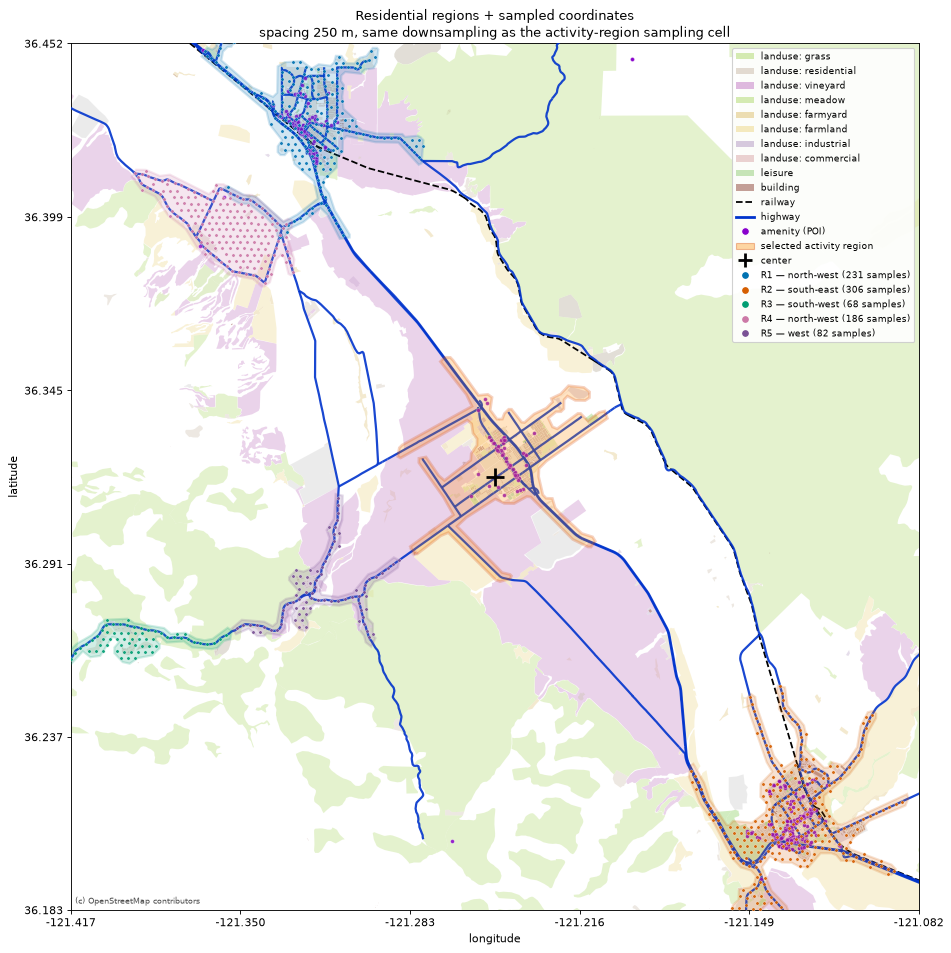

In [8]:
"""
Coordinate downsampling inside every residential region.

Applies the sampling cell's algorithm unchanged to each region in
`residential_regions`: region seed point first, then highway samples,
then a hexagonal area grid, then the same greedy minimum-distance
filter (SAMPLE_SPACING_M / MIN_SAMPLE_SEPARATION_M / APPLY_DOWNSAMPLING
are reused as-is). The only difference is the highway source: the
center cell's highway lines only cover the center's analysis window, so
here the full picture's highway layer is projected and clipped per
region.

Exports residential_sample_coordinates.csv/.json, region polygons and
10 m circles to OUTPUT_DIR, re-draws the region map with the samples on
top, and leaves `residential_coordinate_df` (one row per point,
point ids like R1-P0001) in the kernel.
"""

from __future__ import annotations

import json as _json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import MultiPolygon, Point, mapping

_required = (
    "residential_regions", "shapely_layers", "cluster_result",
    "plot_region_map", "transform_layer_geometry", "merc_arr",
    "make_hex_grid_candidates", "make_highway_candidates",
    "greedy_minimum_distance_filter",
    "SAMPLE_SPACING_M", "MIN_SAMPLE_SEPARATION_M", "CIRCLE_RADIUS_M",
    "APPLY_DOWNSAMPLING", "OUTPUT_DIR",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables from earlier cells: " + ", ".join(_missing)
        + " — run the residential-regions cell and the coordinate "
        "sampling cell first"
    )

_to_utm = cluster_result["to_utm"]
_to_wgs84 = cluster_result["to_wgs84"]

# The whole picture's highways in the original UTM frame (the center
# cell's highway_lines_utm are clipped to the center window only).
_all_highways_utm = [
    transform_layer_geometry(line, _to_utm)
    for line, _name in shapely_layers["highway"]
]


# ---------------------------------------------------------------------------
# 1. Sample every residential region with the sampling cell's algorithm
# ---------------------------------------------------------------------------
def sample_residential_region(region: dict) -> pd.DataFrame:
    region_utm = region["region_utm"]
    seed_utm = Point(*region["centroid_utm"])

    # Candidate priority: region seed -> highway samples -> area grid.
    candidates = [(seed_utm, "center")]
    candidates.extend(
        make_highway_candidates(
            _all_highways_utm, region_utm, SAMPLE_SPACING_M
        )
    )
    candidates.extend(
        make_hex_grid_candidates(region_utm, SAMPLE_SPACING_M)
    )

    if APPLY_DOWNSAMPLING:
        selected = greedy_minimum_distance_filter(
            candidates, MIN_SAMPLE_SEPARATION_M
        )
    else:
        selected = list(candidates)

    rows = []
    for point_utm, source in selected:
        point_wgs84 = transform_layer_geometry(point_utm, _to_wgs84)
        rows.append({
            "region": f"R{region['rank']}",
            "region_part": region["part"],
            "latitude": point_wgs84.y,
            "longitude": point_wgs84.x,
            "source": source,
            "distance_to_region_center_m": point_utm.distance(seed_utm),
            "circle_radius_m": CIRCLE_RADIUS_M,
        })

    frame = pd.DataFrame(rows)
    frame = frame.sort_values(
        "distance_to_region_center_m"
    ).reset_index(drop=True)
    frame.insert(
        0,
        "point_id",
        [
            f"R{region['rank']}-P{index:04d}"
            for index in range(1, len(frame) + 1)
        ],
    )
    return frame


_per_region_frames = [
    sample_residential_region(region) for region in residential_regions
]
residential_coordinate_df = pd.concat(
    _per_region_frames, ignore_index=True
)


# ---------------------------------------------------------------------------
# 2. Export (same shapes of output as the sampling cell)
# ---------------------------------------------------------------------------
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_region_features = [
    {
        "type": "Feature",
        "properties": {
            "region": f"R{region['rank']}",
            "part": region["part"],
            "residential_area_km2": region["residential_area_km2"],
            "region_area_km2": region["region_area_km2"],
        },
        "geometry": mapping(region["region_wgs84"]),
    }
    for region in residential_regions
]
(OUTPUT_DIR / "residential_regions.geojson").write_text(
    _json.dumps(
        {"type": "FeatureCollection", "features": _region_features},
        indent=2,
    ),
    encoding="utf-8",
)

residential_coordinate_df.to_csv(
    OUTPUT_DIR / "residential_sample_coordinates.csv",
    index=False,
    float_format="%.8f",
)
(OUTPUT_DIR / "residential_sample_coordinates.json").write_text(
    _json.dumps(
        residential_coordinate_df.to_dict(orient="records"), indent=2
    ),
    encoding="utf-8",
)

_circle_features = []
for row in residential_coordinate_df.itertuples(index=False):
    point_utm = transform_layer_geometry(
        Point(row.longitude, row.latitude), _to_utm
    )
    circle_wgs84 = transform_layer_geometry(
        point_utm.buffer(CIRCLE_RADIUS_M), _to_wgs84
    )
    _circle_features.append({
        "type": "Feature",
        "properties": {
            "point_id": row.point_id,
            "region": row.region,
            "source": row.source,
            "radius_m": CIRCLE_RADIUS_M,
        },
        "geometry": mapping(circle_wgs84),
    })
(OUTPUT_DIR / "residential_sample_circles_10m.geojson").write_text(
    _json.dumps(
        {"type": "FeatureCollection", "features": _circle_features},
        indent=2,
    ),
    encoding="utf-8",
)

for region, frame in zip(residential_regions, _per_region_frames):
    print(
        f"R{region['rank']} ({region['part']}): "
        f"{len(frame)} coordinates over "
        f"{region['region_area_km2']:.1f} km2"
    )
print(f"total residential sample coordinates: {len(residential_coordinate_df)}")
print(f"outputs written to: {OUTPUT_DIR.resolve()}")


# ---------------------------------------------------------------------------
# 3. Draw the residential regions with their sampled coordinates
# ---------------------------------------------------------------------------
def _fill_region(ax, region_wgs84, color):
    polygons = (
        list(region_wgs84.geoms)
        if isinstance(region_wgs84, MultiPolygon)
        else [region_wgs84]
    )
    for polygon in polygons:
        exterior = np.asarray(polygon.exterior.coords)
        x, y = merc_arr(exterior[:, 0], exterior[:, 1])
        ax.fill(
            x, y,
            facecolor=color, edgecolor=color,
            linewidth=2.0, alpha=0.18, zorder=5,
        )


fig, ax, handles = plot_region_map(
    "Residential regions + sampled coordinates\n"
    f"spacing {SAMPLE_SPACING_M:.0f} m, same downsampling as the "
    "activity-region sampling cell"
)

for region, frame in zip(residential_regions, _per_region_frames):
    color = region["color"]
    _fill_region(ax, region["region_wgs84"], color)

    sample_x, sample_y = merc_arr(
        frame["longitude"].to_numpy(), frame["latitude"].to_numpy()
    )
    ax.scatter(
        sample_x, sample_y,
        s=9, c=color, marker="o",
        alpha=0.9, linewidths=0.3, edgecolors="white", zorder=5.5,
    )

    handles.append(
        plt.Line2D(
            [], [],
            color=color, marker="o", ls="none", ms=5,
            label=(
                f"R{region['rank']} — {region['part']} "
                f"({len(frame)} samples)"
            ),
        )
    )

ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()

_figure_path = OUTPUT_DIR / "residential_regions_and_samples.png"
fig.savefig(_figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"figure written to: {_figure_path.resolve()}")


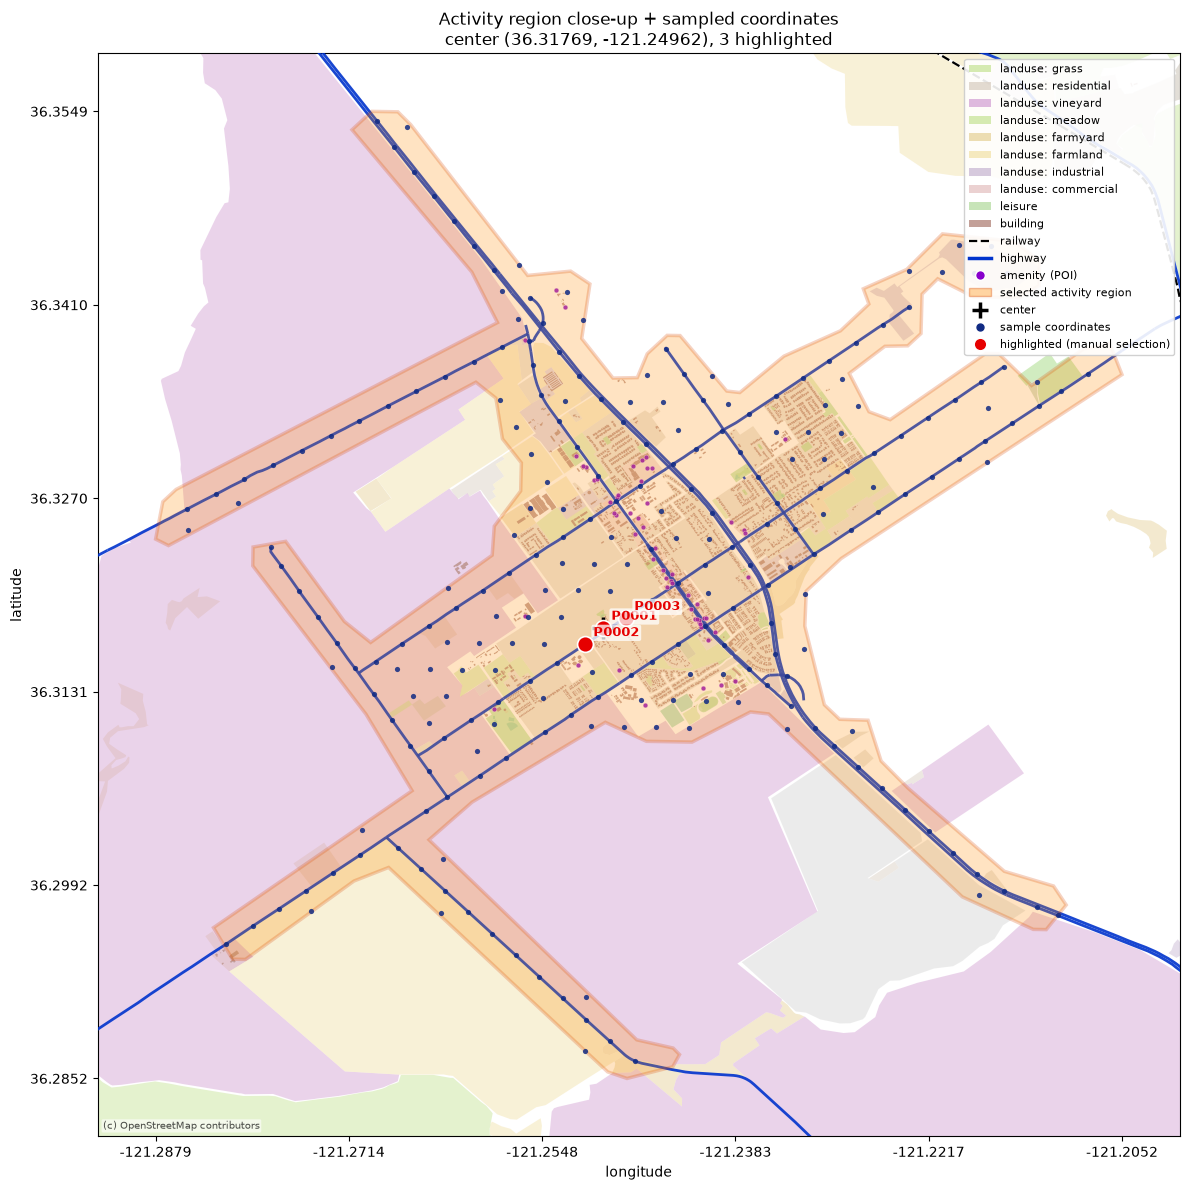

figure written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output/region_closeup_highlighted.png
highlighted points (sorted by distance to center):
point_id  latitude   longitude    source  distance_to_center_m  circle_radius_m
   P0001 36.317690 -121.249620    center              0.000000             10.0
   P0002 36.316512 -121.251161   highway            190.332324             10.0
   P0003 36.318388 -121.247654 area_grid            192.748628             10.0


In [8]:
"""
Region close-up with manually highlighted sample points (step 3 of 3).

Consumes `cluster_result`, `coordinate_df` and `plot_region_map` from the
previous cells: crops the map view to the selected activity region only,
draws every sampled coordinate, and highlights the points listed in
HIGHLIGHT_POINT_IDS. Edit that list, then re-run this cell.
No network requests, no tile basemap.
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np


# ============================================================================
# Manual selection — EDIT THIS LIST, then re-run the cell.
# Point ids come from `coordinate_df` / sample_coordinates.csv (P0001 is
# the point closest to the center).
# ============================================================================

HIGHLIGHT_POINT_IDS = [
    "P0001",
    "P0002",
    "P0003",
]

# Close-up view / styling configuration.
VIEW_MARGIN_FRAC = 0.06          # margin around the region bounds
BASE_POINT_COLOR = "#102a83"     # non-highlighted sample points
HIGHLIGHT_COLOR = "#e60000"      # highlighted sample points
LABEL_HIGHLIGHTED = True         # write the point id next to each highlight


def plot_region_closeup(
    coordinate_df,
    highlight_ids,
):
    # De-duplicate while preserving order, then validate.
    highlight_ids = list(dict.fromkeys(highlight_ids))
    known_ids = set(coordinate_df["point_id"])
    unknown_ids = [
        point_id
        for point_id in highlight_ids
        if point_id not in known_ids
    ]
    if unknown_ids:
        raise ValueError(
            "unknown point ids: "
            + ", ".join(unknown_ids)
            + f" — valid ids are P0001..P{len(coordinate_df):04d}"
        )

    fig, ax, handles = plot_region_map(
        "Activity region close-up + sampled coordinates\n"
        f"center ({CENTER_LAT}, {CENTER_LON}), "
        f"{len(highlight_ids)} highlighted"
    )

    # ------------------------------------------------------------------
    # Crop the view to the selected region only (plus a small margin).
    # ------------------------------------------------------------------
    region_wgs84 = cluster_result["region_wgs84"]
    min_lon, min_lat, max_lon, max_lat = region_wgs84.bounds

    x_min, y_min = merc(min_lon, min_lat)
    x_max, y_max = merc(max_lon, max_lat)
    margin_x = (x_max - x_min) * VIEW_MARGIN_FRAC
    margin_y = (y_max - y_min) * VIEW_MARGIN_FRAC

    ax.set_xlim(x_min - margin_x, x_max + margin_x)
    ax.set_ylim(y_min - margin_y, y_max + margin_y)

    # Recompute axis ticks for the cropped extent (setup_axes placed them
    # for the full box, most of which is now outside the view).
    lon_ticks = np.linspace(min_lon, max_lon, 6)
    lat_ticks = np.linspace(min_lat, max_lat, 6)
    ax.set_xticks([merc(value, CENTER_LAT)[0] for value in lon_ticks])
    ax.set_xticklabels([f"{value:.4f}" for value in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, value)[1] for value in lat_ticks])
    ax.set_yticklabels([f"{value:.4f}" for value in lat_ticks])

    # ------------------------------------------------------------------
    # All sampled points, then the highlighted subset on top.
    # ------------------------------------------------------------------
    is_highlighted = coordinate_df["point_id"].isin(highlight_ids)
    base_df = coordinate_df[~is_highlighted]
    highlight_df = coordinate_df[is_highlighted]

    if len(base_df):
        base_x, base_y = merc_arr(
            base_df["longitude"].to_numpy(),
            base_df["latitude"].to_numpy(),
        )
        ax.scatter(
            base_x,
            base_y,
            s=14,
            c=BASE_POINT_COLOR,
            marker="o",
            alpha=0.85,
            linewidths=0,
            zorder=5,
        )

    highlight_x, highlight_y = merc_arr(
        highlight_df["longitude"].to_numpy(),
        highlight_df["latitude"].to_numpy(),
    )
    ax.scatter(
        highlight_x,
        highlight_y,
        s=130,
        facecolor=HIGHLIGHT_COLOR,
        edgecolor="white",
        linewidths=1.2,
        marker="o",
        zorder=7,
    )

    if LABEL_HIGHLIGHTED:
        for x, y, point_id in zip(
            highlight_x,
            highlight_y,
            highlight_df["point_id"],
        ):
            ax.annotate(
                point_id,
                (x, y),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold",
                color=HIGHLIGHT_COLOR,
                zorder=8,
                bbox={
                    "boxstyle": "round,pad=0.15",
                    "fc": "white",
                    "ec": "none",
                    "alpha": 0.75,
                },
            )

    handles.append(
        plt.Line2D(
            [], [],
            color=BASE_POINT_COLOR,
            marker="o",
            ls="none",
            ms=5,
            label="sample coordinates",
        )
    )
    handles.append(
        plt.Line2D(
            [], [],
            color=HIGHLIGHT_COLOR,
            marker="o",
            ls="none",
            ms=9,
            mec="white",
            label="highlighted (manual selection)",
        )
    )

    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
    fig.tight_layout()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    figure_path = OUTPUT_DIR / "region_closeup_highlighted.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"figure written to: {figure_path.resolve()}")

    return highlight_df


# ============================================================================
# Run the close-up plot
# ============================================================================

_required = (
    "cluster_result", "coordinate_df", "plot_region_map",
    "CENTER_LAT", "CENTER_LON", "OUTPUT_DIR",
    "merc", "merc_arr",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables: "
        + ", ".join(_missing)
        + " — run the previous cells (OSM map, clustering, sampling) first"
    )

highlighted_df = plot_region_closeup(
    coordinate_df,
    HIGHLIGHT_POINT_IDS,
)

print("highlighted points (sorted by distance to center):")
print(
    highlighted_df.sort_values("distance_to_center_m").to_string(index=False)
)


DEMO coverage file generated: osm_activity_output/coverage_P0001.json
P0001: 28 locations, 4 antennas: ANT_101, ANT_102, ANT_203, ANT_305


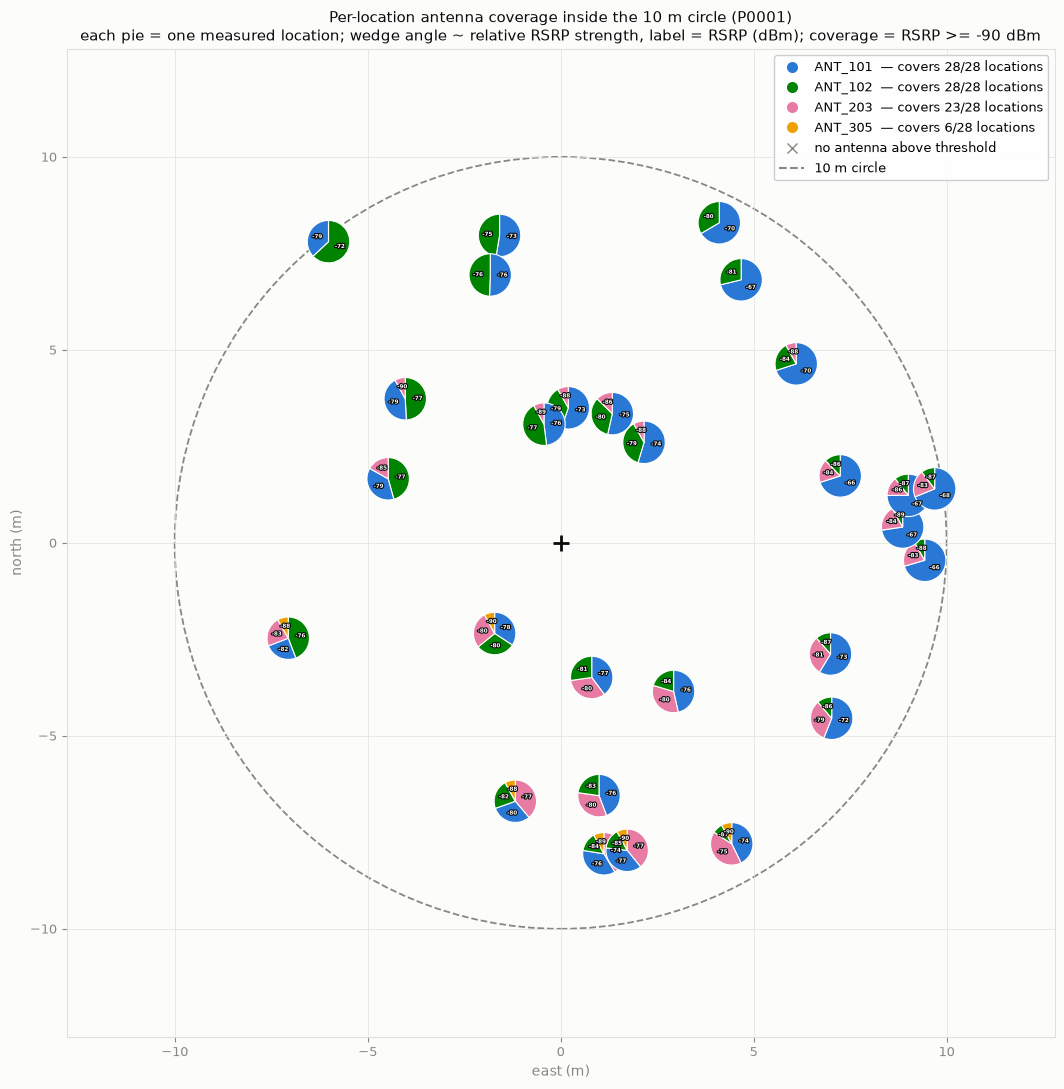

figure written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output/coverage_P0001_pies.png

per-antenna summary:
            locations_covered  serving_count  mean_rsrp  min_rsrp  max_rsrp
antenna_id                                                                 
ANT_101                    28             21      -73.8     -82.1     -65.8
ANT_102                    28              4      -81.7     -88.6     -71.8
ANT_203                    23              3      -82.6     -89.9     -74.0
ANT_305                     6              0      -89.1     -89.9     -87.9


In [9]:
"""
Per-antenna coverage visualization inside one sampled 10 m circle (step 4).

Input: a coverage JSON obtained by querying one sampled point (see
COVERAGE_JSON_PATH). Inside the point's 10 m circle the file contains a
set of (latitude, longitude) measurement locations; each location
reports the serving cell plus top-1..top-5 neighbors, every entry being
an antenna id + RSRP value.

Main view: one pie glyph per measurement location. Each wedge is an
antenna covering that location; the wedge ANGLE is weighted by relative
RSRP strength (stronger antenna -> larger wedge) and the wedge label is
the RSRP in dBm. The legend reports how many locations each antenna
covers. Pie radius adapts to the nearest-neighbor spacing so neighboring
pies do not overlap.

If the JSON file does not exist yet, a synthetic demo file is generated
around the selected point so the whole cell runs end-to-end; replace it
with your real query result and re-run.
"""

from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Circle as MplCircle
from matplotlib.patches import Wedge


# ============================================================================
# Configuration — EDIT THESE, then re-run the cell.
# ============================================================================

# Which sampled point (from coordinate_df / cell 4) the coverage query is for.
COVERAGE_POINT_ID = "P0001"

# Path of the coverage JSON returned by your query for that point.
COVERAGE_JSON_PATH = OUTPUT_DIR / f"coverage_{COVERAGE_POINT_ID}.json"

# Generate a synthetic demo JSON if the file above is missing.
USE_DEMO_IF_MISSING = True

# An antenna "covers" a location if its RSRP >= this threshold (dBm).
# Set to None to count EVERY reported entry (serving/top1..top5).
COVERAGE_THRESHOLD_DBM = -90.0

# Weakest wedge is never drawn thinner than this (degrees), so its RSRP
# label stays readable.
MIN_WEDGE_DEG = 30.0


# ============================================================================
# Palette (validated data-viz defaults; light mode)
# ============================================================================

CATEGORICAL_COLORS = [
    "#2a78d6",  # blue
    "#008300",  # green
    "#e87ba4",  # magenta
    "#eda100",  # yellow
    "#1baf7a",  # aqua
    "#eb6834",  # orange
    "#4a3aa7",  # violet
    "#e34948",  # red
]
OTHER_COLOR = "#898781"

SURFACE_COLOR = "#fcfcfb"
INK_COLOR = "#0b0b0b"
MUTED_COLOR = "#898781"
GRID_COLOR = "#e1e0d9"


# ============================================================================
# Coverage JSON parsing (tolerant to small schema variations)
# ============================================================================

def _first_present(mapping: dict, keys: tuple):
    for key in keys:
        if key in mapping and mapping[key] is not None:
            return mapping[key]
    return None


def _parse_entry(rank: str, entry) -> tuple | None:
    """One serving/top-N entry -> (rank, antenna_id, rsrp) or None."""
    if not isinstance(entry, dict):
        return None
    antenna = _first_present(
        entry,
        ("antenna_id", "antenna", "cell_id", "cell",
         "pci", "beam_id", "beam", "id", "name"),
    )
    rsrp = _first_present(
        entry,
        ("rsrp", "rsrp_dbm", "rsrp_dBm", "value"),
    )
    if antenna is None or rsrp is None:
        return None
    return rank, str(antenna), float(rsrp)


def parse_coverage_json(payload) -> pd.DataFrame:
    """Normalize the coverage JSON into a long DataFrame with columns:
    sample_idx, latitude, longitude, rank, antenna_id, rsrp."""
    if isinstance(payload, list):
        records = payload
    elif isinstance(payload, dict):
        records = None
        for key in ("samples", "points", "measurements",
                    "results", "locations", "data"):
            value = payload.get(key)
            if isinstance(value, list):
                records = value
                break
        if records is None:
            raise ValueError(
                "could not find the measurement list in the JSON; "
                "expected a top-level list or one of the keys "
                "samples/points/measurements/results/locations/data"
            )
    else:
        raise ValueError(f"unsupported JSON top-level type: {type(payload)}")

    rows = []
    for index, record in enumerate(records):
        latitude = _first_present(record, ("latitude", "lat"))
        longitude = _first_present(record, ("longitude", "lon", "lng"))
        if latitude is None or longitude is None:
            continue

        entries = []
        if isinstance(record.get("serving"), dict):
            entries.append(("serving", record["serving"]))
        for rank_index in range(1, 6):
            key = f"top{rank_index}"
            if key in record:
                entries.append((key, record[key]))
        for list_key in ("top", "neighbors", "cells"):
            value = record.get(list_key)
            if isinstance(value, list):
                for rank_index, item in enumerate(value, start=1):
                    entries.append((f"top{rank_index}", item))

        for rank, entry in entries:
            parsed = _parse_entry(rank, entry)
            if parsed is None:
                continue
            rank, antenna_id, rsrp = parsed
            rows.append(
                {
                    "sample_idx": index,
                    "latitude": float(latitude),
                    "longitude": float(longitude),
                    "rank": rank,
                    "antenna_id": antenna_id,
                    "rsrp": rsrp,
                }
            )

    coverage_df = pd.DataFrame(rows)
    if coverage_df.empty:
        raise ValueError(
            "no (antenna, rsrp) entries could be parsed from the JSON — "
            "adjust the key lists in _parse_entry/parse_coverage_json "
            "to match your schema"
        )
    # A location may report the same antenna twice (serving + topN):
    # keep the strongest entry per (location, antenna).
    coverage_df = (
        coverage_df
        .sort_values("rsrp", ascending=False)
        .drop_duplicates(["sample_idx", "antenna_id"])
        .reset_index(drop=True)
    )
    return coverage_df


# ============================================================================
# Demo data (only used when the real query result is not there yet)
# ============================================================================

def make_demo_coverage_json(
    path: Path,
    center_lat: float,
    center_lon: float,
    radius_m: float,
):
    rng = np.random.default_rng(42)
    antennas = {
        "ANT_101": {"base": -76.0, "grad": (0.9, 0.3)},
        "ANT_102": {"base": -80.0, "grad": (-0.8, 0.5)},
        "ANT_203": {"base": -84.0, "grad": (0.1, -1.0)},
        "ANT_305": {"base": -92.0, "grad": (-0.3, -0.4)},
        "ANT_412": {"base": -99.0, "grad": (0.5, -0.6)},
    }

    meters_per_deg_lat = 110_540.0
    meters_per_deg_lon = 111_320.0 * math.cos(math.radians(center_lat))

    samples = []
    for _ in range(28):
        angle = rng.uniform(0.0, 2.0 * math.pi)
        distance = radius_m * math.sqrt(rng.uniform(0.0, 1.0))
        x = distance * math.cos(angle)
        y = distance * math.sin(angle)

        entries = []
        for antenna_id, spec in antennas.items():
            gradient_x, gradient_y = spec["grad"]
            rsrp = (
                spec["base"]
                + gradient_x * x + gradient_y * y
                + rng.normal(0.0, 1.2)
            )
            entries.append((antenna_id, round(rsrp, 1)))

        entries.sort(key=lambda item: item[1], reverse=True)

        sample = {
            "latitude": round(center_lat + y / meters_per_deg_lat, 8),
            "longitude": round(center_lon + x / meters_per_deg_lon, 8),
            "serving": {
                "antenna_id": entries[0][0],
                "rsrp": entries[0][1],
            },
        }
        for rank_index, (antenna_id, rsrp) in enumerate(
            entries[1:6], start=1
        ):
            sample[f"top{rank_index}"] = {
                "antenna_id": antenna_id,
                "rsrp": rsrp,
            }
        samples.append(sample)

    payload = {
        "point_id": COVERAGE_POINT_ID,
        "circle_radius_m": radius_m,
        "samples": samples,
    }
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"DEMO coverage file generated: {path}")


# ============================================================================
# Geometry helpers
# ============================================================================

def to_local_meters(latitudes, longitudes, center_lat, center_lon):
    """WGS84 -> meters relative to the circle center (equirectangular:
    sub-millimeter accurate at 10 m scale)."""
    x = (
        (np.asarray(longitudes, dtype=float) - center_lon)
        * 111_320.0
        * math.cos(math.radians(center_lat))
    )
    y = (
        (np.asarray(latitudes, dtype=float) - center_lat)
        * 110_540.0
    )
    return x, y


def adaptive_pie_radius(x, y, circle_radius_m) -> float:
    """Pick a pie radius from the typical nearest-neighbor spacing.
    Uses the 25th percentile of nearest-neighbor distances (not the
    minimum) so a single pair of nearly coincident locations does not
    shrink every pie on the map."""
    if len(x) < 2:
        return circle_radius_m * 0.1
    points = np.column_stack([x, y])
    deltas = points[:, None, :] - points[None, :, :]
    distances = np.sqrt((deltas ** 2).sum(axis=2))
    np.fill_diagonal(distances, np.inf)
    typical_spacing = float(
        np.percentile(distances.min(axis=1), 25)
    )
    return float(
        np.clip(0.5 * typical_spacing, 0.055 * circle_radius_m,
                0.105 * circle_radius_m)
    )


def wedge_angles(rsrp_values, floor_dbm) -> np.ndarray:
    """RSRP (dBm) -> wedge angles (degrees) summing to 360.
    Angle is proportional to dB above the floor; the weakest wedge is
    kept at >= MIN_WEDGE_DEG so its label stays readable."""
    weights = np.maximum(
        np.asarray(rsrp_values, dtype=float) - floor_dbm, 1.0
    )
    angles = 360.0 * weights / weights.sum()
    if len(angles) > 1 and angles.min() < MIN_WEDGE_DEG:
        angles = np.maximum(angles, MIN_WEDGE_DEG)
        angles *= 360.0 / angles.sum()
    return angles


# ============================================================================
# The coverage pie map
# ============================================================================

def plot_coverage_pies(
    coverage_df, antenna_order, antenna_colors,
    center_lat, center_lon, radius_m, floor_dbm,
):
    locations = (
        coverage_df[["sample_idx", "latitude", "longitude"]]
        .drop_duplicates("sample_idx")
        .set_index("sample_idx")
    )
    loc_x, loc_y = to_local_meters(
        locations["latitude"], locations["longitude"],
        center_lat, center_lon,
    )
    locations["x"] = loc_x
    locations["y"] = loc_y

    pie_radius = adaptive_pie_radius(loc_x, loc_y, radius_m)
    label_fontsize = float(
        np.clip(5.6 * pie_radius / (0.105 * radius_m), 4.0, 7.0)
    )

    fig, ax = plt.subplots(figsize=(11, 11))
    fig.patch.set_facecolor(SURFACE_COLOR)
    ax.set_facecolor(SURFACE_COLOR)
    ax.set_aspect("equal")
    limit = radius_m * 1.28
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

    threshold_text = (
        f"RSRP >= {COVERAGE_THRESHOLD_DBM:.0f} dBm"
        if COVERAGE_THRESHOLD_DBM is not None
        else "all reported entries"
    )
    ax.set_title(
        f"Per-location antenna coverage inside the {radius_m:.0f} m "
        f"circle ({COVERAGE_POINT_ID})\n"
        "each pie = one measured location; wedge angle ~ relative RSRP "
        f"strength, label = RSRP (dBm); coverage = {threshold_text}",
        fontsize=11, color=INK_COLOR,
    )
    ax.tick_params(colors=MUTED_COLOR, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(GRID_COLOR)
    ax.grid(True, color=GRID_COLOR, linewidth=0.6, alpha=0.8)
    ax.add_patch(
        MplCircle(
            (0.0, 0.0), radius_m,
            fill=False, edgecolor=MUTED_COLOR,
            linewidth=1.3, linestyle="--",
        )
    )
    ax.plot([0.0], [0.0], marker="+", ms=12, mew=2.0,
            color=INK_COLOR, zorder=6)
    ax.set_xlabel("east (m)", color=MUTED_COLOR, fontsize=10)
    ax.set_ylabel("north (m)", color=MUTED_COLOR, fontsize=10)

    label_stroke = [
        path_effects.withStroke(linewidth=1.6, foreground=INK_COLOR)
    ]

    for sample_idx, location in locations.iterrows():
        here = (
            coverage_df[coverage_df["sample_idx"] == sample_idx]
            .sort_values("rsrp", ascending=False)
        )
        if here.empty:
            ax.plot(location["x"], location["y"], marker="x",
                    ms=6, color=MUTED_COLOR, zorder=5)
            continue

        angles = wedge_angles(here["rsrp"].to_numpy(), floor_dbm)

        # Strongest antenna starts at 12 o'clock, then clockwise.
        theta_end = 90.0
        for (_, entry), angle in zip(here.iterrows(), angles):
            theta_start = theta_end - angle
            ax.add_patch(
                Wedge(
                    (location["x"], location["y"]),
                    pie_radius,
                    theta_start, theta_end,
                    facecolor=antenna_colors[entry["antenna_id"]],
                    edgecolor="white", linewidth=0.8, zorder=5,
                )
            )
            mid = math.radians((theta_start + theta_end) / 2.0)
            label_r = 0.0 if len(here) == 1 else 0.58 * pie_radius
            ax.annotate(
                f"{entry['rsrp']:.0f}",
                (
                    location["x"] + label_r * math.cos(mid),
                    location["y"] + label_r * math.sin(mid),
                ),
                ha="center", va="center",
                fontsize=label_fontsize, fontweight="bold",
                color="white", zorder=7,
                path_effects=label_stroke,
            )
            theta_end = theta_start

    handles = []
    for antenna_id in antenna_order:
        covered = coverage_df[
            coverage_df["antenna_id"] == antenna_id
        ]["sample_idx"].nunique()
        handles.append(
            Line2D(
                [], [], marker="o", ls="none", ms=9,
                color=antenna_colors[antenna_id], mec="white",
                label=(
                    f"{antenna_id}  — covers "
                    f"{covered}/{len(locations)} locations"
                ),
            )
        )
    handles.append(
        Line2D([], [], marker="x", ls="none", ms=7, color=MUTED_COLOR,
               label="no antenna above threshold")
    )
    handles.append(
        Line2D([], [], color=MUTED_COLOR, ls="--",
               label=f"{radius_m:.0f} m circle")
    )
    ax.legend(handles=handles, loc="upper right", fontsize=9,
              framealpha=0.94)

    fig.tight_layout()
    figure_path = OUTPUT_DIR / (
        f"coverage_{COVERAGE_POINT_ID}_pies.png"
    )
    fig.savefig(figure_path, dpi=180, bbox_inches="tight",
                facecolor=SURFACE_COLOR)
    plt.show()
    print(f"figure written to: {figure_path.resolve()}")


# ============================================================================
# Run
# ============================================================================

_required = ("OUTPUT_DIR", "coordinate_df")
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables: " + ", ".join(_missing)
        + " — run the sampling cell (cell 4) first"
    )

# Circle center = the selected sampled point.
_point_rows = coordinate_df[
    coordinate_df["point_id"] == COVERAGE_POINT_ID
]
if _point_rows.empty:
    raise ValueError(
        f"{COVERAGE_POINT_ID} not found in coordinate_df; valid ids "
        f"are P0001..P{len(coordinate_df):04d}"
    )
_point = _point_rows.iloc[0]
_center_lat = float(_point["latitude"])
_center_lon = float(_point["longitude"])
_radius_m = float(_point.get("circle_radius_m", 10.0))

if not COVERAGE_JSON_PATH.exists():
    if not USE_DEMO_IF_MISSING:
        raise FileNotFoundError(
            f"coverage file not found: {COVERAGE_JSON_PATH}"
        )
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    make_demo_coverage_json(
        COVERAGE_JSON_PATH, _center_lat, _center_lon, _radius_m,
    )

coverage_df = parse_coverage_json(
    json.loads(COVERAGE_JSON_PATH.read_text(encoding="utf-8"))
)

# Apply the coverage criterion; the angle floor is the threshold (or the
# circle-wide minimum minus a small margin when no threshold is set).
if COVERAGE_THRESHOLD_DBM is not None:
    coverage_df = coverage_df[
        coverage_df["rsrp"] >= COVERAGE_THRESHOLD_DBM
    ].reset_index(drop=True)
    _floor_dbm = float(COVERAGE_THRESHOLD_DBM)
else:
    _floor_dbm = float(coverage_df["rsrp"].min()) - 3.0

if coverage_df.empty:
    raise ValueError(
        "no entry passes COVERAGE_THRESHOLD_DBM = "
        f"{COVERAGE_THRESHOLD_DBM} — lower the threshold"
    )

# Fixed antenna order (colors follow it, never re-cycled): coverage
# count desc, then mean RSRP desc.
_coverage_counts = coverage_df.groupby("antenna_id")[
    "sample_idx"
].nunique()
_mean_rsrp = coverage_df.groupby("antenna_id")["rsrp"].mean()
antenna_order = sorted(
    coverage_df["antenna_id"].unique(),
    key=lambda antenna_id: (
        -_coverage_counts.get(antenna_id, 0),
        -_mean_rsrp.get(antenna_id, -np.inf),
    ),
)
antenna_colors = {
    antenna_id: (
        CATEGORICAL_COLORS[position]
        if position < len(CATEGORICAL_COLORS)
        else OTHER_COLOR
    )
    for position, antenna_id in enumerate(antenna_order)
}

print(
    f"{COVERAGE_POINT_ID}: "
    f"{coverage_df['sample_idx'].nunique()} locations, "
    f"{len(antenna_order)} antennas: {', '.join(antenna_order)}"
)

plot_coverage_pies(
    coverage_df, antenna_order, antenna_colors,
    _center_lat, _center_lon, _radius_m, _floor_dbm,
)

# Per-antenna summary table.
_summary = (
    coverage_df
    .groupby("antenna_id")
    .agg(
        locations_covered=("sample_idx", "nunique"),
        serving_count=("rank", lambda s: (s == "serving").sum()),
        mean_rsrp=("rsrp", "mean"),
        min_rsrp=("rsrp", "min"),
        max_rsrp=("rsrp", "max"),
    )
    .reindex(antenna_order)
    .round(1)
)
print("\nper-antenna summary:")
print(_summary.to_string())


aggregated 1 coverage files (247 sampled points without data)


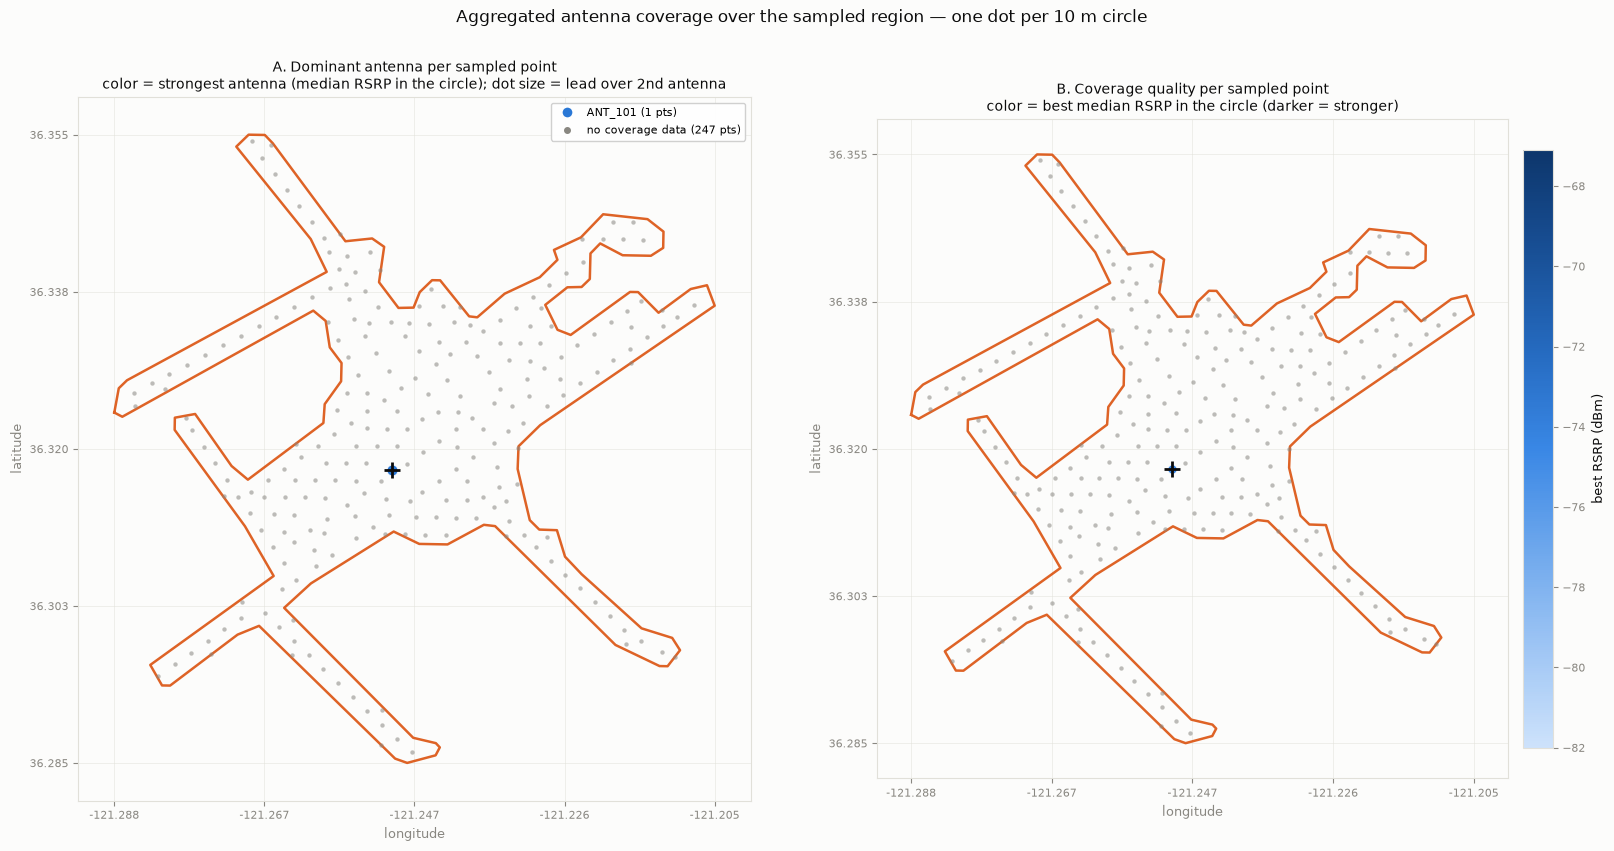

figure written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output/coverage_aggregated_map.png

dominance summary:
          points  mean_best_rsrp  mean_margin_db
dominant                                        
ANT_101        1           -74.6             7.3


In [10]:
"""
Aggregated coverage map over all sampled points (step 5).

Each sampled point's 10 m circle collapses to ONE dot on the region
map. Per circle, every antenna's RSRP measurements are reduced to a
single representative value (AGG_STAT over the locations inside the
circle); the dot then encodes:

  Panel A — dominant antenna: color = antenna with the best aggregated
            RSRP; dot size = its lead over the 2nd antenna (dB), so
            small dots mark contested handover/interference borders.
  Panel B — coverage quality: color depth = best aggregated RSRP (dBm).

Input: one coverage JSON per sampled point, named like
coverage_P0001.json inside OUTPUT_DIR (see COVERAGE_FILE_GLOB); files
are parsed with parse_coverage_json from the previous cell. Points
without a file are drawn as small gray dots. If NO file matches, a
synthetic demo aggregate is generated in memory (no files written) so
the cell runs end-to-end.

Drill-down: pick any point id and use the previous cell's pie map to
inspect the inside of that circle.
"""

from __future__ import annotations

import json
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D


# ============================================================================
# Configuration — EDIT THESE, then re-run the cell.
# ============================================================================

# Per-point coverage files, searched inside OUTPUT_DIR.
COVERAGE_FILE_GLOB = "coverage_P*.json"

# How to reduce one antenna's RSRP samples inside a circle to a single
# value: "median" (robust, default), "mean" or "max".
AGG_STAT = "median"

# Dot area range for panel A; the margin (dB) that maps to the largest dot.
DOT_SIZE_RANGE = (16.0, 90.0)
MARGIN_FULL_SCALE_DB = 12.0

# Build an in-memory synthetic demo if no coverage file is found.
USE_DEMO_IF_NO_FILES = True


# ============================================================================
# Aggregation
# ============================================================================

def aggregate_point_coverage(point_coverage_df: pd.DataFrame) -> dict:
    """Collapse one circle's measurements into one row:
    dominant antenna, its aggregated RSRP, and the lead over the 2nd."""
    per_antenna = (
        point_coverage_df
        .groupby("antenna_id")["rsrp"]
        .agg(AGG_STAT)
        .sort_values(ascending=False)
    )
    dominant_id = per_antenna.index[0]
    best_rsrp = float(per_antenna.iloc[0])
    margin_db = (
        best_rsrp - float(per_antenna.iloc[1])
        if len(per_antenna) > 1
        else MARGIN_FULL_SCALE_DB
    )
    return {
        "dominant": dominant_id,
        "best_rsrp": best_rsrp,
        "margin_db": margin_db,
        "n_antennas": int(len(per_antenna)),
    }


def load_aggregates_from_files() -> pd.DataFrame:
    """Scan OUTPUT_DIR for per-point coverage files and aggregate each."""
    known_ids = set(coordinate_df["point_id"])
    rows = []
    for path in sorted(OUTPUT_DIR.glob(COVERAGE_FILE_GLOB)):
        match = re.search(r"(P\d{4})", path.name)
        if match is None or match.group(1) not in known_ids:
            print(f"skipping {path.name}: no known point id in the name")
            continue
        point_id = match.group(1)
        try:
            point_coverage_df = parse_coverage_json(
                json.loads(path.read_text(encoding="utf-8"))
            )
        except ValueError as error:
            print(f"skipping {path.name}: {error}")
            continue
        rows.append(
            {"point_id": point_id,
             **aggregate_point_coverage(point_coverage_df)}
        )
    return pd.DataFrame(rows)


def make_demo_aggregates() -> pd.DataFrame:
    """Synthetic per-point aggregates for every sampled point: a few
    virtual towers with log-distance path loss (demo only)."""
    rng = np.random.default_rng(11)
    center_lat = float(coordinate_df["latitude"].mean())
    center_lon = float(coordinate_df["longitude"].mean())
    x, y = to_local_meters(
        coordinate_df["latitude"], coordinate_df["longitude"],
        center_lat, center_lon,
    )
    span = max(float(np.ptp(x)), float(np.ptp(y)), 500.0)
    towers = {
        "ANT_101": (0.45 * span, 0.25 * span, -70.0),
        "ANT_102": (-0.40 * span, 0.30 * span, -72.0),
        "ANT_203": (0.05 * span, -0.45 * span, -74.0),
        "ANT_305": (-0.15 * span, 0.05 * span, -80.0),
    }
    rows = []
    for index, point_id in enumerate(coordinate_df["point_id"]):
        per_antenna = {}
        for antenna_id, (tx, ty, base) in towers.items():
            distance = math.hypot(x[index] - tx, y[index] - ty)
            per_antenna[antenna_id] = (
                base
                - 28.0 * math.log10(1.0 + distance / (0.04 * span))
                + rng.normal(0.0, 2.0)
            )
        ranked = sorted(
            per_antenna.items(), key=lambda item: item[1], reverse=True
        )
        rows.append(
            {
                "point_id": point_id,
                "dominant": ranked[0][0],
                "best_rsrp": ranked[0][1],
                "margin_db": ranked[0][1] - ranked[1][1],
                "n_antennas": len(ranked),
            }
        )
    return pd.DataFrame(rows)


# ============================================================================
# Plotting
# ============================================================================

def style_region_axes(ax, title):
    region_wgs84 = cluster_result["region_wgs84"]
    min_lon, min_lat, max_lon, max_lat = region_wgs84.bounds

    ax.set_facecolor(SURFACE_COLOR)
    ax.set_aspect("equal")

    x_min, y_min = merc(min_lon, min_lat)
    x_max, y_max = merc(max_lon, max_lat)
    margin_x = (x_max - x_min) * 0.06
    margin_y = (y_max - y_min) * 0.06
    ax.set_xlim(x_min - margin_x, x_max + margin_x)
    ax.set_ylim(y_min - margin_y, y_max + margin_y)

    lon_ticks = np.linspace(min_lon, max_lon, 5)
    lat_ticks = np.linspace(min_lat, max_lat, 5)
    ax.set_xticks([merc(value, CENTER_LAT)[0] for value in lon_ticks])
    ax.set_xticklabels([f"{value:.3f}" for value in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, value)[1] for value in lat_ticks])
    ax.set_yticklabels([f"{value:.3f}" for value in lat_ticks])
    ax.tick_params(colors=MUTED_COLOR, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(GRID_COLOR)
    ax.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
    ax.set_title(title, fontsize=10, color=INK_COLOR)
    ax.set_xlabel("longitude", color=MUTED_COLOR, fontsize=9)
    ax.set_ylabel("latitude", color=MUTED_COLOR, fontsize=9)

    # Region outline + center.
    boundary = np.asarray(region_wgs84.exterior.coords)
    boundary_x, boundary_y = merc_arr(boundary[:, 0], boundary[:, 1])
    ax.plot(boundary_x, boundary_y, color="#d94801", linewidth=1.8,
            alpha=0.85, zorder=3)
    center_x, center_y = merc(CENTER_LON, CENTER_LAT)
    ax.plot([center_x], [center_y], marker="+", ms=12, mew=2.0,
            color=INK_COLOR, zorder=6)


def plot_aggregated_maps(aggregate_map_df: pd.DataFrame):
    merged = coordinate_df.merge(aggregate_map_df, on="point_id",
                                 how="left")
    point_x, point_y = merc_arr(
        merged["longitude"].to_numpy(),
        merged["latitude"].to_numpy(),
    )
    has_data = merged["dominant"].notna()

    dominance_counts = (
        merged.loc[has_data, "dominant"].value_counts()
    )
    antenna_order = list(dominance_counts.index)
    antenna_colors = {
        antenna_id: (
            CATEGORICAL_COLORS[position]
            if position < len(CATEGORICAL_COLORS)
            else OTHER_COLOR
        )
        for position, antenna_id in enumerate(antenna_order)
    }

    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(17, 8.5))
    fig.patch.set_facecolor(SURFACE_COLOR)

    # ---------------- Panel A: dominant antenna ----------------
    style_region_axes(
        ax_a,
        "A. Dominant antenna per sampled point\n"
        f"color = strongest antenna ({AGG_STAT} RSRP in the circle); "
        "dot size = lead over 2nd antenna",
    )
    size_min, size_max = DOT_SIZE_RANGE
    sizes = size_min + (size_max - size_min) * np.clip(
        merged["margin_db"].fillna(0.0) / MARGIN_FULL_SCALE_DB, 0.0, 1.0
    )
    if (~has_data).any():
        ax_a.scatter(point_x[~has_data], point_y[~has_data], s=10,
                     c=MUTED_COLOR, alpha=0.55, linewidths=0, zorder=4)
    for antenna_id in antenna_order:
        mask = (merged["dominant"] == antenna_id).to_numpy()
        ax_a.scatter(point_x[mask], point_y[mask],
                     s=sizes[mask], c=antenna_colors[antenna_id],
                     edgecolors="white", linewidths=0.5, zorder=5)

    handles = [
        Line2D([], [], marker="o", ls="none", ms=8,
               color=antenna_colors[antenna_id], mec="white",
               label=f"{antenna_id} ({dominance_counts[antenna_id]} pts)")
        for antenna_id in antenna_order
    ]
    if (~has_data).any():
        handles.append(
            Line2D([], [], marker="o", ls="none", ms=4,
                   color=MUTED_COLOR,
                   label=f"no coverage data ({int((~has_data).sum())} pts)")
        )
    ax_a.legend(handles=handles, loc="upper right", fontsize=8,
                framealpha=0.92)

    # ---------------- Panel B: coverage quality ----------------
    style_region_axes(
        ax_b,
        "B. Coverage quality per sampled point\n"
        f"color = best {AGG_STAT} RSRP in the circle (darker = stronger)",
    )
    if (~has_data).any():
        ax_b.scatter(point_x[~has_data], point_y[~has_data], s=10,
                     c=MUTED_COLOR, alpha=0.55, linewidths=0, zorder=4)
    scatter = ax_b.scatter(
        point_x[has_data], point_y[has_data], s=42,
        c=merged.loc[has_data, "best_rsrp"], cmap=RSRP_CMAP,
        edgecolors="white", linewidths=0.4, zorder=5,
    )
    colorbar = fig.colorbar(scatter, ax=ax_b, shrink=0.85, pad=0.02)
    colorbar.set_label("best RSRP (dBm)", color=INK_COLOR, fontsize=9)
    colorbar.ax.tick_params(colors=MUTED_COLOR, labelsize=8)
    colorbar.outline.set_edgecolor(GRID_COLOR)

    fig.suptitle(
        "Aggregated antenna coverage over the sampled region — "
        "one dot per 10 m circle",
        fontsize=12, color=INK_COLOR,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    figure_path = OUTPUT_DIR / "coverage_aggregated_map.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight",
                facecolor=SURFACE_COLOR)
    plt.show()
    print(f"figure written to: {figure_path.resolve()}")


# ============================================================================
# Run
# ============================================================================

_required = (
    "coordinate_df", "OUTPUT_DIR", "cluster_result",
    "CENTER_LAT", "CENTER_LON", "merc", "merc_arr",
    "parse_coverage_json", "to_local_meters",
    "CATEGORICAL_COLORS", "OTHER_COLOR", "SURFACE_COLOR",
    "INK_COLOR", "MUTED_COLOR", "GRID_COLOR",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables: " + ", ".join(_missing)
        + " — run the previous cells (map, clustering, sampling, "
        "coverage pie) first"
    )

from matplotlib.colors import LinearSegmentedColormap as _LSC

RSRP_CMAP = _LSC.from_list(
    "rsrp_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
     "#256abf", "#184f95", "#0d366b"],
)

aggregate_map_df = load_aggregates_from_files()

if aggregate_map_df.empty:
    if not USE_DEMO_IF_NO_FILES:
        raise FileNotFoundError(
            f"no file matching {COVERAGE_FILE_GLOB} in {OUTPUT_DIR}"
        )
    print(
        "DEMO MODE: no coverage files found — synthetic aggregates "
        "for every sampled point (nothing written to disk)"
    )
    aggregate_map_df = make_demo_aggregates()
else:
    print(
        f"aggregated {len(aggregate_map_df)} coverage files "
        f"({len(coordinate_df) - len(aggregate_map_df)} sampled points "
        "without data)"
    )

plot_aggregated_maps(aggregate_map_df)

print("\ndominance summary:")
print(
    aggregate_map_df
    .groupby("dominant")
    .agg(
        points=("point_id", "count"),
        mean_best_rsrp=("best_rsrp", "mean"),
        mean_margin_db=("margin_db", "mean"),
    )
    .sort_values("points", ascending=False)
    .round(1)
    .to_string()
)


loaded covering sets for 1 points


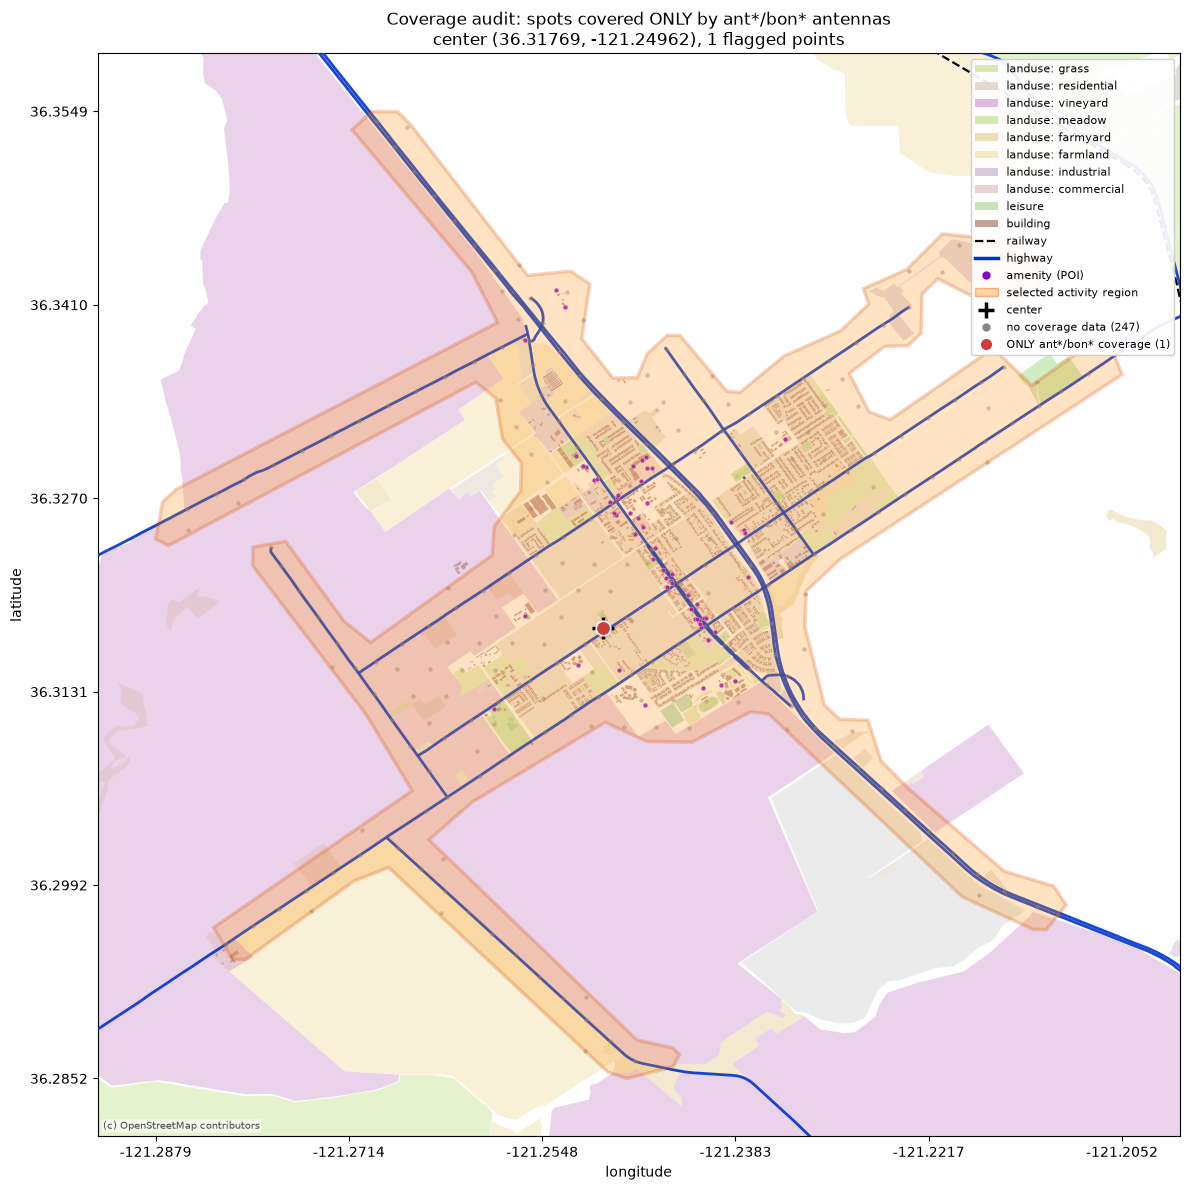

figure written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output/excluded_coverage_audit.png

category counts:
status
no_data          247
only_excluded      1

1 spot(s) covered ONLY by ant/bon antennas:
point_id  latitude  longitude                           covering_antennas
   P0001  36.31769 -121.24962 ANT_101, ANT_102, ANT_203, ANT_305, ANT_412


In [11]:
"""
Excluded-prefix coverage audit on the region close-up (step 6).

Question this cell answers: if we EXCLUDE every antenna whose id starts
with one of EXCLUDED_ANTENNA_PREFIXES, which sampled points are left
with no coverage at all? Those spots — covered ONLY by the excluded
antenna families — are highlighted in red on the zoomed-in region map
(same view as the close-up cell).

The prefixes are placeholders ("ant"/"bon" for the synthetic demo);
when moving to the real system, edit EXCLUDED_ANTENNA_PREFIXES only.

Input: the per-point coverage files (coverage_P*.json in OUTPUT_DIR,
same as the aggregation cell). Points without a file are drawn gray.
If no file matches, an in-memory synthetic demo is generated so the
cell runs end-to-end.
"""

from __future__ import annotations

import json
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D


# ============================================================================
# Configuration — EDIT THESE, then re-run the cell.
# ============================================================================

# Antenna-id prefixes to exclude (case-insensitive). Placeholder values;
# swap these two strings when moving to the real system.
EXCLUDED_ANTENNA_PREFIXES = ("ant", "bon")

# Per-point coverage files, searched inside OUTPUT_DIR.
AUDIT_FILE_GLOB = "coverage_P*.json"

# Coverage = the antenna appears among the reported entries
# (serving/top1..top5) anywhere inside the circle. Optionally require
# RSRP >= this threshold on top of that; None = pure presence.
AUDIT_THRESHOLD_DBM = None

# Build an in-memory synthetic demo if no coverage file is found.
USE_DEMO_IF_NO_FILES = True

# Category colors. Red is the reserved alert color for the flagged
# spots; blue/yellow/green count the NON-excluded stations that also
# cover the point; gray marks points the excluded prefixes do not
# reach at all.
FLAG_COLOR = "#d03b3b"         # only ant*/bon* coverage
ONE_OTHER_COLOR = "#2a78d6"    # excluded + exactly 1 other station
TWO_OTHER_COLOR = "#eda100"    # excluded + 2 or more other stations
NO_EXCLUDED_COLOR = "#898781"  # excluded prefixes absent at this point
FLAG_SIZE = 110.0


# ============================================================================
# Coverage loading -> covering-antenna set per point
# ============================================================================

def _is_excluded(antenna_id: str) -> bool:
    return antenna_id.lower().startswith(
        tuple(prefix.lower() for prefix in EXCLUDED_ANTENNA_PREFIXES)
    )


def covering_set(point_coverage_df: pd.DataFrame) -> set:
    """Antennas covering the circle (RSRP filter applied)."""
    if AUDIT_THRESHOLD_DBM is not None:
        point_coverage_df = point_coverage_df[
            point_coverage_df["rsrp"] >= AUDIT_THRESHOLD_DBM
        ]
    return set(point_coverage_df["antenna_id"])


def load_covering_sets_from_files() -> dict:
    known_ids = set(coordinate_df["point_id"])
    covering = {}
    for path in sorted(OUTPUT_DIR.glob(AUDIT_FILE_GLOB)):
        match = re.search(r"(P\d{4})", path.name)
        if match is None or match.group(1) not in known_ids:
            continue
        try:
            point_coverage_df = parse_coverage_json(
                json.loads(path.read_text(encoding="utf-8"))
            )
        except ValueError as error:
            print(f"skipping {path.name}: {error}")
            continue
        covering[match.group(1)] = covering_set(point_coverage_df)
    return covering


def make_demo_covering_sets() -> dict:
    """Synthetic demo: four towers, two with excluded prefixes (ANT/BON)
    and two with other prefixes (CEL/XTR) that only reach the northern
    part of the region — so the south ends up ant/bon-only."""
    rng = np.random.default_rng(23)
    center_lat = float(coordinate_df["latitude"].mean())
    center_lon = float(coordinate_df["longitude"].mean())
    x, y = to_local_meters(
        coordinate_df["latitude"], coordinate_df["longitude"],
        center_lat, center_lon,
    )
    span = max(float(np.ptp(x)), float(np.ptp(y)), 500.0)
    towers = {
        "ANT_101": (0.30 * span, -0.35 * span, -64.0),
        "BON_201": (-0.30 * span, -0.35 * span, -64.0),
        "CEL_301": (0.00 * span, 0.25 * span, -66.0),
        "XTR_401": (0.15 * span, 0.50 * span, -70.0),
    }
    # The demo needs a finite reach even in pure-presence mode
    # (a real query only reports the strongest few antennas).
    threshold = (
        AUDIT_THRESHOLD_DBM
        if AUDIT_THRESHOLD_DBM is not None
        else -90.0
    )
    covering = {}
    for index, point_id in enumerate(coordinate_df["point_id"]):
        antennas = set()
        for antenna_id, (tx, ty, base) in towers.items():
            distance = math.hypot(x[index] - tx, y[index] - ty)
            rsrp = (
                base
                - 22.0 * math.log10(1.0 + distance / (0.06 * span))
                + rng.normal(0.0, 1.5)
            )
            if rsrp >= threshold:
                antennas.add(antenna_id)
        covering[point_id] = antennas
    return covering


# ============================================================================
# Classification
# ============================================================================

def classify_points(covering: dict) -> pd.DataFrame:
    rows = []
    for point_id in coordinate_df["point_id"]:
        if point_id not in covering:
            status = "no_data"
            antennas = set()
        else:
            antennas = covering[point_id]
            excluded = {
                antenna_id
                for antenna_id in antennas
                if _is_excluded(antenna_id)
            }
            others = antennas - excluded
            if not excluded:
                status = "no_excluded"    # gray: ant*/bon* absent here
            elif len(others) == 0:
                status = "only_excluded"  # red flag
            elif len(others) == 1:
                status = "one_other"      # blue
            else:
                status = "two_other"      # yellow: 2+ other stations
        rows.append(
            {
                "point_id": point_id,
                "status": status,
                "covering_antennas": ", ".join(sorted(antennas)),
            }
        )
    return coordinate_df[["point_id", "latitude", "longitude"]].merge(
        pd.DataFrame(rows), on="point_id"
    )


# ============================================================================
# Plot on the zoomed-in region map
# ============================================================================

def plot_exclusion_audit(audit_df: pd.DataFrame):
    prefix_text = "/".join(
        f"{prefix}*" for prefix in EXCLUDED_ANTENNA_PREFIXES
    )
    n_flagged = int((audit_df["status"] == "only_excluded").sum())

    fig, ax, handles = plot_region_map(
        f"Coverage audit: spots covered ONLY by {prefix_text} antennas\n"
        f"center ({CENTER_LAT}, {CENTER_LON}), "
        f"{n_flagged} flagged points"
    )

    # Crop to the region bounds (same view as the close-up cell).
    region_wgs84 = cluster_result["region_wgs84"]
    min_lon, min_lat, max_lon, max_lat = region_wgs84.bounds
    x_min, y_min = merc(min_lon, min_lat)
    x_max, y_max = merc(max_lon, max_lat)
    margin_x = (x_max - x_min) * 0.06
    margin_y = (y_max - y_min) * 0.06
    ax.set_xlim(x_min - margin_x, x_max + margin_x)
    ax.set_ylim(y_min - margin_y, y_max + margin_y)

    lon_ticks = np.linspace(min_lon, max_lon, 6)
    lat_ticks = np.linspace(min_lat, max_lat, 6)
    ax.set_xticks([merc(value, CENTER_LAT)[0] for value in lon_ticks])
    ax.set_xticklabels([f"{value:.4f}" for value in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, value)[1] for value in lat_ticks])
    ax.set_yticklabels([f"{value:.4f}" for value in lat_ticks])

    point_x, point_y = merc_arr(
        audit_df["longitude"].to_numpy(),
        audit_df["latitude"].to_numpy(),
    )
    status = audit_df["status"]

    groups = (
        ("no_data", dict(s=10, c=MUTED_COLOR, alpha=0.45,
                         linewidths=0, zorder=4),
         "no coverage data"),
        ("no_excluded", dict(s=32, c=NO_EXCLUDED_COLOR, alpha=0.9,
                             linewidths=0, zorder=5),
         f"no {prefix_text} coverage here"),
        ("one_other", dict(s=36, c=ONE_OTHER_COLOR, alpha=0.9,
                           linewidths=0, zorder=5),
         f"{prefix_text} + 1 other station"),
        ("two_other", dict(s=36, c=TWO_OTHER_COLOR, alpha=0.9,
                           linewidths=0, zorder=5),
         f"{prefix_text} + 2+ other stations"),
        ("only_excluded", dict(s=FLAG_SIZE, c=FLAG_COLOR, marker="o",
                               edgecolors="white", linewidths=1.2,
                               zorder=7),
         f"ONLY {prefix_text} coverage"),
    )
    for key, style, label in groups:
        mask = (status == key).to_numpy()
        if not mask.any():
            continue
        ax.scatter(point_x[mask], point_y[mask], **style)
        marker = style.get("marker", "o")
        handles.append(
            Line2D(
                [], [], marker=marker, ls="none",
                ms=9 if key == "only_excluded" else 5,
                color=style["c"],
                mec="white" if key == "only_excluded" else style["c"],
                label=f"{label} ({int(mask.sum())})",
            )
        )

    ax.legend(handles=handles, loc="upper right", fontsize=8,
              framealpha=0.92)
    fig.tight_layout()

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    figure_path = OUTPUT_DIR / "excluded_coverage_audit.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"figure written to: {figure_path.resolve()}")


# ============================================================================
# Run
# ============================================================================

_required = (
    "coordinate_df", "OUTPUT_DIR", "cluster_result", "plot_region_map",
    "CENTER_LAT", "CENTER_LON", "merc", "merc_arr",
    "parse_coverage_json", "to_local_meters", "MUTED_COLOR",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables: " + ", ".join(_missing)
        + " — run the previous cells (map, clustering, sampling, "
        "coverage pie) first"
    )

_covering_sets = load_covering_sets_from_files()

if not _covering_sets:
    if not USE_DEMO_IF_NO_FILES:
        raise FileNotFoundError(
            f"no file matching {AUDIT_FILE_GLOB} in {OUTPUT_DIR}"
        )
    print(
        "DEMO MODE: no coverage files found — synthetic covering sets "
        "for every sampled point (nothing written to disk)"
    )
    _covering_sets = make_demo_covering_sets()
else:
    print(f"loaded covering sets for {len(_covering_sets)} points")

audit_df = classify_points(_covering_sets)
plot_exclusion_audit(audit_df)

print("\ncategory counts:")
print(audit_df["status"].value_counts().to_string())

_flagged = audit_df[audit_df["status"] == "only_excluded"]
print(
    f"\n{len(_flagged)} spot(s) covered ONLY by "
    + "/".join(EXCLUDED_ANTENNA_PREFIXES)
    + " antennas:"
)
if len(_flagged):
    print(
        _flagged[["point_id", "latitude", "longitude",
                  "covering_antennas"]]
        .to_string(index=False)
    )


In [1]:
"""
Per-cell RSRP coverage maps over the sampled region (step 7).

Companion to the audit cell (which stays as figure 1 / the coverage-hole
view): this cell draws one map PER CELL found in the coverage data.
On each map every sampled point is shaded by that cell's aggregated
RSRP inside the point's 10 m circle (darker = stronger); points the
cell does not cover are tiny gray dots. All maps share one color scale,
so panels are directly comparable.

Data source: the SAME per-point files the audit cell reads
(coverage_P*.json in OUTPUT_DIR). If none exist, the demo fallback
reproduces the audit cell's synthetic tower model verbatim (same
towers, same seed), so the demo panels are consistent with the demo
audit map. The demo code never runs once real files are present.
"""

from __future__ import annotations

import json
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap


# ============================================================================
# Configuration — EDIT THESE, then re-run the cell.
# ============================================================================

# Same files as the audit cell.
PERCELL_FILE_GLOB = "coverage_P*.json"

# How to reduce one cell's RSRP samples inside a circle to one value.
PERCELL_AGG_STAT = "median"

# Which cells to draw: None = every cell found in the data, or a list
# of ids, e.g. ["ANT_101", "CEL_301"].
PERCELL_IDS = None

# Layout.
MAPS_PER_ROW = 3


# ============================================================================
# Load per-point, per-cell RSRP
# ============================================================================

def load_point_cell_rsrp() -> pd.DataFrame:
    """Long table: point_id, antenna_id, rsrp (aggregated per circle)."""
    known_ids = set(coordinate_df["point_id"])
    rows = []
    for path in sorted(OUTPUT_DIR.glob(PERCELL_FILE_GLOB)):
        match = re.search(r"(P\d{4})", path.name)
        if match is None or match.group(1) not in known_ids:
            continue
        try:
            point_coverage_df = parse_coverage_json(
                json.loads(path.read_text(encoding="utf-8"))
            )
        except ValueError as error:
            print(f"skipping {path.name}: {error}")
            continue
        per_cell = (
            point_coverage_df
            .groupby("antenna_id")["rsrp"]
            .agg(PERCELL_AGG_STAT)
        )
        for antenna_id, rsrp in per_cell.items():
            rows.append(
                {
                    "point_id": match.group(1),
                    "antenna_id": antenna_id,
                    "rsrp": float(rsrp),
                }
            )
    return pd.DataFrame(rows)


def demo_point_cell_rsrp() -> pd.DataFrame:
    """Demo fallback ONLY: reproduces the audit cell's synthetic tower
    model verbatim (same towers, same seed, same -90 dBm reach), so the
    demo panels match the demo audit map. Never used with real files."""
    rng = np.random.default_rng(23)
    center_lat = float(coordinate_df["latitude"].mean())
    center_lon = float(coordinate_df["longitude"].mean())
    x, y = to_local_meters(
        coordinate_df["latitude"], coordinate_df["longitude"],
        center_lat, center_lon,
    )
    span = max(float(np.ptp(x)), float(np.ptp(y)), 500.0)
    towers = {
        "ANT_101": (0.30 * span, -0.35 * span, -64.0),
        "BON_201": (-0.30 * span, -0.35 * span, -64.0),
        "CEL_301": (0.00 * span, 0.25 * span, -66.0),
        "XTR_401": (0.15 * span, 0.50 * span, -70.0),
    }
    rows = []
    for index, point_id in enumerate(coordinate_df["point_id"]):
        for antenna_id, (tx, ty, base) in towers.items():
            distance = math.hypot(x[index] - tx, y[index] - ty)
            rsrp = (
                base
                - 22.0 * math.log10(1.0 + distance / (0.06 * span))
                + rng.normal(0.0, 1.5)
            )
            if rsrp >= -90.0:
                rows.append(
                    {
                        "point_id": point_id,
                        "antenna_id": antenna_id,
                        "rsrp": rsrp,
                    }
                )
    return pd.DataFrame(rows)


# ============================================================================
# Plot: one RSRP map per cell, shared color scale
# ============================================================================

def plot_per_cell_maps(rsrp_long_df: pd.DataFrame):
    cell_ids = (
        list(PERCELL_IDS)
        if PERCELL_IDS
        else sorted(rsrp_long_df["antenna_id"].unique())
    )
    missing = [
        cell_id for cell_id in cell_ids
        if cell_id not in set(rsrp_long_df["antenna_id"])
    ]
    if missing:
        raise ValueError(
            "cell id(s) not present in the coverage data: "
            + ", ".join(missing)
        )

    rsrp_cmap = LinearSegmentedColormap.from_list(
        "rsrp_blue",
        ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
         "#256abf", "#184f95", "#0d366b"],
    )
    norm = plt.Normalize(
        vmin=float(rsrp_long_df["rsrp"].min()),
        vmax=float(rsrp_long_df["rsrp"].max()),
    )

    # Region view bounds (same crop as the audit cell).
    region_wgs84 = cluster_result["region_wgs84"]
    min_lon, min_lat, max_lon, max_lat = region_wgs84.bounds
    x_min, y_min = merc(min_lon, min_lat)
    x_max, y_max = merc(max_lon, max_lat)
    margin_x = (x_max - x_min) * 0.06
    margin_y = (y_max - y_min) * 0.06
    boundary = np.asarray(region_wgs84.exterior.coords)
    boundary_x, boundary_y = merc_arr(boundary[:, 0], boundary[:, 1])

    point_x, point_y = merc_arr(
        coordinate_df["longitude"].to_numpy(),
        coordinate_df["latitude"].to_numpy(),
    )
    point_index = {
        point_id: position
        for position, point_id in enumerate(coordinate_df["point_id"])
    }

    n_cells = len(cell_ids)
    n_cols = min(MAPS_PER_ROW, n_cells)
    n_rows = math.ceil(n_cells / n_cols)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.6 * n_cols, 5.9 * n_rows),
        squeeze=False,
    )
    fig.patch.set_facecolor(SURFACE_COLOR)

    lon_ticks = np.linspace(min_lon, max_lon, 4)
    lat_ticks = np.linspace(min_lat, max_lat, 4)

    scatter = None
    for panel_index, cell_id in enumerate(cell_ids):
        ax = axes[panel_index // n_cols][panel_index % n_cols]
        ax.set_facecolor(SURFACE_COLOR)
        ax.set_aspect("equal")
        ax.set_xlim(x_min - margin_x, x_max + margin_x)
        ax.set_ylim(y_min - margin_y, y_max + margin_y)
        ax.set_xticks([merc(v, CENTER_LAT)[0] for v in lon_ticks])
        ax.set_yticks([merc(CENTER_LON, v)[1] for v in lat_ticks])
        if panel_index // n_cols == n_rows - 1:
            ax.set_xticklabels([f"{v:.3f}" for v in lon_ticks])
        else:
            ax.set_xticklabels([])
        if panel_index % n_cols == 0:
            ax.set_yticklabels([f"{v:.4f}" for v in lat_ticks])
        else:
            ax.set_yticklabels([])
        ax.tick_params(colors=MUTED_COLOR, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(GRID_COLOR)
        ax.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        ax.plot(boundary_x, boundary_y, color="#d94801",
                linewidth=1.6, alpha=0.85, zorder=3)

        cell_rows = rsrp_long_df[
            rsrp_long_df["antenna_id"] == cell_id
        ]
        covered_positions = [
            point_index[point_id]
            for point_id in cell_rows["point_id"]
            if point_id in point_index
        ]
        covered_mask = np.zeros(len(coordinate_df), dtype=bool)
        covered_mask[covered_positions] = True

        ax.scatter(
            point_x[~covered_mask], point_y[~covered_mask],
            s=8, c=MUTED_COLOR, alpha=0.4, linewidths=0, zorder=4,
        )
        scatter = ax.scatter(
            point_x[covered_positions], point_y[covered_positions],
            s=42, c=cell_rows["rsrp"].to_numpy(),
            cmap=rsrp_cmap, norm=norm,
            edgecolors="white", linewidths=0.4, zorder=5,
        )
        ax.set_title(
            f"{cell_id}\ncovers {int(covered_mask.sum())}"
            f"/{len(coordinate_df)} points, "
            f"mean RSRP {cell_rows['rsrp'].mean():.1f} dBm",
            fontsize=10, color=INK_COLOR,
        )

    for panel_index in range(n_cells, n_rows * n_cols):
        axes[panel_index // n_cols][panel_index % n_cols].set_axis_off()

    colorbar = fig.colorbar(
        scatter, ax=axes, shrink=0.82, pad=0.015,
    )
    colorbar.set_label(
        f"{PERCELL_AGG_STAT} RSRP in the circle (dBm) — "
        "darker = stronger",
        color=INK_COLOR, fontsize=10,
    )
    colorbar.ax.tick_params(colors=MUTED_COLOR, labelsize=8)
    colorbar.outline.set_edgecolor(GRID_COLOR)

    fig.suptitle(
        "Per-cell RSRP coverage over the sampled region — "
        "shared color scale across panels",
        fontsize=13, color=INK_COLOR,
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    figure_path = OUTPUT_DIR / "per_cell_rsrp_maps.png"
    fig.savefig(figure_path, dpi=170, bbox_inches="tight",
                facecolor=SURFACE_COLOR)
    plt.show()
    print(f"figure written to: {figure_path.resolve()}")


# ============================================================================
# Run
# ============================================================================

_required = (
    "coordinate_df", "OUTPUT_DIR", "cluster_result",
    "CENTER_LAT", "CENTER_LON", "merc", "merc_arr",
    "parse_coverage_json", "to_local_meters",
    "SURFACE_COLOR", "INK_COLOR", "MUTED_COLOR", "GRID_COLOR",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables: " + ", ".join(_missing)
        + " — run the previous cells (map, clustering, sampling, "
        "coverage pie) first"
    )

point_cell_rsrp_df = load_point_cell_rsrp()

if point_cell_rsrp_df.empty:
    print(
        "DEMO MODE: no coverage files found — reusing the audit cell's "
        "synthetic tower model (nothing written to disk)"
    )
    point_cell_rsrp_df = demo_point_cell_rsrp()
else:
    print(
        f"loaded RSRP for "
        f"{point_cell_rsrp_df['point_id'].nunique()} points x "
        f"{point_cell_rsrp_df['antenna_id'].nunique()} cells"
    )

plot_per_cell_maps(point_cell_rsrp_df)

print("\nper-cell summary:")
print(
    point_cell_rsrp_df
    .groupby("antenna_id")
    .agg(
        points_covered=("point_id", "nunique"),
        mean_rsrp=("rsrp", "mean"),
        min_rsrp=("rsrp", "min"),
        max_rsrp=("rsrp", "max"),
    )
    .sort_values("points_covered", ascending=False)
    .round(1)
    .to_string()
)


RuntimeError: missing variables: coordinate_df, OUTPUT_DIR, cluster_result, CENTER_LAT, CENTER_LON, merc, merc_arr, parse_coverage_json, to_local_meters, SURFACE_COLOR, INK_COLOR, MUTED_COLOR, GRID_COLOR — run the previous cells (map, clustering, sampling, coverage pie) first

R1 (north-west): ~10.1 km2 region, ~3.15 km2 residential landuse, 2356 buildings, ~4.5 x 5.0 km, 14.0 km NW of the center
R2 (south-east): ~11.9 km2 region, ~2.69 km2 residential landuse, 3902 buildings, ~5.0 x 5.2 km, 15.8 km SE of the center
(the central residential cluster reproduces the already-selected activity region (drawn in orange) and is not re-numbered)
(seed near (36.1845, -121.1493) merged into region R2)
(R3 (south-west, ~0.59 km2 residential) dropped: keeping only the 2 largest)
(R4 (north, ~0.39 km2 residential) dropped: keeping only the 2 largest)
(R5 (north-west, ~0.36 km2 residential) dropped: keeping only the 2 largest)
(R6 (west, ~0.35 km2 residential) dropped: keeping only the 2 largest)


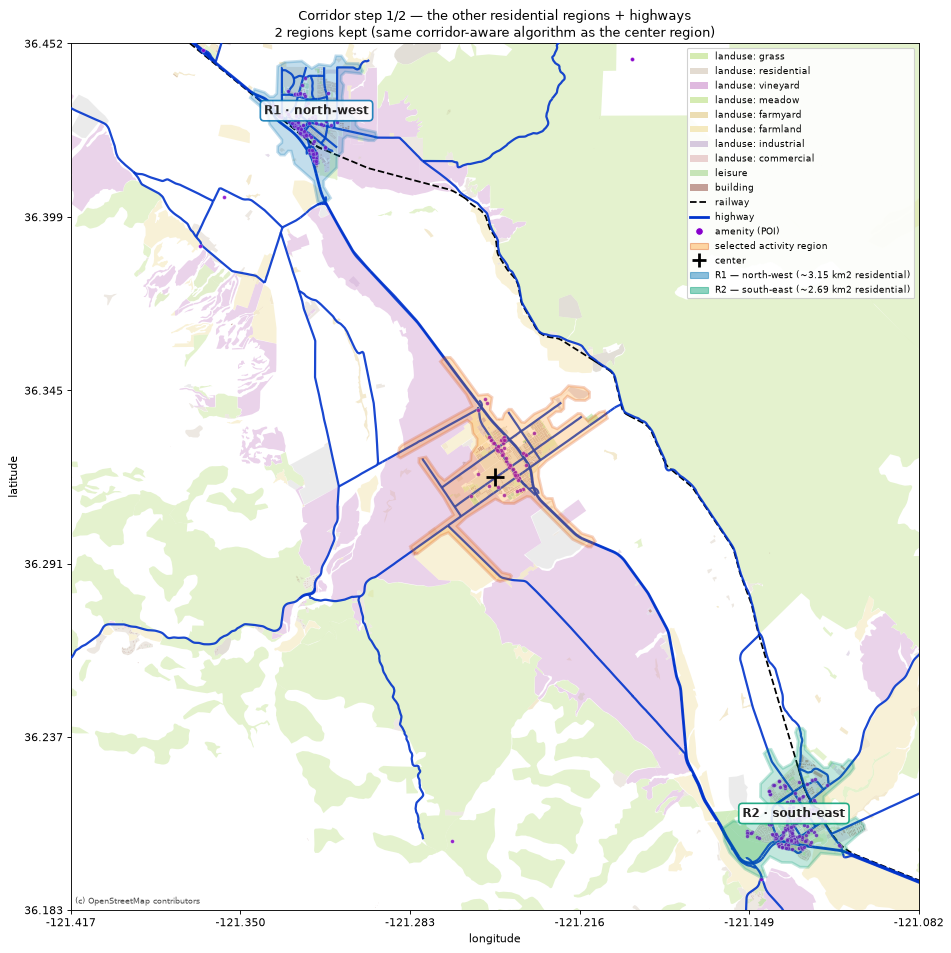

In [22]:
"""
Corridor step 1/2: find the OTHER residential regions (+ highways).

Self-contained follow-up to the OSM-feature cell and the clustering
cell — it only needs `feats`/`shapely_layers`, `cluster_result`,
`build_center_seeded_region` and `plot_region_map` from those two, and
redefines every helper it uses (DBSCAN, compass, ...), so it can run
directly after them with no other cell in between.

Pipeline:
1. residential evidence points — residential-landuse polygons sampled
   on a ~RES_GRID_STEP_M grid (area-proportional) + building centroids;
2. DBSCAN groups them into settlement seeds;
3. every seed runs the SAME corridor-aware algorithm as the center cell
   (build_center_seeded_region with a temporary center), so each region
   has the organic along-the-highway outline;
4. the cluster that reproduces the already-selected center region is
   dropped, overlapping regions are merged, and only the
   RES_TOP_N_REGIONS largest (by residential area) are kept — by
   default the two big settlements up and down the corridor.

Draws the OSM feature map (highways included) with the regions on top
and leaves `residential_regions` + `compass_from_center` in the kernel
for the corridor-probe cell.
"""

from __future__ import annotations

import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from shapely.geometry import MultiPolygon, Point
from shapely.prepared import prep

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
RES_GRID_STEP_M = 120.0        # sampling step inside residential polygons
RES_EPS_M = 500.0              # DBSCAN: neighbour distance
RES_MIN_POINTS = 10            # DBSCAN: neighbours (incl. self) for a core
RES_MIN_CLUSTER_SIZE = 20      # smaller clusters are noise
RES_MIN_LANDUSE_POINTS = 6     # required residential-landuse samples
RES_DUPLICATE_OVERLAP = 0.5    # overlap fraction that counts as duplicate
RES_TOP_N_REGIONS = 2          # keep only the N largest regions (None = all)

# Settlement regions are kept COMPACT: same radius as the center cell,
# but their highway arms are cut short (the corridor between regions is
# what the probe cell samples; the settlements do not need long arms).
RES_MAX_REGION_RADIUS_M = 4500.0     # same as the clustering cell
RES_HIGHWAY_EXTENSION_M = 1000.0     # clustering cell uses 2800 m

REGION_COLORS = ["#0072B2", "#009E73", "#CC79A7", "#7A5195", "#B8860B"]

_required = (
    "shapely_layers", "cluster_result",
    "build_center_seeded_region", "plot_region_map",
    "transform_layer_geometry", "merc_arr",
    "west", "south", "east", "north",
    "CENTER_LAT", "CENTER_LON",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables from earlier cells: " + ", ".join(_missing)
        + " — run the OSM feature cell and the clustering cell first"
    )


# ---------------------------------------------------------------------------
# Helpers (self-contained copies, no dependency on the middle cells)
# ---------------------------------------------------------------------------
def compass_from_center(dx_m: float, dy_m: float) -> str:
    angle = math.degrees(math.atan2(dx_m, dy_m)) % 360.0
    names = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    return names[int((angle + 22.5) // 45) % 8]


def picture_part(lon: float, lat: float) -> str:
    fx = (lon - west) / (east - west)
    fy = (lat - south) / (north - south)
    col = 0 if fx < 1 / 3 else (2 if fx > 2 / 3 else 1)
    row = 2 if fy > 2 / 3 else (0 if fy < 1 / 3 else 1)
    names = {
        (2, 0): "north-west", (2, 1): "north",   (2, 2): "north-east",
        (1, 0): "west",       (1, 1): "central", (1, 2): "east",
        (0, 0): "south-west", (0, 1): "south",   (0, 2): "south-east",
    }
    return names[(row, col)]


def dbscan_labels(
    xy_m: np.ndarray,
    eps_m: float,
    min_points: int,
) -> np.ndarray:
    """Return one cluster label per point (-1 = noise)."""
    n = len(xy_m)
    tree = cKDTree(xy_m)
    neighbor_lists = tree.query_ball_point(xy_m, r=eps_m)
    core = np.array(
        [len(neighbors) >= min_points for neighbors in neighbor_lists]
    )

    labels = np.full(n, -1, dtype=int)
    cluster_id = 0
    for seed in range(n):
        if not core[seed] or labels[seed] != -1:
            continue
        labels[seed] = cluster_id
        frontier = [seed]
        while frontier:
            current = frontier.pop()
            for neighbor in neighbor_lists[current]:
                if labels[neighbor] == -1:
                    labels[neighbor] = cluster_id
                    if core[neighbor]:
                        frontier.append(neighbor)
        cluster_id += 1
    return labels


def residential_evidence_points(
    layers: dict,
    to_utm,
) -> tuple[np.ndarray, np.ndarray]:
    """(points_utm[N,2], sources[N]) with source in {"residential","building"}."""
    xs: list[float] = []
    ys: list[float] = []
    sources: list[str] = []

    for polygon, landuse_type in layers["landuse"]:
        if landuse_type != "residential":
            continue
        polygon_utm = transform_layer_geometry(polygon, to_utm)
        if polygon_utm.is_empty:
            continue

        min_x, min_y, max_x, max_y = polygon_utm.bounds
        grid_x = np.arange(min_x + RES_GRID_STEP_M / 2, max_x, RES_GRID_STEP_M)
        grid_y = np.arange(min_y + RES_GRID_STEP_M / 2, max_y, RES_GRID_STEP_M)
        prepared = prep(polygon_utm)

        added = 0
        for gx in grid_x:
            for gy in grid_y:
                if prepared.covers(Point(gx, gy)):
                    xs.append(float(gx))
                    ys.append(float(gy))
                    sources.append("residential")
                    added += 1

        if added == 0:  # polygon smaller than one grid step
            centroid = polygon_utm.centroid
            xs.append(centroid.x)
            ys.append(centroid.y)
            sources.append("residential")

    building_lons = [poly.centroid.x for poly in layers["building"]]
    building_lats = [poly.centroid.y for poly in layers["building"]]
    if building_lons:
        bx, by = to_utm.transform(
            np.asarray(building_lons), np.asarray(building_lats)
        )
        xs.extend(bx.tolist())
        ys.extend(by.tolist())
        sources.extend(["building"] * len(building_lons))

    if not xs:
        return np.empty((0, 2)), np.empty(0, dtype=object)
    return np.column_stack([xs, ys]), np.asarray(sources)


def build_seeded_region_at(lat: float, lon: float) -> dict:
    """Run build_center_seeded_region with a temporary center and the
    compact settlement limits above; everything is restored after."""
    global CENTER_LAT, CENTER_LON
    global MAX_REGION_RADIUS_M, HIGHWAY_MAX_EXTENSION_FROM_CORE_M
    saved = (
        CENTER_LAT, CENTER_LON,
        MAX_REGION_RADIUS_M, HIGHWAY_MAX_EXTENSION_FROM_CORE_M,
    )
    CENTER_LAT, CENTER_LON = float(lat), float(lon)
    MAX_REGION_RADIUS_M = RES_MAX_REGION_RADIUS_M
    HIGHWAY_MAX_EXTENSION_FROM_CORE_M = RES_HIGHWAY_EXTENSION_M
    try:
        return build_center_seeded_region(shapely_layers)
    finally:
        (
            CENTER_LAT, CENTER_LON,
            MAX_REGION_RADIUS_M, HIGHWAY_MAX_EXTENSION_FROM_CORE_M,
        ) = saved


def overlap_ratio(region_a_utm, region_b_utm) -> float:
    denominator = min(region_a_utm.area, region_b_utm.area)
    if denominator <= 0:
        return 0.0
    return region_a_utm.intersection(region_b_utm).area / denominator


# ---------------------------------------------------------------------------
# 1. Seeds: DBSCAN over the residential evidence
# ---------------------------------------------------------------------------
_to_utm = cluster_result["to_utm"]
_to_wgs84 = cluster_result["to_wgs84"]
_center_utm = cluster_result["center_utm"]
_selected_region_utm = cluster_result["region_utm"]

res_points_utm, res_point_sources = residential_evidence_points(
    shapely_layers, _to_utm
)
if len(res_points_utm) == 0:
    raise RuntimeError(
        "no residential landuse or buildings in the window — nothing to extract"
    )

res_labels = dbscan_labels(res_points_utm, RES_EPS_M, RES_MIN_POINTS)

seed_clusters = []
for cluster_id in np.unique(res_labels):
    if cluster_id < 0:
        continue
    member_index = np.where(res_labels == cluster_id)[0]
    residential_count = int(
        (res_point_sources[member_index] == "residential").sum()
    )
    building_count = int(
        (res_point_sources[member_index] == "building").sum()
    )
    if (
        len(member_index) < RES_MIN_CLUSTER_SIZE
        or residential_count < RES_MIN_LANDUSE_POINTS
    ):
        continue

    centroid_x = float(res_points_utm[member_index, 0].mean())
    centroid_y = float(res_points_utm[member_index, 1].mean())
    centroid_lon, centroid_lat = _to_wgs84.transform(centroid_x, centroid_y)

    seed_clusters.append({
        "residential_points": residential_count,
        "building_points": building_count,
        "residential_area_km2": residential_count
        * (RES_GRID_STEP_M / 1000.0) ** 2,
        "centroid_lonlat": (float(centroid_lon), float(centroid_lat)),
        "centroid_utm": (centroid_x, centroid_y),
    })

seed_clusters.sort(key=lambda c: c["residential_area_km2"], reverse=True)


# ---------------------------------------------------------------------------
# 2. Regions: each seed runs the corridor-aware algorithm; dedup; top N
# ---------------------------------------------------------------------------
residential_regions = []
skipped_notes = []
for cluster in seed_clusters:
    centroid_lon, centroid_lat = cluster["centroid_lonlat"]

    try:
        seeded = build_seeded_region_at(centroid_lat, centroid_lon)
    except RuntimeError as error:
        skipped_notes.append(
            f"seed near ({centroid_lat:.4f}, {centroid_lon:.4f}) "
            f"produced no region ({error})"
        )
        continue

    region_wgs84 = seeded["region_wgs84"]
    region_utm = transform_layer_geometry(region_wgs84, _to_utm)

    if overlap_ratio(region_utm, _selected_region_utm) > RES_DUPLICATE_OVERLAP:
        skipped_notes.append(
            "the central residential cluster reproduces the already-"
            "selected activity region (drawn in orange) and is not "
            "re-numbered"
        )
        continue

    duplicate_of = next(
        (
            other["rank"]
            for other in residential_regions
            if overlap_ratio(region_utm, other["region_utm"])
            > RES_DUPLICATE_OVERLAP
        ),
        None,
    )
    if duplicate_of is not None:
        skipped_notes.append(
            f"seed near ({centroid_lat:.4f}, {centroid_lon:.4f}) merged "
            f"into region R{duplicate_of}"
        )
        continue

    min_x, min_y, max_x, max_y = region_utm.bounds
    dx_m = float(region_utm.centroid.x - _center_utm.x)
    dy_m = float(region_utm.centroid.y - _center_utm.y)

    residential_regions.append({
        **cluster,
        "rank": len(residential_regions) + 1,
        "region_wgs84": region_wgs84,
        "region_utm": region_utm,
        "region_area_km2": region_utm.area / 1e6,
        "part": picture_part(centroid_lon, centroid_lat),
        "extent_km": ((max_x - min_x) / 1000.0, (max_y - min_y) / 1000.0),
        "distance_from_center_km": math.hypot(dx_m, dy_m) / 1000.0,
        "compass_from_center": compass_from_center(dx_m, dy_m),
    })

if RES_TOP_N_REGIONS is not None:
    dropped = residential_regions[RES_TOP_N_REGIONS:]
    for region in dropped:
        skipped_notes.append(
            f"R{region['rank']} ({region['part']}, "
            f"~{region['residential_area_km2']:.2f} km2 residential) "
            f"dropped: keeping only the {RES_TOP_N_REGIONS} largest"
        )
    residential_regions = residential_regions[:RES_TOP_N_REGIONS]

for region in residential_regions:
    region["color"] = REGION_COLORS[(region["rank"] - 1) % len(REGION_COLORS)]


# ---------------------------------------------------------------------------
# 3. Report + map (highways come with plot_region_map's OSM layers)
# ---------------------------------------------------------------------------
for region in residential_regions:
    width_km, height_km = region["extent_km"]
    print(
        f"R{region['rank']} ({region['part']}): "
        f"~{region['region_area_km2']:.1f} km2 region, "
        f"~{region['residential_area_km2']:.2f} km2 residential landuse, "
        f"{region['building_points']} buildings, "
        f"~{width_km:.1f} x {height_km:.1f} km, "
        f"{region['distance_from_center_km']:.1f} km "
        f"{region['compass_from_center']} of the center"
    )
for note in skipped_notes:
    print(f"({note})")

fig, ax, handles = plot_region_map(
    "Corridor step 1/2 — the other residential regions + highways\n"
    f"{len(residential_regions)} regions kept "
    f"(same corridor-aware algorithm as the center region)"
)

for region in residential_regions:
    color = region["color"]
    polygons = (
        list(region["region_wgs84"].geoms)
        if isinstance(region["region_wgs84"], MultiPolygon)
        else [region["region_wgs84"]]
    )
    for polygon in polygons:
        exterior = np.asarray(polygon.exterior.coords)
        x, y = merc_arr(exterior[:, 0], exterior[:, 1])
        ax.fill(
            x, y,
            facecolor=color, edgecolor=color,
            linewidth=2.5, alpha=0.24, zorder=5,
        )

    label_lon, label_lat = region["centroid_lonlat"]
    label_x, label_y = merc_arr(
        np.array([label_lon]), np.array([label_lat])
    )
    ax.text(
        label_x[0], label_y[0],
        f"R{region['rank']} · {region['part']}",
        fontsize=11, fontweight="bold", color="#222222",
        ha="center", va="center", zorder=6,
        bbox={
            "boxstyle": "round,pad=0.3",
            "fc": "white", "ec": color,
            "lw": 1.5, "alpha": 0.85,
        },
    )

    handles.append(
        Patch(
            facecolor=color, edgecolor=color, alpha=0.45,
            label=(
                f"R{region['rank']} — {region['part']} "
                f"(~{region['residential_area_km2']:.2f} km2 residential)"
            ),
        )
    )

ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()


329 highway probes, spacing 500 m, max road distance 25 km from the center region
R1 (north-west): corridor reaches it at ~6.6 km road distance heading NW (probe H-P0118, 6 probes near its boundary)
R2 (south-east): corridor reaches it at ~11.2 km road distance heading SE (probe H-P0185, 7 probes near its boundary)
footprint rule: the down cell's corridor footprint is every probe where it APPEARS in serving/top-5 at all; if it still appears at the probes around a region-entry point above, pull that region into the full analysis.
outputs written to: /scr/xiz23015/agentic_workflow_usecase/osm_activity_output


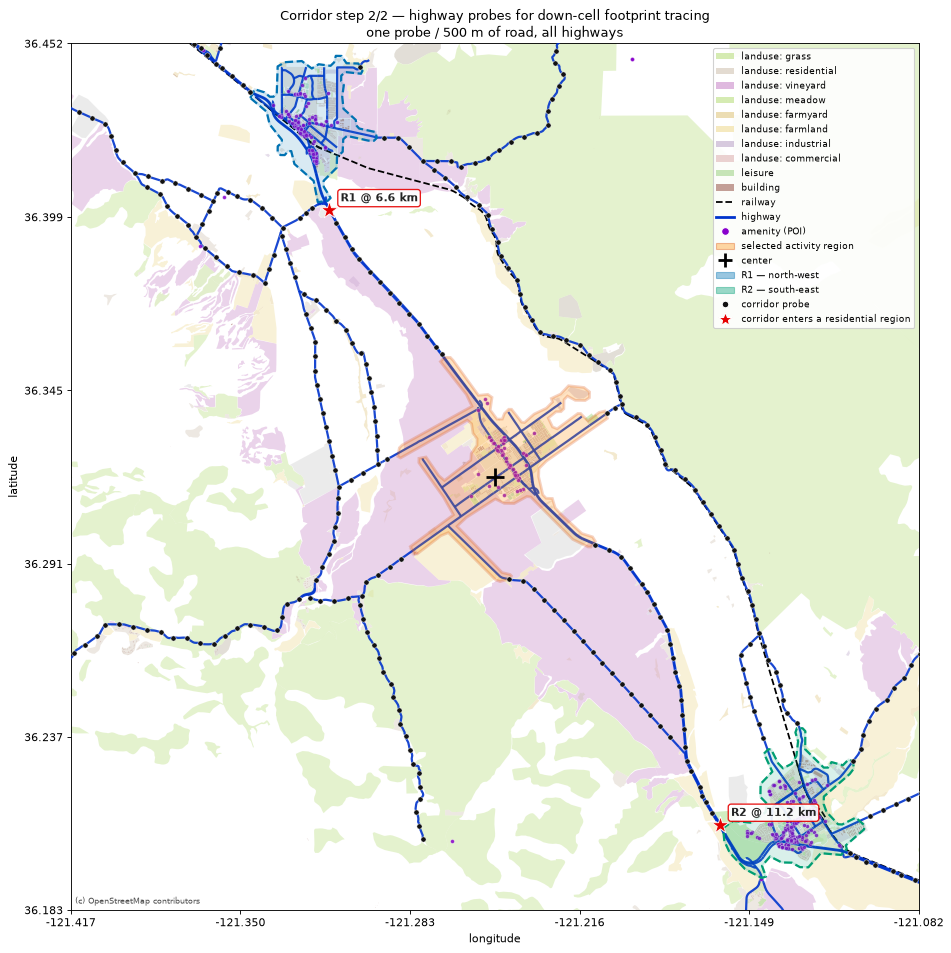

In [25]:
"""
Corridor step 2/2: probe coordinates along the highways.

Runs right after the corridor-regions cell (needs its
`residential_regions` + `compass_from_center`; everything else comes
from the OSM-feature and clustering cells). Marches along the highway
network OUTWARD from the selected center region and drops a probe
coordinate every PROBE_SPACING_M of ROAD distance (multi-source
Dijkstra from every highway vertex inside the center region, so
branches are ordered by road distance, not straight-line).

Query these probes exactly like the sampled points (10 m circle,
serving + top-5 per location). The down cell's corridor footprint is
every probe where it APPEARS AT ALL — serving or neighbor. Each probe
is tested against the residential regions: the summary prints at which
road distance the corridor enters (or passes within TOUCH_BUFFER_M of)
each region — if the down cell still appears around that entry point,
that region needs the full analysis. Probes INSIDE the residential
regions are skipped (only the highway between regions is probed; the
regions themselves get their own sampling step later).

Visualizes regions + highways + probes (uniform black, red stars =
region entries), leaves `highway_probe_df` in the kernel and
exports highway_probe_coordinates.csv/.json (+10 m circles).
"""

from __future__ import annotations

import heapq
import json as _json
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from shapely.geometry import Point, mapping
from shapely.prepared import prep

# ---------------------------------------------------------------------------
# Probe configuration
# ---------------------------------------------------------------------------
PROBE_SPACING_M = 500.0     # one probe every this many meters of road
MAX_CORRIDOR_KM = 25.0      # stop marching past this road distance
TOUCH_BUFFER_M = 500.0      # "touches a region" = probe within this distance
                            # (one probe spacing: catches the last probe
                            #  before the road crosses into the region)
PROBE_MIN_SEPARATION_M = PROBE_SPACING_M * 0.5   # dedupe parallel carriageways
PROBE_COLOR = "#111111"          # all probes drawn in one color
PROBE_CIRCLE_RADIUS_M = 10.0                     # query circle, like samples
PROBE_OUTPUT_DIR = Path("osm_activity_output")

_required = (
    "shapely_layers", "cluster_result", "residential_regions",
    "compass_from_center", "plot_region_map",
    "transform_layer_geometry", "merc_arr",
)
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "missing variables from earlier cells: " + ", ".join(_missing)
        + " — run the OSM feature cell, the clustering cell and the "
        "corridor-regions cell first"
    )

_to_utm = cluster_result["to_utm"]
_to_wgs84 = cluster_result["to_wgs84"]
_center_utm = cluster_result["center_utm"]
_region_utm = cluster_result["region_utm"]

_highways_utm = [
    (transform_layer_geometry(line, _to_utm), name)
    for line, name in shapely_layers["highway"]
]


# ---------------------------------------------------------------------------
# 1. Highway network graph + road distance from the center region
# ---------------------------------------------------------------------------
def _node_key(x: float, y: float) -> tuple[float, float]:
    # OSM ways share junction nodes exactly; rounding to 1 cm keeps them glued.
    return (round(x, 2), round(y, 2))


adjacency: dict[tuple, list] = defaultdict(list)
node_xy: dict[tuple, tuple[float, float]] = {}

for line_utm, _name in _highways_utm:
    coords = list(line_utm.coords)
    for (x0, y0), (x1, y1) in zip(coords[:-1], coords[1:]):
        a, b = _node_key(x0, y0), _node_key(x1, y1)
        if a == b:
            continue
        length = math.hypot(x1 - x0, y1 - y0)
        adjacency[a].append((b, length))
        adjacency[b].append((a, length))
        node_xy[a] = (x0, y0)
        node_xy[b] = (x1, y1)

_region_prepared = prep(_region_utm)
source_nodes = [
    key for key, (x, y) in node_xy.items()
    if _region_prepared.covers(Point(x, y))
]
if not source_nodes:
    raise RuntimeError(
        "no highway vertex inside the center region — check the region"
    )

road_distance: dict[tuple, float] = {key: 0.0 for key in source_nodes}
heap = [(0.0, key) for key in source_nodes]
heapq.heapify(heap)
while heap:
    dist, key = heapq.heappop(heap)
    if dist > road_distance.get(key, math.inf):
        continue
    if dist > MAX_CORRIDOR_KM * 1000.0:
        continue
    for neighbor, length in adjacency[key]:
        candidate = dist + length
        if candidate < road_distance.get(neighbor, math.inf):
            road_distance[neighbor] = candidate
            heapq.heappush(heap, (candidate, neighbor))

_reached_keys = list(road_distance)
_reached_tree = cKDTree(np.array([node_xy[k] for k in _reached_keys]))
_reached_dist = np.array([road_distance[k] for k in _reached_keys])


# ---------------------------------------------------------------------------
# 2. Probe candidates every PROBE_SPACING_M along every highway
# ---------------------------------------------------------------------------
candidates = []
for line_utm, name in _highways_utm:
    if line_utm.length <= 0:
        continue
    for offset in np.arange(0.0, line_utm.length + 1e-9, PROBE_SPACING_M):
        point = line_utm.interpolate(float(offset))
        if _region_prepared.covers(point):
            continue  # inside the center region: already sampled there

        # Road distance = nearest reached graph vertex + gap to it.
        gap, index = _reached_tree.query([point.x, point.y])
        corridor_m = _reached_dist[index] + gap
        if gap > PROBE_SPACING_M:
            continue  # numerically detached from the reached network
        if corridor_m > MAX_CORRIDOR_KM * 1000.0:
            continue
        candidates.append((corridor_m, point, name))

# Near probes first, then greedy dedupe (parallel carriageways, overlaps).
candidates.sort(key=lambda item: item[0])
kept = []
kept_xy = []
for corridor_m, point, name in candidates:
    xy = (point.x, point.y)
    if kept_xy:
        tree = cKDTree(kept_xy)
        if tree.query_ball_point(xy, r=PROBE_MIN_SEPARATION_M):
            continue
    kept.append((corridor_m, point, name))
    kept_xy.append(xy)


# ---------------------------------------------------------------------------
# 3. Region-touch flags + dataframe
# ---------------------------------------------------------------------------
_region_shapes = [
    (f"R{region['rank']}", region["region_utm"], prep(region["region_utm"]))
    for region in residential_regions
]

rows = []
for corridor_m, point, name in kept:
    inside = next(
        (label for label, _shape, prepared in _region_shapes
         if prepared.covers(point)),
        "",
    )
    if inside:
        continue  # residential regions are not probed here
    near = next(
        (label for label, shape, _prepared in _region_shapes
         if shape.distance(point) <= TOUCH_BUFFER_M),
        "",
    )

    point_wgs84 = transform_layer_geometry(point, _to_wgs84)
    dx = point.x - _center_utm.x
    dy = point.y - _center_utm.y
    rows.append({
        "latitude": point_wgs84.y,
        "longitude": point_wgs84.x,
        "corridor_km": corridor_m / 1000.0,
        "direction": compass_from_center(dx, dy),
        "highway": name,
        "near_region": near,
        "circle_radius_m": PROBE_CIRCLE_RADIUS_M,
    })

highway_probe_df = pd.DataFrame(rows).sort_values(
    "corridor_km"
).reset_index(drop=True)
highway_probe_df.insert(
    0,
    "point_id",
    [f"H-P{index:04d}" for index in range(1, len(highway_probe_df) + 1)],
)


# ---------------------------------------------------------------------------
# 4. Summary: where does the corridor meet each residential region?
# ---------------------------------------------------------------------------
print(
    f"{len(highway_probe_df)} highway probes, spacing {PROBE_SPACING_M:.0f} m, "
    f"max road distance {MAX_CORRIDOR_KM:.0f} km from the center region"
)
for region in residential_regions:
    label = f"R{region['rank']}"
    touching = highway_probe_df[highway_probe_df["near_region"] == label]
    if touching.empty:
        print(f"{label} ({region['part']}): corridor does not reach it")
        continue
    first = touching.iloc[0]
    print(
        f"{label} ({region['part']}): corridor reaches it at "
        f"~{first['corridor_km']:.1f} km road distance heading "
        f"{first['direction']} (probe {first['point_id']}, "
        f"{len(touching)} probes near its boundary)"
    )
print(
    "footprint rule: the down cell's corridor footprint is every probe "
    "where it APPEARS in serving/top-5 at all; if it still appears at the "
    "probes around a region-entry point above, pull that region into the "
    "full analysis."
)


# ---------------------------------------------------------------------------
# 5. Export in the same shape as the sampled coordinates
# ---------------------------------------------------------------------------
PROBE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
highway_probe_df.to_csv(
    PROBE_OUTPUT_DIR / "highway_probe_coordinates.csv",
    index=False,
    float_format="%.8f",
)
(PROBE_OUTPUT_DIR / "highway_probe_coordinates.json").write_text(
    _json.dumps(highway_probe_df.to_dict(orient="records"), indent=2),
    encoding="utf-8",
)

_circle_features = []
for row in highway_probe_df.itertuples(index=False):
    point_utm = transform_layer_geometry(
        Point(row.longitude, row.latitude), _to_utm
    )
    circle_wgs84 = transform_layer_geometry(
        point_utm.buffer(PROBE_CIRCLE_RADIUS_M), _to_wgs84
    )
    _circle_features.append({
        "type": "Feature",
        "properties": {
            "point_id": row.point_id,
            "corridor_km": row.corridor_km,
            "radius_m": PROBE_CIRCLE_RADIUS_M,
        },
        "geometry": mapping(circle_wgs84),
    })
(PROBE_OUTPUT_DIR / "highway_probe_circles_10m.geojson").write_text(
    _json.dumps(
        {"type": "FeatureCollection", "features": _circle_features},
        indent=2,
    ),
    encoding="utf-8",
)
print(f"outputs written to: {PROBE_OUTPUT_DIR.resolve()}")


# ---------------------------------------------------------------------------
# 6. Map: regions + highways + probes (uniform black)
# ---------------------------------------------------------------------------
fig, ax, handles = plot_region_map(
    "Corridor step 2/2 — highway probes for down-cell footprint tracing\n"
    f"one probe / {PROBE_SPACING_M:.0f} m of road, all highways"
)

for region in residential_regions:
    exterior = np.asarray(region["region_wgs84"].exterior.coords)
    x, y = merc_arr(exterior[:, 0], exterior[:, 1])
    ax.fill(
        x, y,
        facecolor=region["color"], edgecolor=region["color"],
        linewidth=2.0, alpha=0.15, zorder=5,
    )
    ax.plot(
        x, y,
        color=region["color"], linewidth=2.0, linestyle="--", zorder=5.1,
    )
    handles.append(
        Patch(
            facecolor=region["color"], edgecolor=region["color"], alpha=0.4,
            label=f"R{region['rank']} — {region['part']}",
        )
    )

probe_x, probe_y = merc_arr(
    highway_probe_df["longitude"].to_numpy(),
    highway_probe_df["latitude"].to_numpy(),
)
ax.scatter(
    probe_x, probe_y,
    c=PROBE_COLOR, s=22, marker="o",
    edgecolors="white", linewidths=0.4, zorder=5.6,
)

for region in residential_regions:
    label = f"R{region['rank']}"
    touching = highway_probe_df[highway_probe_df["near_region"] == label]
    if touching.empty:
        continue
    first = touching.iloc[0]
    entry_x, entry_y = merc_arr(
        np.array([first["longitude"]]), np.array([first["latitude"]])
    )
    ax.scatter(
        entry_x, entry_y,
        marker="*", s=260, c="#e60000",
        edgecolors="white", linewidths=0.8, zorder=6,
    )
    ax.annotate(
        f"{label} @ {first['corridor_km']:.1f} km",
        (entry_x[0], entry_y[0]),
        textcoords="offset points", xytext=(10, 8),
        fontsize=10, fontweight="bold", color="#222222",
        bbox={
            "boxstyle": "round,pad=0.25",
            "fc": "white", "ec": "#e60000",
            "lw": 1.2, "alpha": 0.9,
        },
        zorder=6.1,
    )

handles.append(plt.Line2D(
    [], [], color=PROBE_COLOR, marker="o", ls="none", ms=6,
    mec="white", label="corridor probe",
))
handles.append(plt.Line2D(
    [], [], color="#e60000", marker="*", ls="none", ms=13,
    mec="white", label="corridor enters a residential region",
))
ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()
